In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


plt.rcParams['font.family'] = 'Arial'  # widely available
sns.set(font='Arial')

# Choosing colors

In [3]:
t5_palette = 'mako_r'
t5_color = sns.color_palette(t5_palette)[1]

In [4]:
t30_palette = 'rocket_r'
t30_color = sns.color_palette(t30_palette)[1]

# GCN4 Downsampling

## RT

### Reading in data

In [5]:
time_5_summary = pd.read_csv("../../output/downsampling_t5_summary.csv", index_col=0, header=[0,1])
#time_5_summary = time_5_summary.dropna()
time_5_summary

num_splits      percent_reads               time  unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1         mean   
0            1.000000                100                  5  4447493.000   
1            1.333333                 75                  5  3892247.000   
2            2.000000                 50                  5  3246868.500   
3            3.000000                 33                  5  2733837.000   
4            4.000000                 25                  5  2441704.000   
5            5.000000                 20                  5  2249608.400   
6            8.000000                 12                  5  1926558.125   
7           10.000000                 10                  5  1804834.500   
8           20.000000                  5                  5  1519204.400   
9           50.000000                  2                  5  1256737.400   
10         100.000000                  1                  5  1027596.400   
11         200.000000                  0                  5   738146.000   
12         400.000000                  0                  5   463818.400   
13         600.000000                  0                  5   337043.200   
14         800.000000                  0                  5   264150.200   
15        1000.000000                  0                  5   217322.800   

                 
            std  
0           NaN  
1    469.518903  
2    456.083874  
3   1403.782034  
4    423.707446  
5    720.805660  
6    825.867239  
7    660.935406  
8    709.867326  
9    341.193933  
10   523.537296  
11   251.192158  
12   206.410513  
13   208.879630  
14   179.967219  
15   222.456063

In [6]:
time_30_summary = pd.read_csv("../../output/downsampling_t30_summary.csv",  index_col=0, header=[0,1])
#time_30_summary = time_30_summary.dropna()
time_30_summary

num_splits      percent_reads               time   unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1          mean   
0            1.000000                100                 30  1.111911e+07   
1            1.333333                 75                 30  1.039778e+07   
2            2.000000                 50                 30  9.499812e+06   
3            3.000000                 33                 30  8.691480e+06   
4            4.000000                 25                 30  8.185798e+06   
5            5.000000                 20                 30  7.829731e+06   
6            8.000000                 12                 30  7.167704e+06   
7           10.000000                 10                 30  6.883418e+06   
8           20.000000                  5                 30  5.989910e+06   
9           50.000000                  2                 30  4.421741e+06   
10         100.000000                  1                 30  3.046692e+06   
11         200.000000                  0                 30  1.867255e+06   
12         400.000000                  0                 30  1.050519e+06   
13         600.000000                  0                 30  7.306170e+05   
14         800.000000                  0                 30  5.599710e+05   
15        1000.000000                  0                 30  4.540864e+05   

                 
            std  
0           NaN  
1    198.697006  
2    895.904292  
3   2444.657508  
4   1165.064626  
5    935.274559  
6    804.001244  
7   1014.829296  
8   1276.291626  
9   1120.491321  
10   627.009330  
11   530.803165  
12   326.000460  
13   195.400870  
14   334.876096  
15   273.039008

### REads v unique umis

In [7]:
correlation_df = pd.read_csv("../../output/GCN4_downsampling_correlation_results.csv")
correlation_df#["percent_reads"].value_counts()

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../output/GCN4/downsampling/trebl_experimen...,0.998517,0.955042,11039,800.0,0.125,30
1,../../output/GCN4/downsampling/trebl_experimen...,0.999500,0.989250,14052,50.0,2.000,30
2,../../output/GCN4/downsampling/trebl_experimen...,0.999769,0.989749,13986,8.0,12.500,5
3,../../output/GCN4/downsampling/trebl_experimen...,0.999352,0.982615,13763,100.0,1.000,30
4,../../output/GCN4/downsampling/trebl_experimen...,0.999739,0.994606,14210,20.0,5.000,30
...,...,...,...,...,...,...,...
175,../../output/GCN4/downsampling/trebl_experimen...,0.999747,0.994816,14214,20.0,5.000,30
176,../../output/GCN4/downsampling/trebl_experimen...,0.999909,0.996901,14274,8.0,12.500,30
177,../../output/GCN4/downsampling/trebl_experimen...,0.999860,0.991066,14019,5.0,20.000,5
178,../../output/GCN4/downsampling/trebl_experimen...,0.999648,0.988707,13967,10.0,10.000,5


In [8]:
time_5_summary["percent_reads"] = 100 / time_5_summary[('num_splits', 'Unnamed: 1_level_1')]
time_30_summary["percent_reads"] = 100 / time_30_summary[('num_splits', 'Unnamed: 1_level_1')]


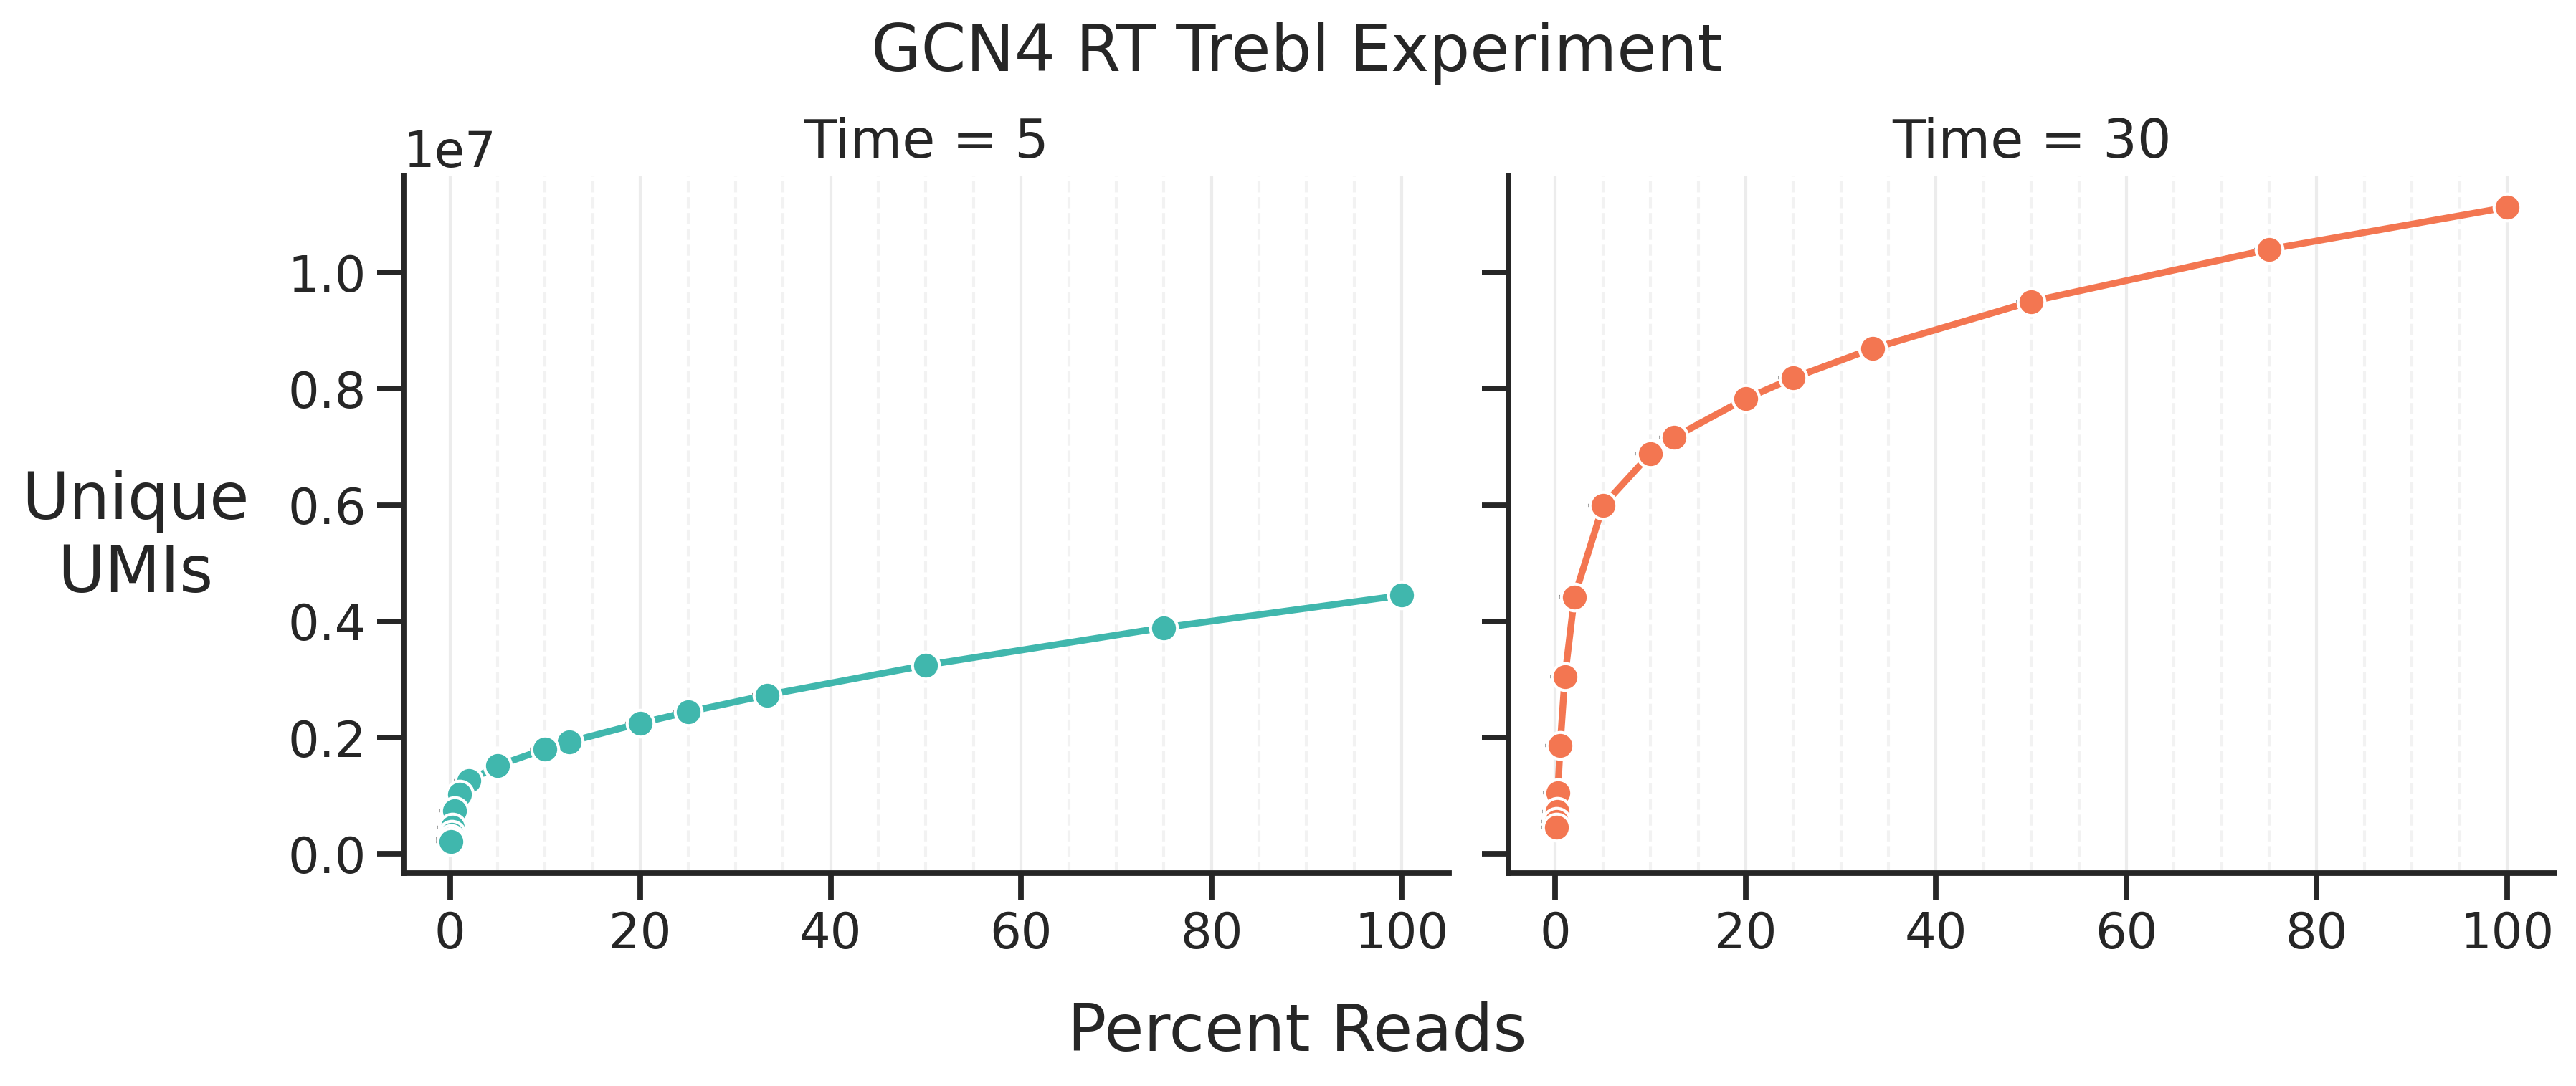

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Time 5 ----------
ax = axes[0]
x_5 = time_5_summary['percent_reads']
y_mean_5 = time_5_summary[('unique_umis', 'mean')]
y_std_5 = time_5_summary[('unique_umis', 'std')]

ax.errorbar(
    x=x_5,
    y=y_mean_5,
    yerr=y_std_5,
    fmt='-o',
    capsize=5,
    color=t5_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 5")
ax.set_xlabel("")
# ax.set_ylabel("Unique UMIs")
sns.despine(ax=ax)

# ---------- Time 30 ----------
ax = axes[1]
x_30 = time_30_summary['percent_reads']
y_mean_30 = time_30_summary[('unique_umis', 'mean')]
y_std_30 = time_30_summary[('unique_umis', 'std')]

ax.errorbar(
    x=x_30,
    y=y_mean_30,
    yerr=y_std_30,
    fmt='-o',
    capsize=5,
    color=t30_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 30")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(ax=ax)

# --- Shared X limits and ticks ---
all_x = np.concatenate([x_5, x_30])
x_min, x_max = all_x.min(), all_x.max()
for ax in axes:
    #ax.set_xlim(x_min - 1e7, x_max + 1e7)
    #ax.set_ylim(0, max(y_mean_5.max(), y_mean_30.max()) * 1.05)

    # Major and minor vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    ax.xaxis.set_minor_locator(MultipleLocator(5))  # minor tick every 50M reads
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)

# Super labels and title
fig.supxlabel("Percent Reads")
fig.supylabel("Unique\nUMIs", rotation = 0, ha = 'center', x = 0.05)
fig.suptitle("GCN4 RT Trebl Experiment")

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs correlation

In [10]:
# Filter data for time = 5 and time = 30
correlation_df_5 = correlation_df[correlation_df["time"] == 5]
correlation_df_30 = correlation_df[correlation_df["time"] == 30]


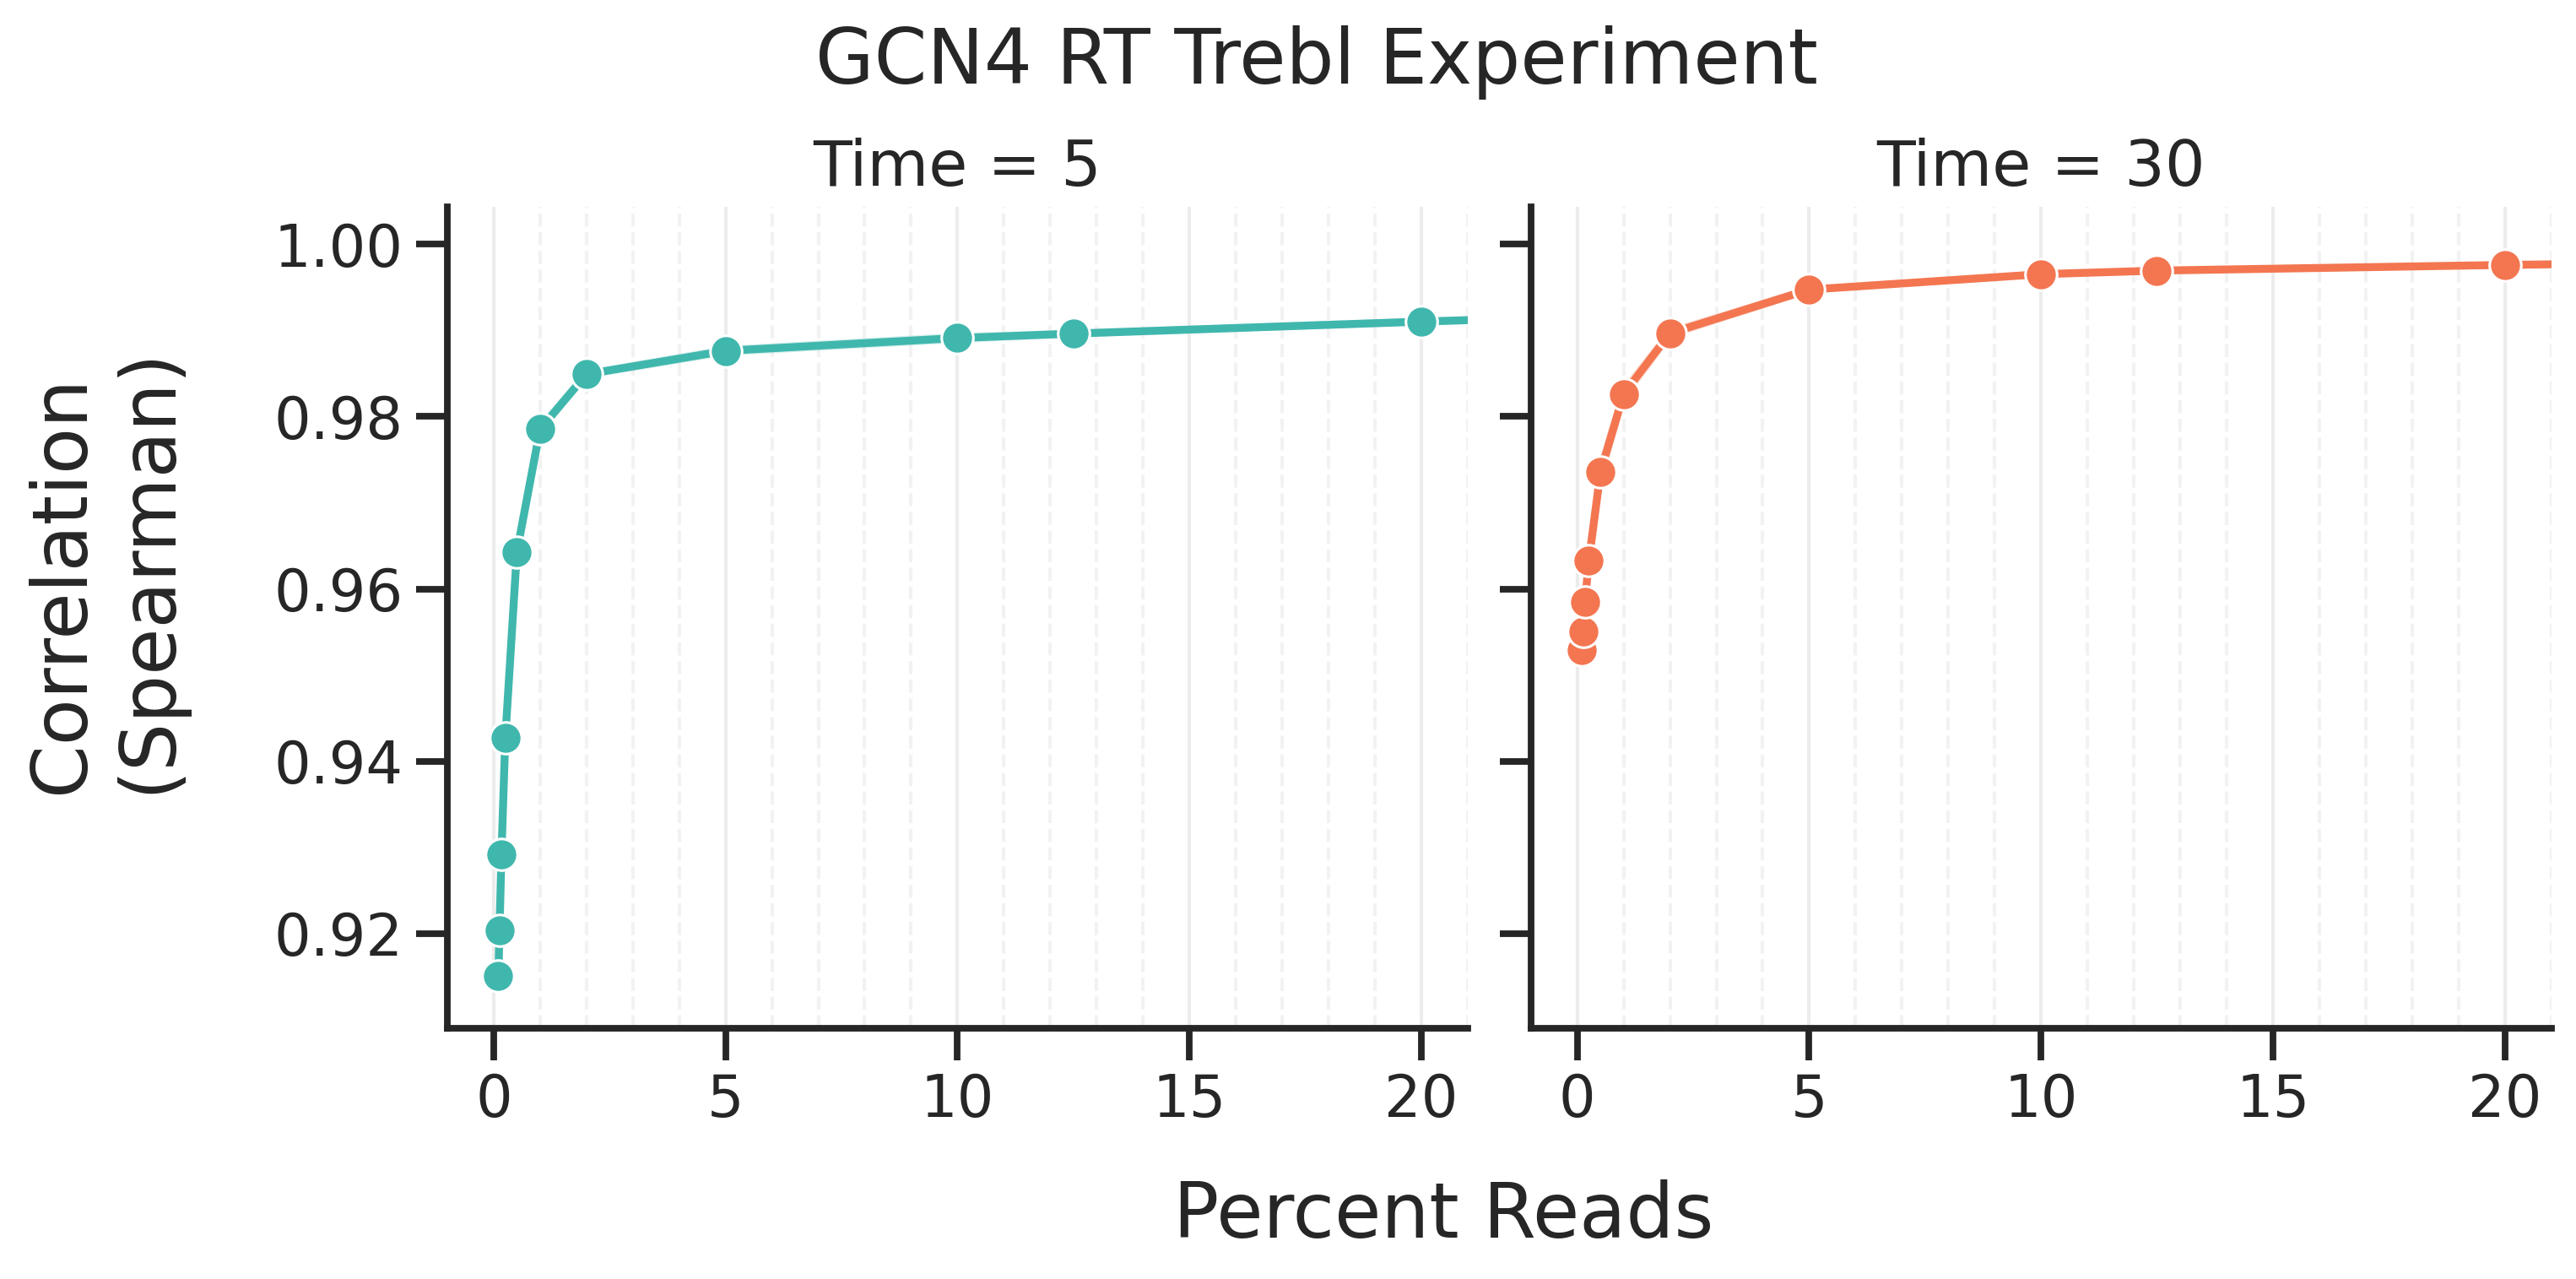

In [11]:
sns.set_context("talk")
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Spearman only ----------
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

plt.tight_layout(pad=0.5)
plt.show()

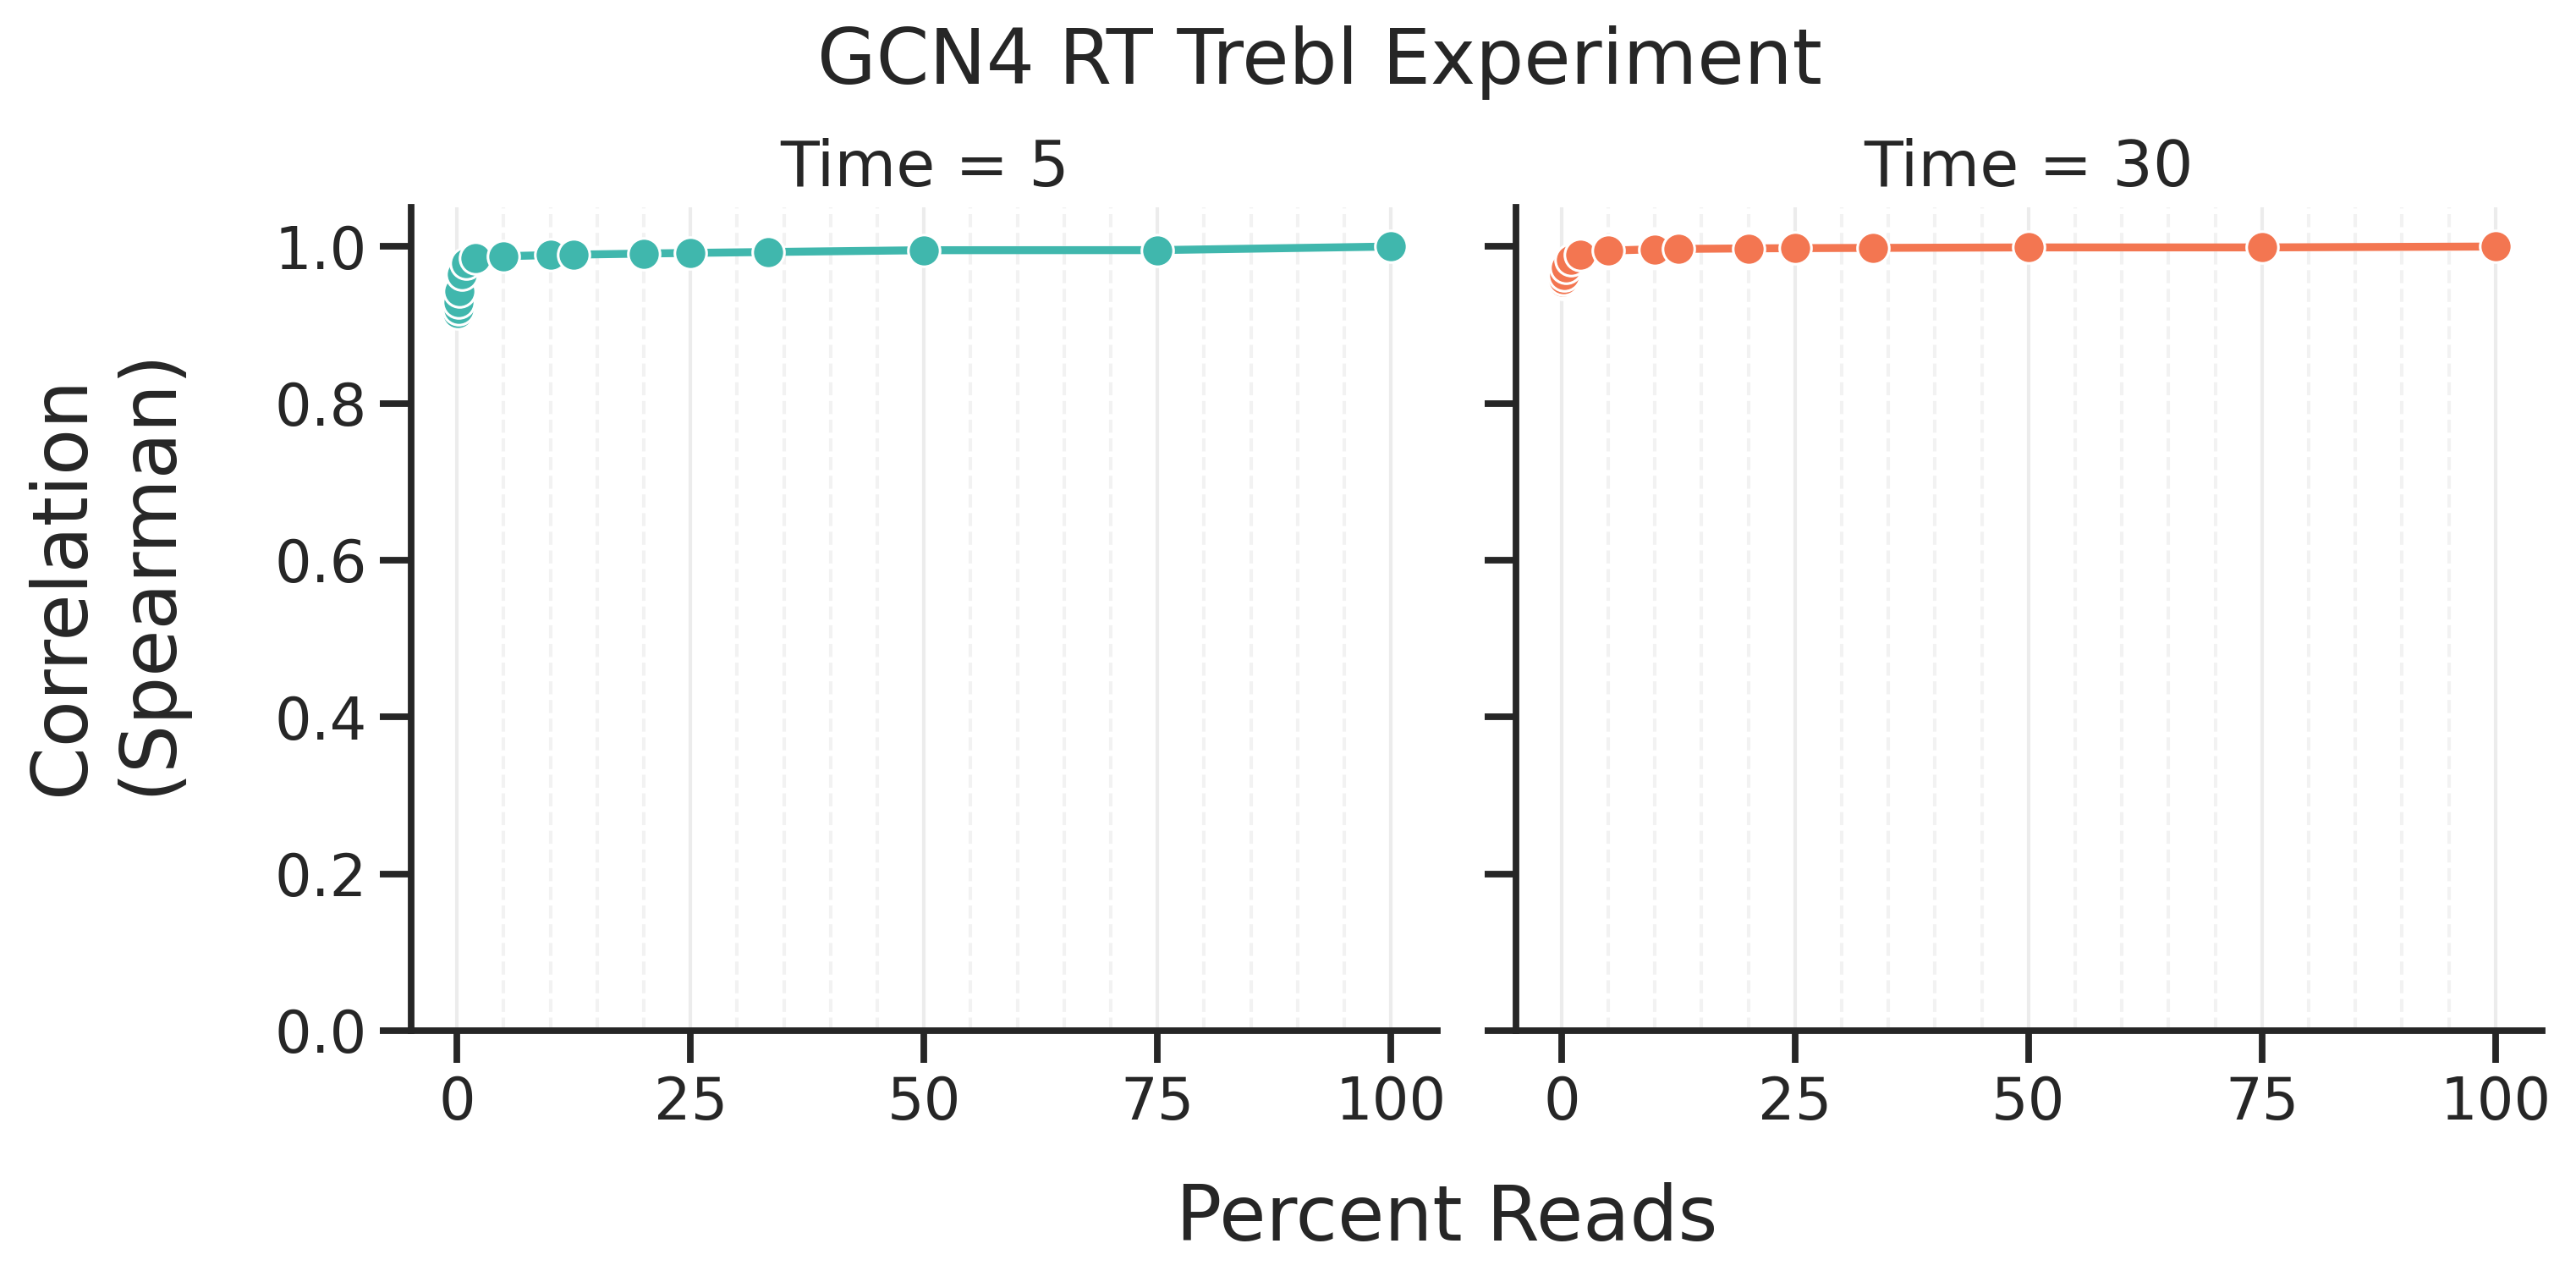

In [12]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)
sns.set_context("talk")

# ---------- Spearman only ----------
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0, 1.05)

plt.tight_layout(pad=0.5)
plt.show()

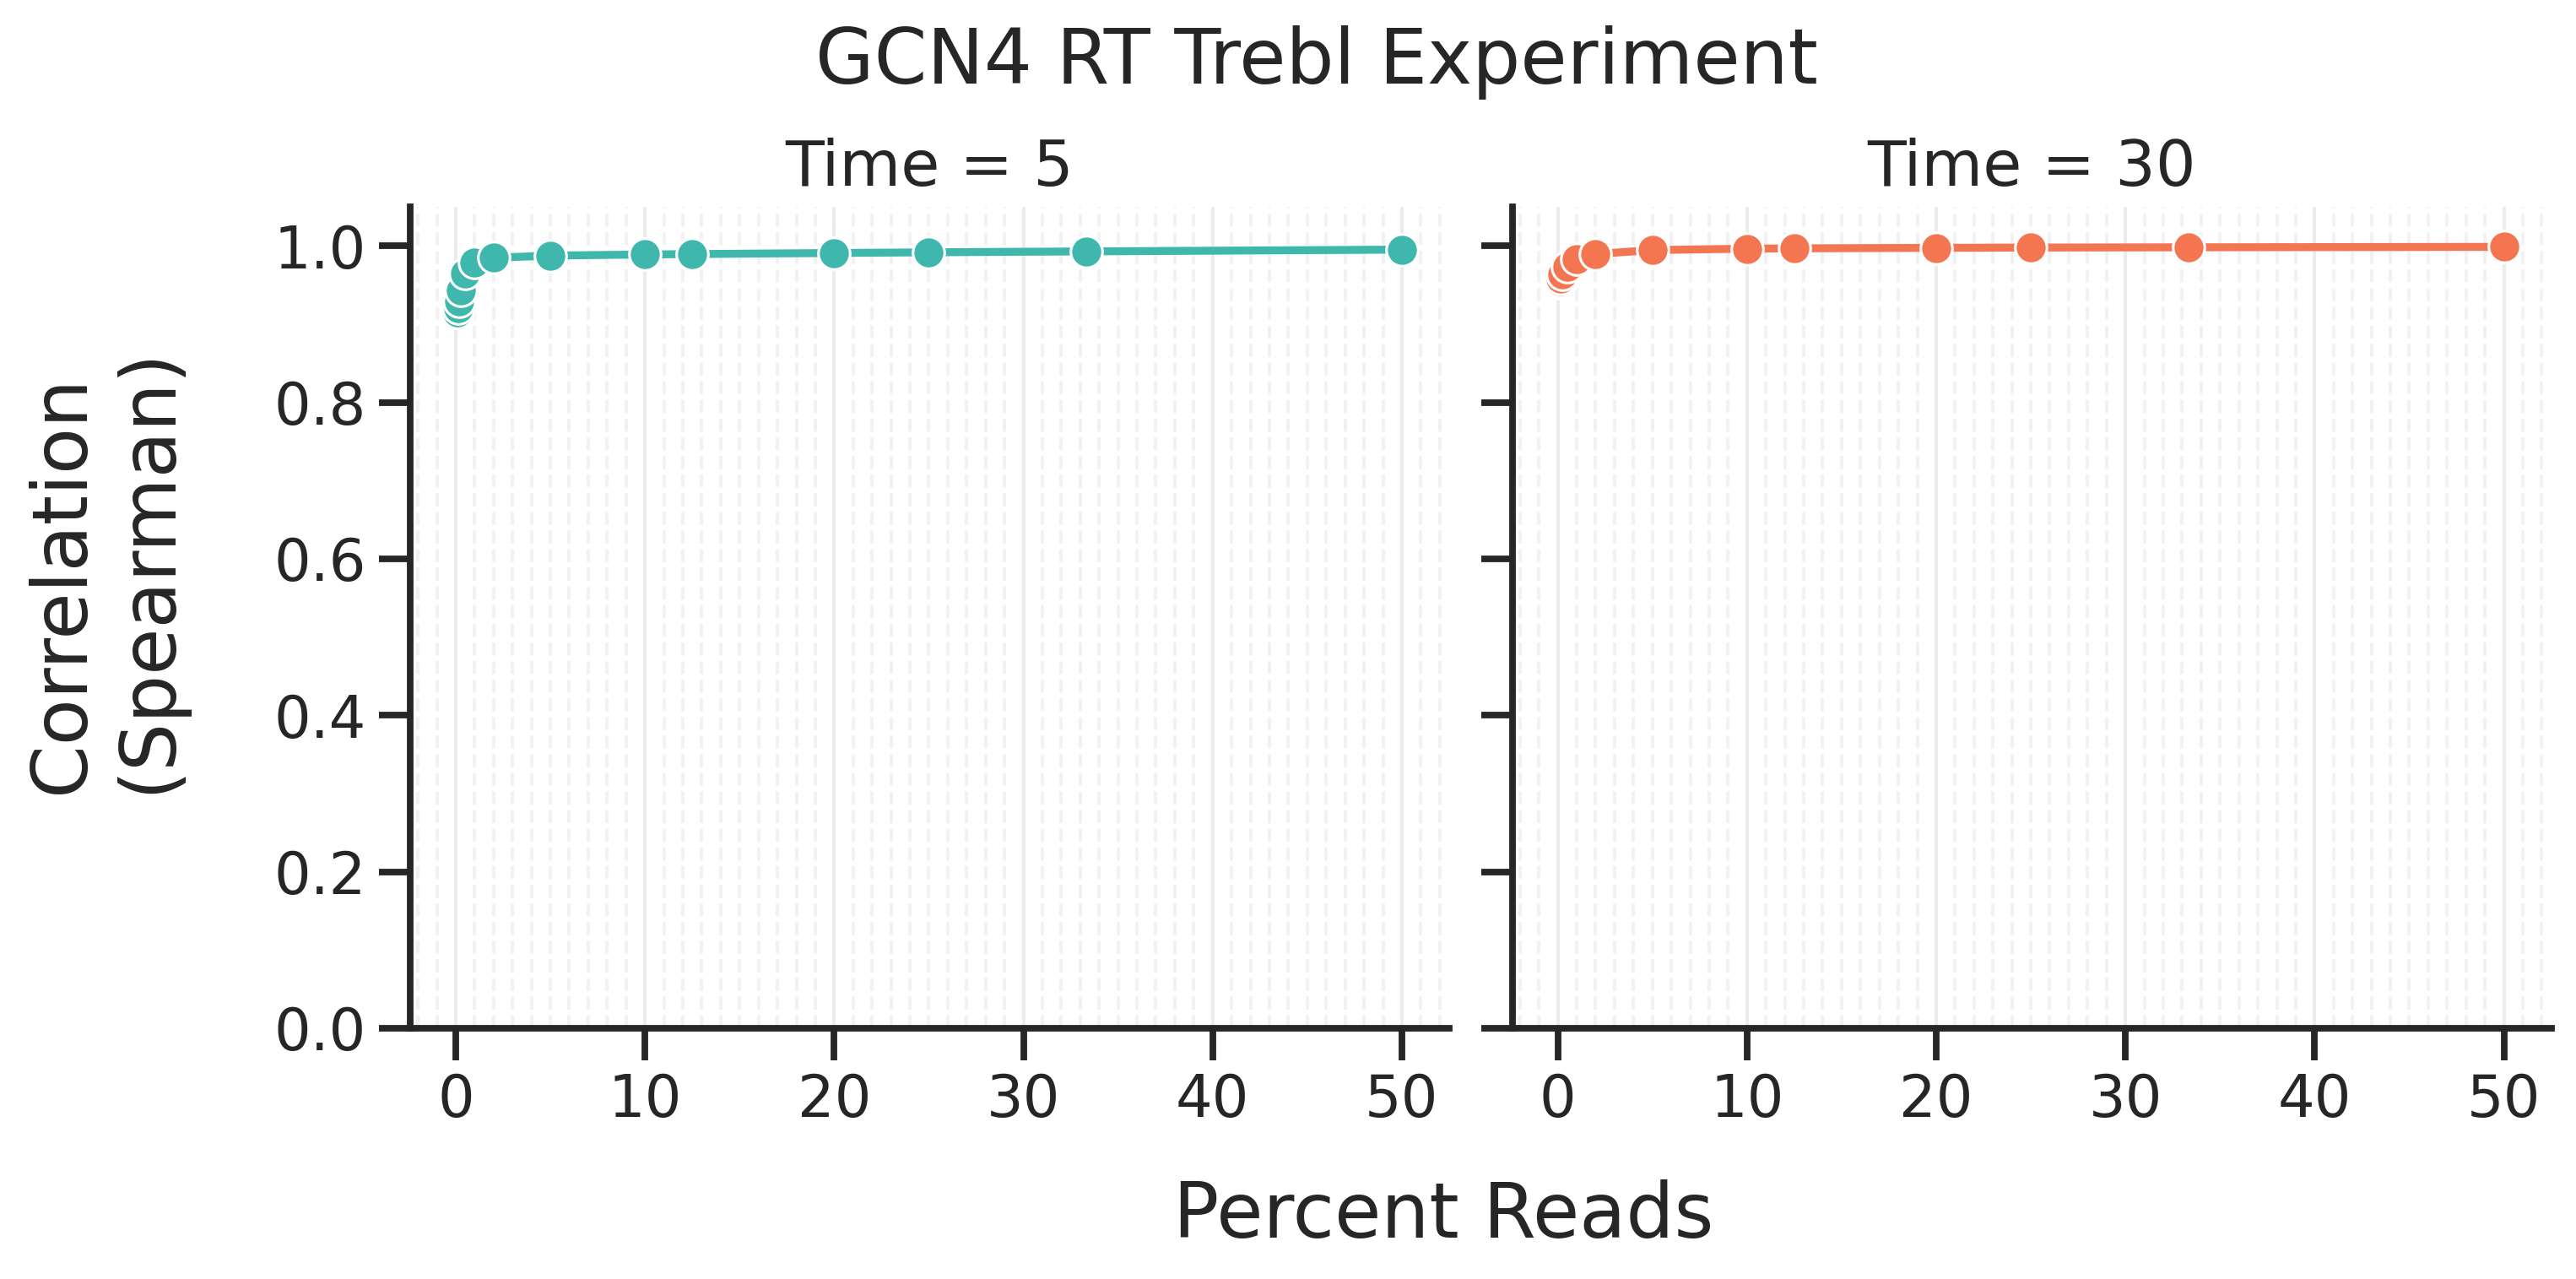

In [20]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)
sns.set_context("talk")

# ---------- Spearman only ----------
sns.lineplot(
    data=correlation_df_5[correlation_df_5["percent_reads"] <= 50],
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=correlation_df_30[correlation_df_30["percent_reads"] <= 50],
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0, 1.05)
    #ax.set_xlim(-1, 51)

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs barcodes recovered

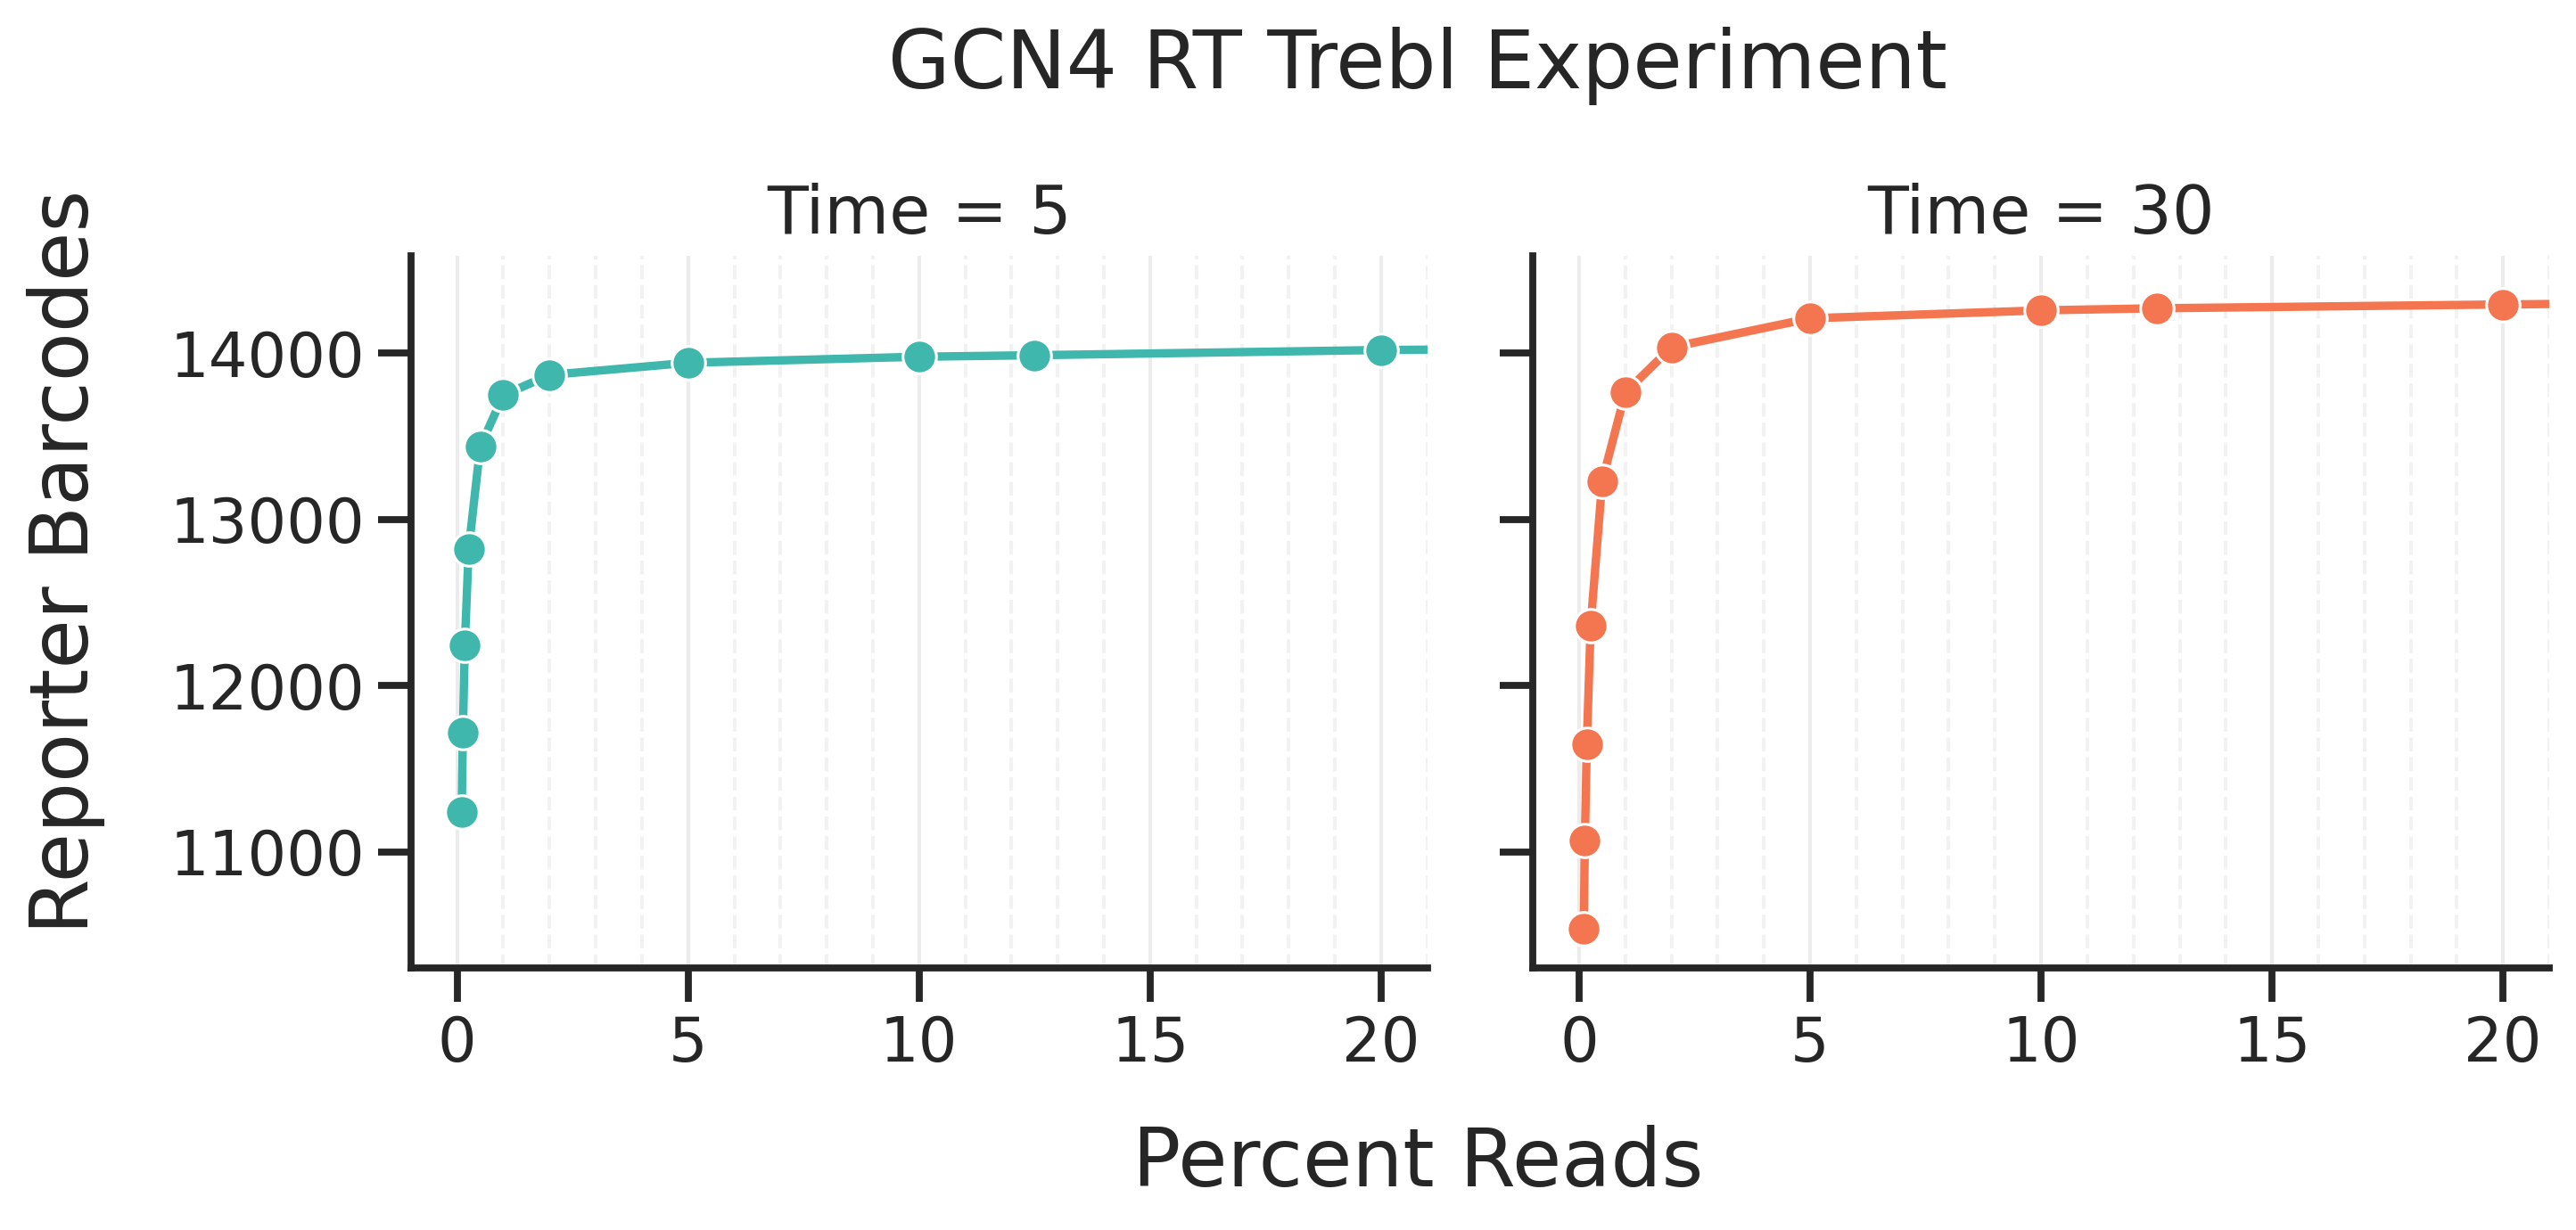

In [21]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_color
)
ax.set_title("Time = 5")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_color
)
ax.set_title("Time = 30")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("Reporter Barcodes", x=0.03, y=0.55)
fig.suptitle("GCN4 RT Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

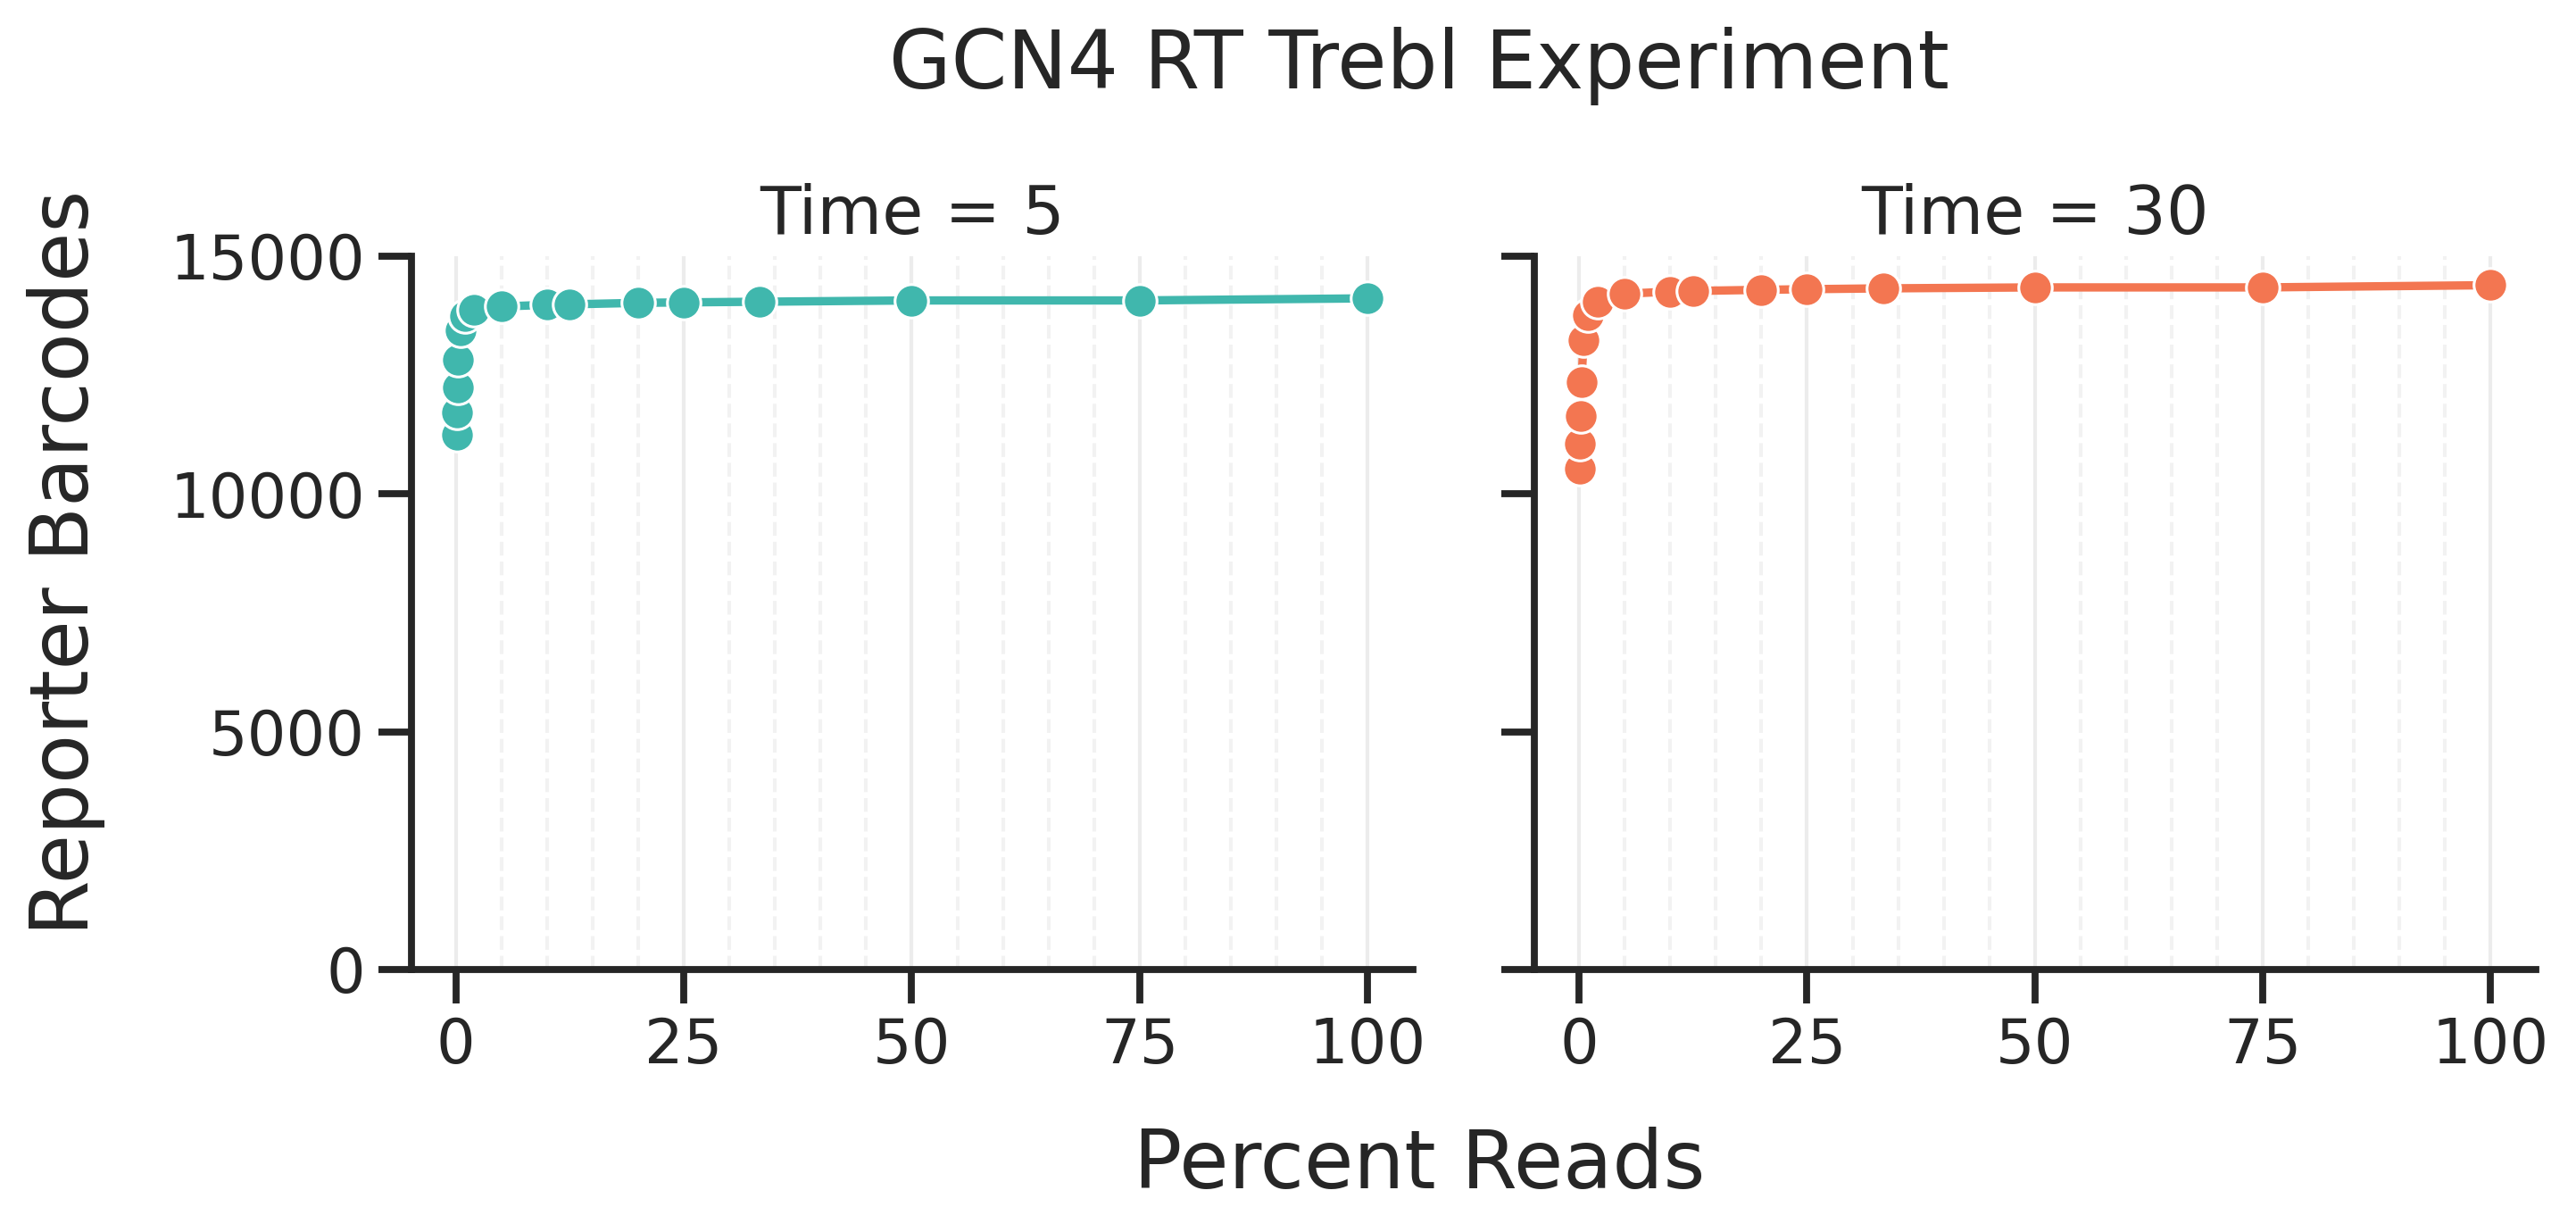

In [22]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_color
)
ax.set_title("Time = 5")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_color
)
ax.set_title("Time = 30")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0,15000)

# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("Reporter Barcodes", x=0.03, y=0.55)
fig.suptitle("GCN4 RT Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

### All together

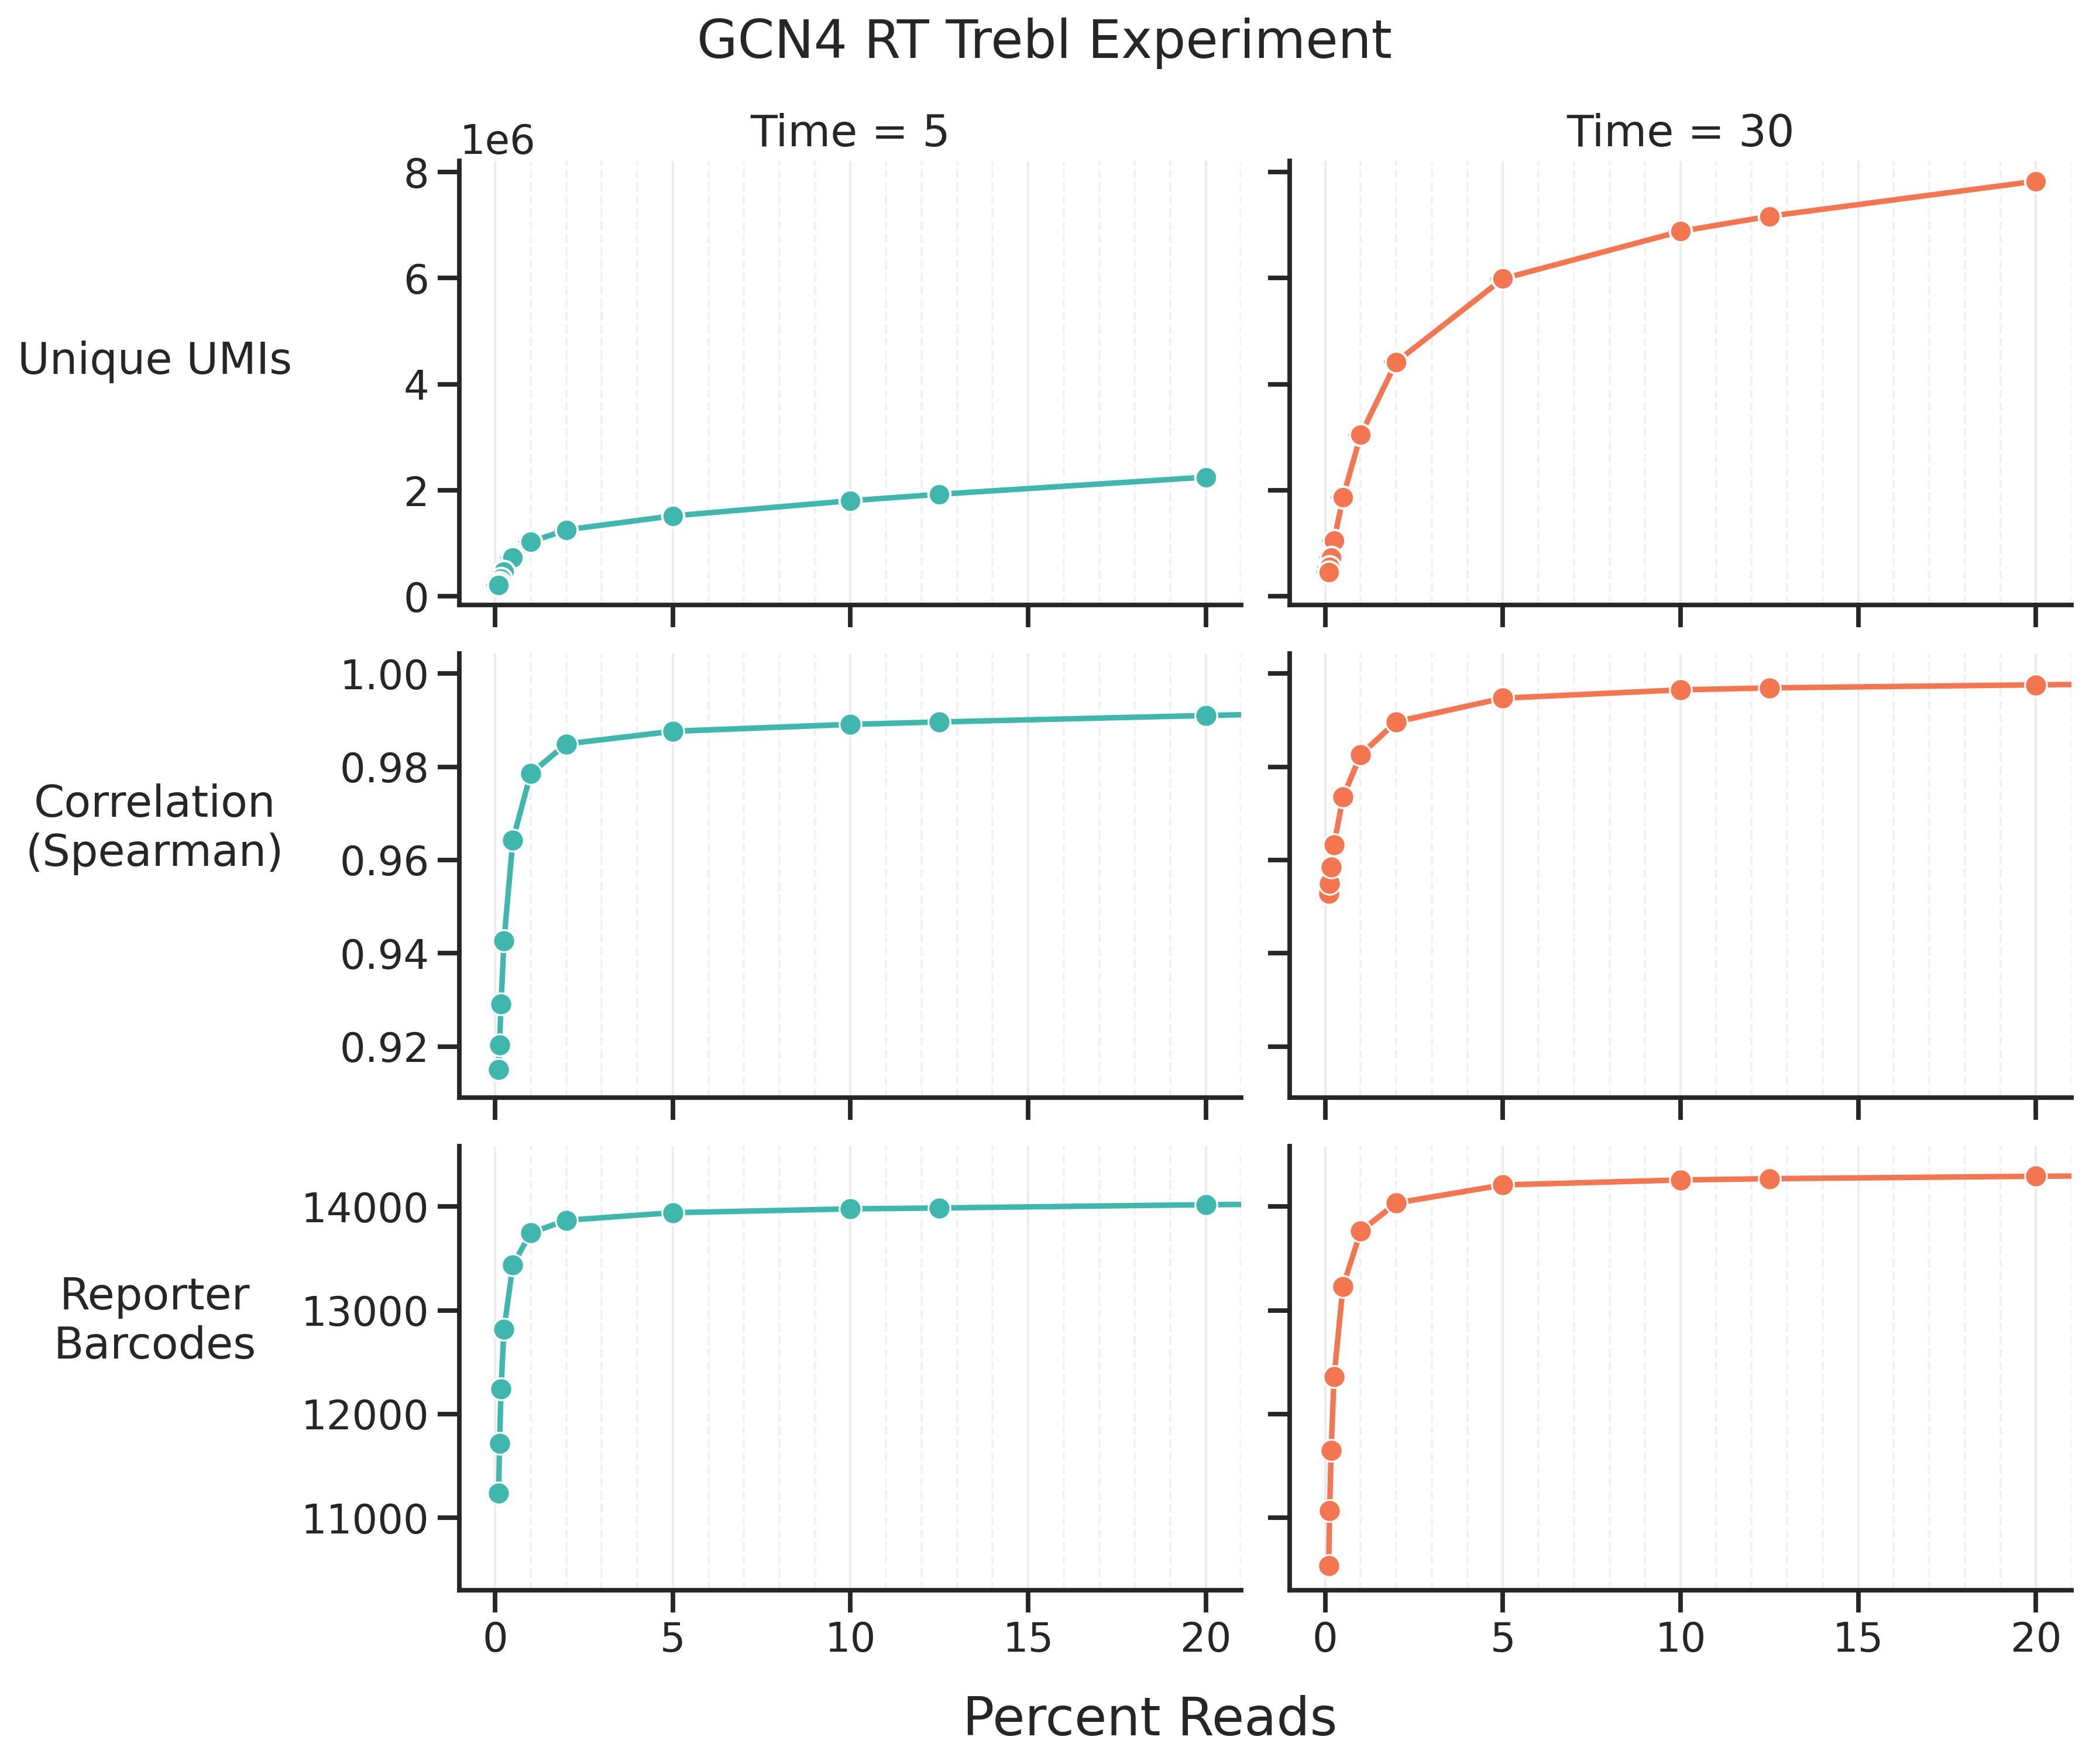

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 10),
    dpi=300,
    sharex=True,
    sharey = 'row'
)

# =========================
# Row 1 — Unique UMIs
# =========================

# ---- Time 5 ----
ax = axes[0, 0]
ax.errorbar(
    x=time_5_summary.iloc[5:]['percent_reads'],
    y=time_5_summary.iloc[5:][('unique_umis', 'mean')],
    yerr=time_5_summary.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t5_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 5")
ax.set_ylabel("Unique UMIs", rotation = 0, labelpad=60)
sns.despine(ax=ax)

# ---- Time 30 ----
ax = axes[0, 1]
ax.errorbar(
    x=time_30_summary.iloc[5:]['percent_reads'],
    y=time_30_summary.iloc[5:][('unique_umis', 'mean')],
    yerr=time_30_summary.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t30_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'

)
ax.set_title("Time = 30")
sns.despine(ax=ax)


# =========================
# Row 2 — Spearman correlation
# =========================

sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 0],
    color=t5_color
)
axes[1, 0].set_ylabel("Correlation\n(Spearman)", rotation = 0, labelpad=60)
sns.despine(ax=axes[1, 0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 1],
    color=t30_color
)
sns.despine(ax=axes[1, 1])


# =========================
# Row 3 — Reporter barcodes
# =========================

sns.lineplot(
    data=correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 0],
    color=t5_color
)
axes[2, 0].set_ylabel("Reporter\nBarcodes", rotation = 0, labelpad=60)
sns.despine(ax=axes[2, 0])

sns.lineplot(
    data=correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 1],
    color=t30_color
)
sns.despine(ax=axes[2, 1])
axes[2, 1].set_ylabel("")


# =========================
# Shared formatting
# =========================

for ax in axes.flatten():
    ax.set_xlim(-1, 21)

    # Major vertical grid
    ax.grid(True, which='major', axis='x',
            linestyle='-', color='gray', alpha=0.15, linewidth=1)

    # Minor vertical grid every 1%
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(True, which='minor', axis='x',
            linestyle='--', color='gray', alpha=0.1, linewidth=1)

    # Hide minor tick marks (keep grid)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_xlabel("")

# Global labels
fig.supxlabel("Percent Reads",x = 0.55)
fig.suptitle("GCN4 RT Trebl Experiment", y=0.995)
fig.align_ylabels()

plt.tight_layout(pad=0.6)
plt.show()

### Reads per UMI

#### T = 5

In [24]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

dfs = []

folder = Path("../../output/GCN4/downsampling/")
chunk_files_t5 = sorted(folder.glob("*RPTR_1_5*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))

# Appending the last
chunk_files_t5.append("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_fastp/RPTR_1_5_S2_R1_001_fastp_reads_per_umi.tsv")

for path in chunk_files_t5:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        downsample_pct = np.round(100 / num_chunks, 3)
    except:
        num_chunks = 1
        downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_100_chunks_part_1/RPTR_1_5_S2_R1_001_100_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_10_chunks_part_1/RPTR_1_5_S2_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_200_chunks_part_1/RPTR_1_5_S2_R1_001_200_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_20_chunks_part_1/RPTR_1_5_S2_R1_001_20_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_2_chunks_part_1/RPTR_1_5_S2_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_5_S2_R1_001_3_chunks_part_1/RPTR_1_5_S2_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeas

,reads,downsample,downsample_val
2999968,1,100.0%,100.0
2999969,1,100.0%,100.0
2999970,1,100.0%,100.0
2999971,1,100.0%,100.0
2999972,1,100.0%,100.0
...,...,...,...
2199939,2,0.1%,0.1
2199940,2,0.1%,0.1
2199941,2,0.1%,0.1
2199942,2,0.1%,0.1


In [25]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      200000
0.125      200000
0.100      200000
Name: count, dtype: int64

In [26]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
2999968,1,100.0%,100.0,0.00000
2999969,1,100.0%,100.0,0.00000
2999970,1,100.0%,100.0,0.00000
2999971,1,100.0%,100.0,0.00000
2999972,1,100.0%,100.0,0.00000
...,...,...,...,...
2199939,2,0.1%,0.1,0.30103
2199940,2,0.1%,0.1,0.30103
2199941,2,0.1%,0.1,0.30103
2199942,2,0.1%,0.1,0.30103


In [27]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 50, 33.333, 20, 10, 5,2, 1, 0.5])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
2999968,1,100.0%,100.0,0.0
2999969,1,100.0%,100.0,0.0
2999970,1,100.0%,100.0,0.0
2999971,1,100.0%,100.0,0.0
2999972,1,100.0%,100.0,0.0
...,...,...,...,...
400059,1,0.5%,0.5,0.0
400060,1,0.5%,0.5,0.0
400061,1,0.5%,0.5,0.0
400062,1,0.5%,0.5,0.0


In [28]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      200000
0.125      200000
0.100      200000
Name: count, dtype: int64

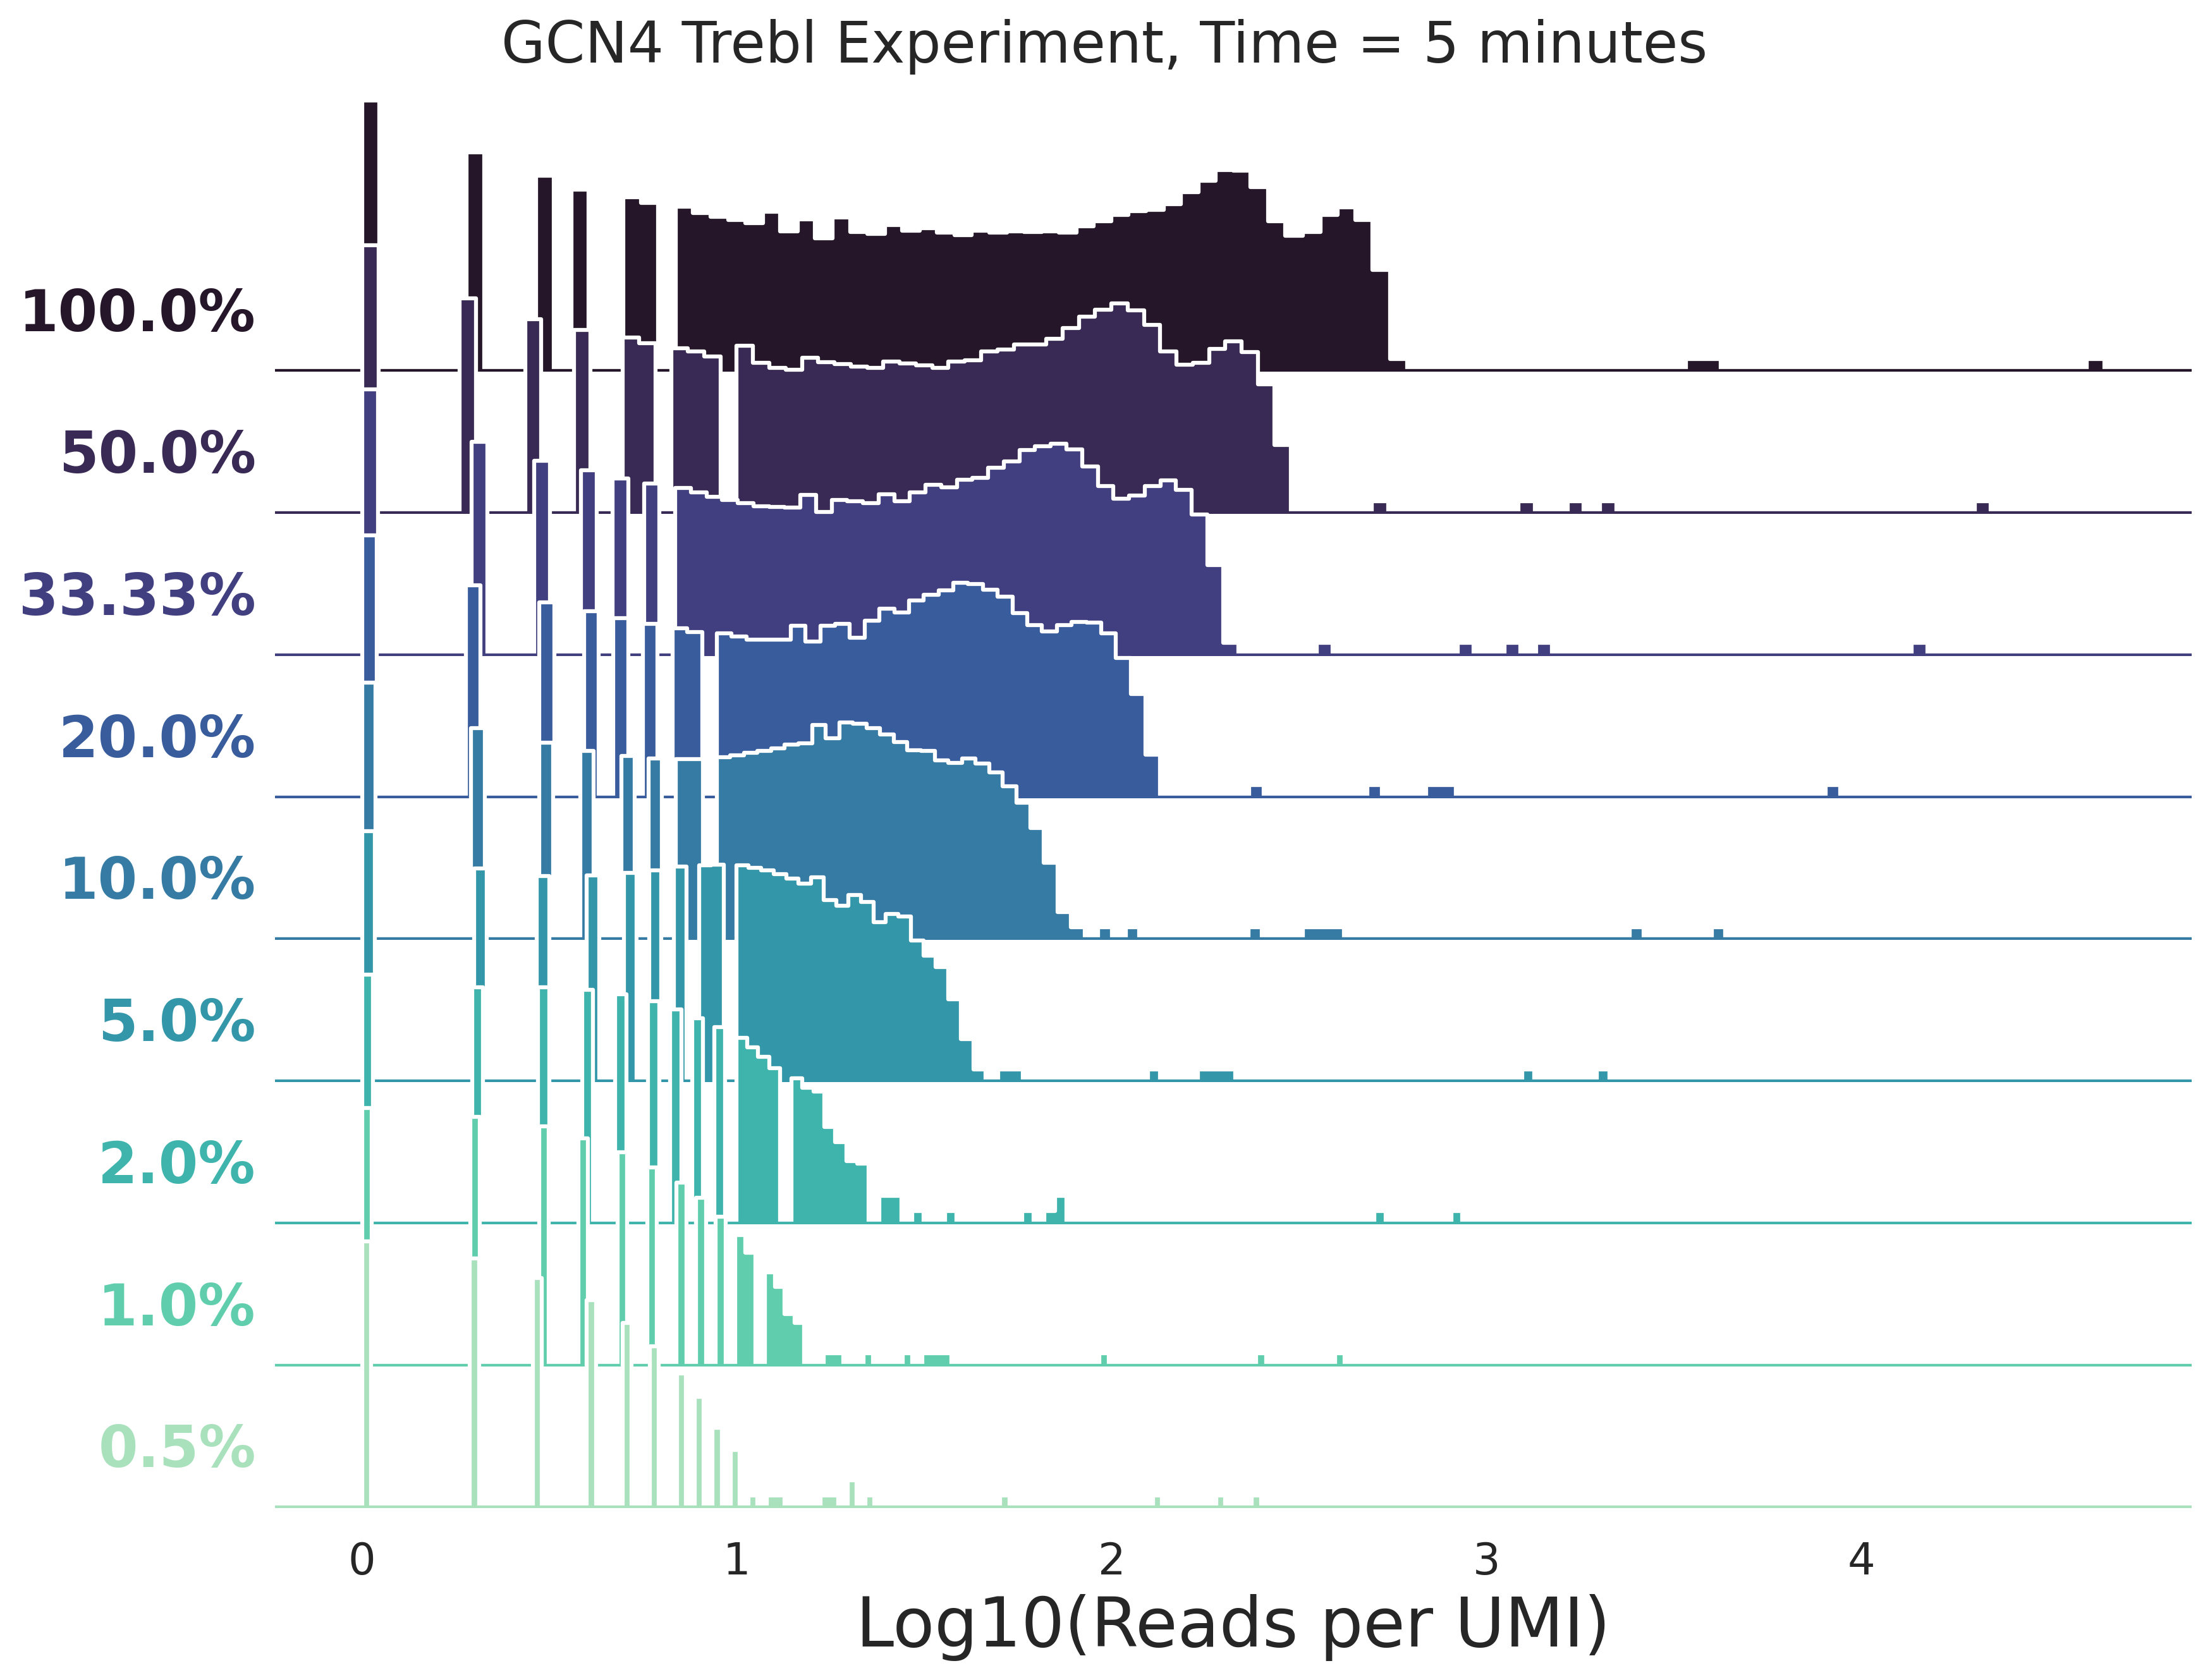

In [29]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=False)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=12,
    height=1,
    palette='mako',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='white',
        color=color,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=-0.5)
sns.despine(bottom = True, left=True)

# from matplotlib.ticker import AutoMinorLocator

# for ax in g.axes.flat:
#     # --- X axis minor ticks ---
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
#     ax.tick_params(
#         axis='x',
#         which='minor',
#         length=2,
#         width=0.6
#     )
#     ax.tick_params(
#         axis='x',
#         which='major',
#         length=4,
#         width=1
#     )

#     # # --- Y axis minor ticks (log scale) ---
#     # ax.minorticks_on()
#     # ax.tick_params(
#     #     axis='y',
#     #     which='minor',
#     #     length=2,
#     #     width=0.6
#     # )

g.fig.suptitle("GCN4 Trebl Experiment, Time = 5 minutes")
plt.show()

#### T = 30 min

In [30]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

dfs = []

folder = Path("../../output/GCN4/downsampling/")
chunk_files_t30 = sorted(folder.glob("*RPTR*1_30*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))

# Appending the last
chunk_files_t30.append("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp/RPTR_1_30_S5_R1_001_fastp_reads_per_umi.tsv")

for path in chunk_files_t30:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        
    except:
        num_chunks = 1
    downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_100_chunks_part_1/RPTR_1_30_S5_R1_001_100_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_10_chunks_part_1/RPTR_1_30_S5_R1_001_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_200_chunks_part_1/RPTR_1_30_S5_R1_001_200_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_20_chunks_part_1/RPTR_1_30_S5_R1_001_20_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_2_chunks_part_1/RPTR_1_30_S5_R1_001_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_3_chunks_part_1/RPTR_1_30_S5_R1_001_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_exp

,reads,downsample,downsample_val
2999968,4,100.0%,100.0
2999969,4,100.0%,100.0
2999970,4,100.0%,100.0
2999971,4,100.0%,100.0
2999972,4,100.0%,100.0
...,...,...,...
2199939,1,0.1%,0.1
2199940,1,0.1%,0.1
2199941,1,0.1%,0.1
2199942,1,0.1%,0.1


In [31]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
2999968,4,100.0%,100.0,0.60206
2999969,4,100.0%,100.0,0.60206
2999970,4,100.0%,100.0,0.60206
2999971,4,100.0%,100.0,0.60206
2999972,4,100.0%,100.0,0.60206
...,...,...,...,...
2199939,1,0.1%,0.1,0.00000
2199940,1,0.1%,0.1,0.00000
2199941,1,0.1%,0.1,0.00000
2199942,1,0.1%,0.1,0.00000


In [32]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 50, 33.333, 20, 10, 5,2, 1, 0.5])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
2999968,4,100.0%,100.0,0.60206
2999969,4,100.0%,100.0,0.60206
2999970,4,100.0%,100.0,0.60206
2999971,4,100.0%,100.0,0.60206
2999972,4,100.0%,100.0,0.60206
...,...,...,...,...
400059,2,0.5%,0.5,0.30103
400060,2,0.5%,0.5,0.30103
400061,2,0.5%,0.5,0.30103
400062,2,0.5%,0.5,0.30103


In [33]:
all_df_filtered["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
20.000     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
Name: count, dtype: int64

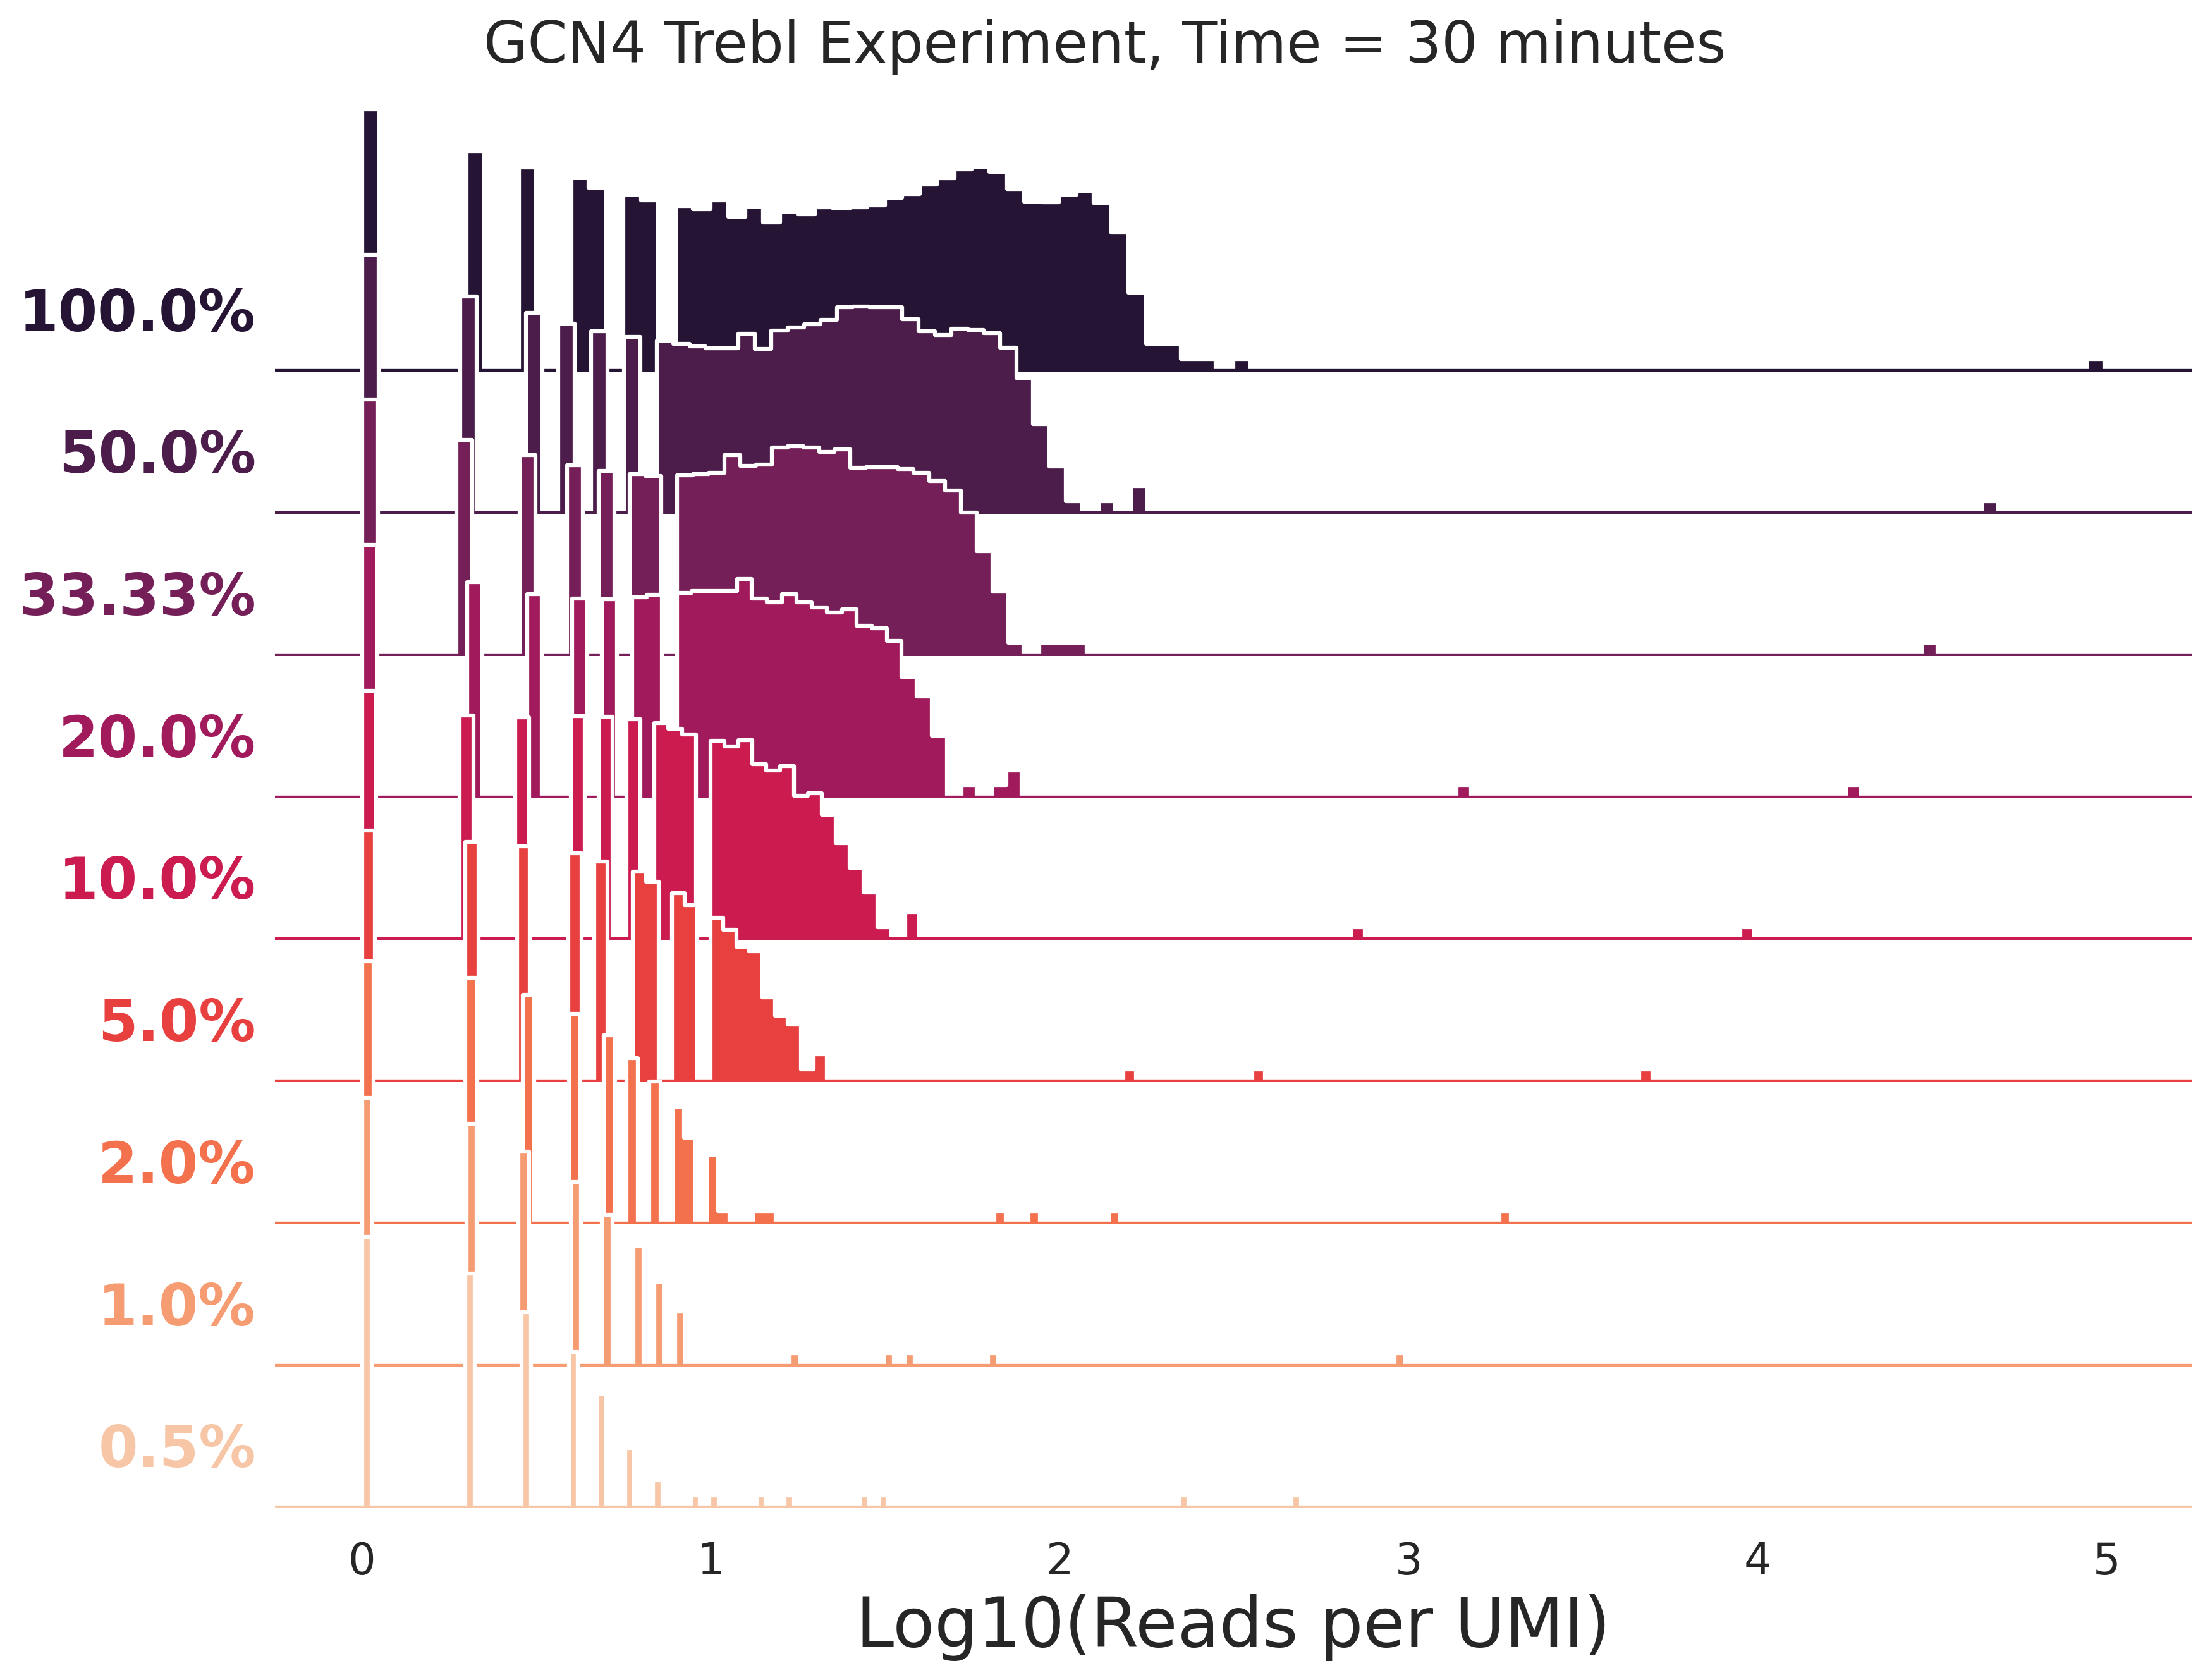

In [34]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=False)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=12,
    height=1,
    palette='rocket',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='white',
        color=color,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=-0.5)
sns.despine(bottom = True, left=True)

g.fig.suptitle("GCN4 Trebl Experiment, Time = 30 minutes")
plt.show()

## AD

### Reading in data

In [53]:
ad_time_5_summary = pd.read_csv("../../output/gcn4_ad_downsampling_t5_summary.csv", index_col=0, header=[0,1])
ad_time_5_summary

num_splits      percent_reads               time   unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1          mean   
0            1.000000                100                  5  7.296612e+06   
1            1.333333                 75                  5  6.979408e+06   
2            2.000000                 50                  5  5.853529e+06   
3            3.000000                 33                  5  2.522984e+06   
4            4.000000                 25                  5  5.799205e+06   
5            5.000000                 20                  5  5.515678e+06   
6            8.000000                 12                  5  4.602410e+06   
7           10.000000                 10                  5  4.171905e+06   
8           20.000000                  5                  5  2.872263e+06   
9           50.000000                  2                  5  1.725904e+06   
10         100.000000                  1                  5  9.761396e+05   
11         200.000000                  0                  5  5.059722e+05   
12         400.000000                  0                  5  2.514032e+05   
13         600.000000                  0                  5  1.745739e+05   
14         800.000000                  0                  5  1.379528e+05   
15        1000.000000                  0                  5  1.074688e+05   

                  
             std  
0            NaN  
1   2.595082e+02  
2   1.979899e+02  
3   2.241458e+06  
4   1.237351e+03  
5   2.491195e+03  
6   3.107472e+05  
7   2.981734e+05  
8   1.943580e+05  
9   5.859549e+02  
10  5.358907e+02  
11  3.688164e+04  
12  4.778734e+04  
13  1.415219e+04  
14  1.249808e+02  
15  7.868815e+03

In [54]:
ad_time_30_summary = pd.read_csv("../../output/gcn4_ad_downsampling_t30_summary.csv", index_col=0, header=[0,1])
ad_time_30_summary

num_splits      percent_reads               time unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1        mean   
0            1.000000                100                 30  7577393.00   
1            1.333333                 75                 30  7231655.00   
2            2.000000                 50                 30  6063403.00   
3            3.000000                 33                 30  5834608.00   
4            4.000000                 25                 30  5936298.00   
5            5.000000                 20                 30  5632368.60   
6            8.000000                 12                 30  4689521.25   
7           10.000000                 10                 30  4250561.20   
8           20.000000                  5                 30  2935299.60   
9           50.000000                  2                 30  1771822.60   
10         100.000000                  1                 30  1006009.60   
11         200.000000                  0                 30   539860.00   
12         400.000000                  0                 30   260140.50   
13         600.000000                  0                 30   184243.00   
14         800.000000                  0                 30   142873.20   
15        1000.000000                  0                 30   114651.40   

                   
              std  
0             NaN  
1      199.404112  
2     1046.518036  
3   408802.980563  
4      208.822093  
5     1223.666744  
6   311257.877390  
7   300409.788128  
8   196741.758179  
9      308.768198  
10     430.568578  
11     181.613601  
12   49514.377293  
13   12332.271664  
14      83.016263  
15     154.083743

In [55]:
t5_ad_color = sns.color_palette(t5_palette)[2]
t30_ad_color = sns.color_palette(t30_palette)[2]


In [56]:
sns.color_palette(t30_palette)

[(0.96516917, 0.70776351, 0.5606593),
 (0.95381595, 0.46373781, 0.31769923),
 (0.8833417, 0.19830556, 0.26014181),
 (0.67824099, 0.09192342, 0.3504148),
 (0.43860848, 0.12177004, 0.34119475),
 (0.20973515, 0.09747934, 0.24238489)]

In [57]:
sns.color_palette(t5_palette)

[(0.54578602, 0.8544913, 0.69848331),
 (0.25187832, 0.71827158, 0.67872193),
 (0.20344718, 0.56074869, 0.65649508),
 (0.21607792, 0.39736958, 0.61948028),
 (0.25307401, 0.23772973, 0.48316271),
 (0.18195582, 0.11955283, 0.23136943)]

### Reads vs unique UMIs

In [58]:
ad_time_5_summary

num_splits      percent_reads               time   unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1          mean   
0            1.000000                100                  5  7.296612e+06   
1            1.333333                 75                  5  6.979408e+06   
2            2.000000                 50                  5  5.853529e+06   
3            3.000000                 33                  5  2.522984e+06   
4            4.000000                 25                  5  5.799205e+06   
5            5.000000                 20                  5  5.515678e+06   
6            8.000000                 12                  5  4.602410e+06   
7           10.000000                 10                  5  4.171905e+06   
8           20.000000                  5                  5  2.872263e+06   
9           50.000000                  2                  5  1.725904e+06   
10         100.000000                  1                  5  9.761396e+05   
11         200.000000                  0                  5  5.059722e+05   
12         400.000000                  0                  5  2.514032e+05   
13         600.000000                  0                  5  1.745739e+05   
14         800.000000                  0                  5  1.379528e+05   
15        1000.000000                  0                  5  1.074688e+05   

                  
             std  
0            NaN  
1   2.595082e+02  
2   1.979899e+02  
3   2.241458e+06  
4   1.237351e+03  
5   2.491195e+03  
6   3.107472e+05  
7   2.981734e+05  
8   1.943580e+05  
9   5.859549e+02  
10  5.358907e+02  
11  3.688164e+04  
12  4.778734e+04  
13  1.415219e+04  
14  1.249808e+02  
15  7.868815e+03

In [59]:
ad_time_5_summary["percent_reads"] = 100 / ad_time_5_summary[('num_splits', 'Unnamed: 1_level_1')]
ad_time_30_summary["percent_reads"] = 100 / ad_time_30_summary[('num_splits', 'Unnamed: 1_level_1')]

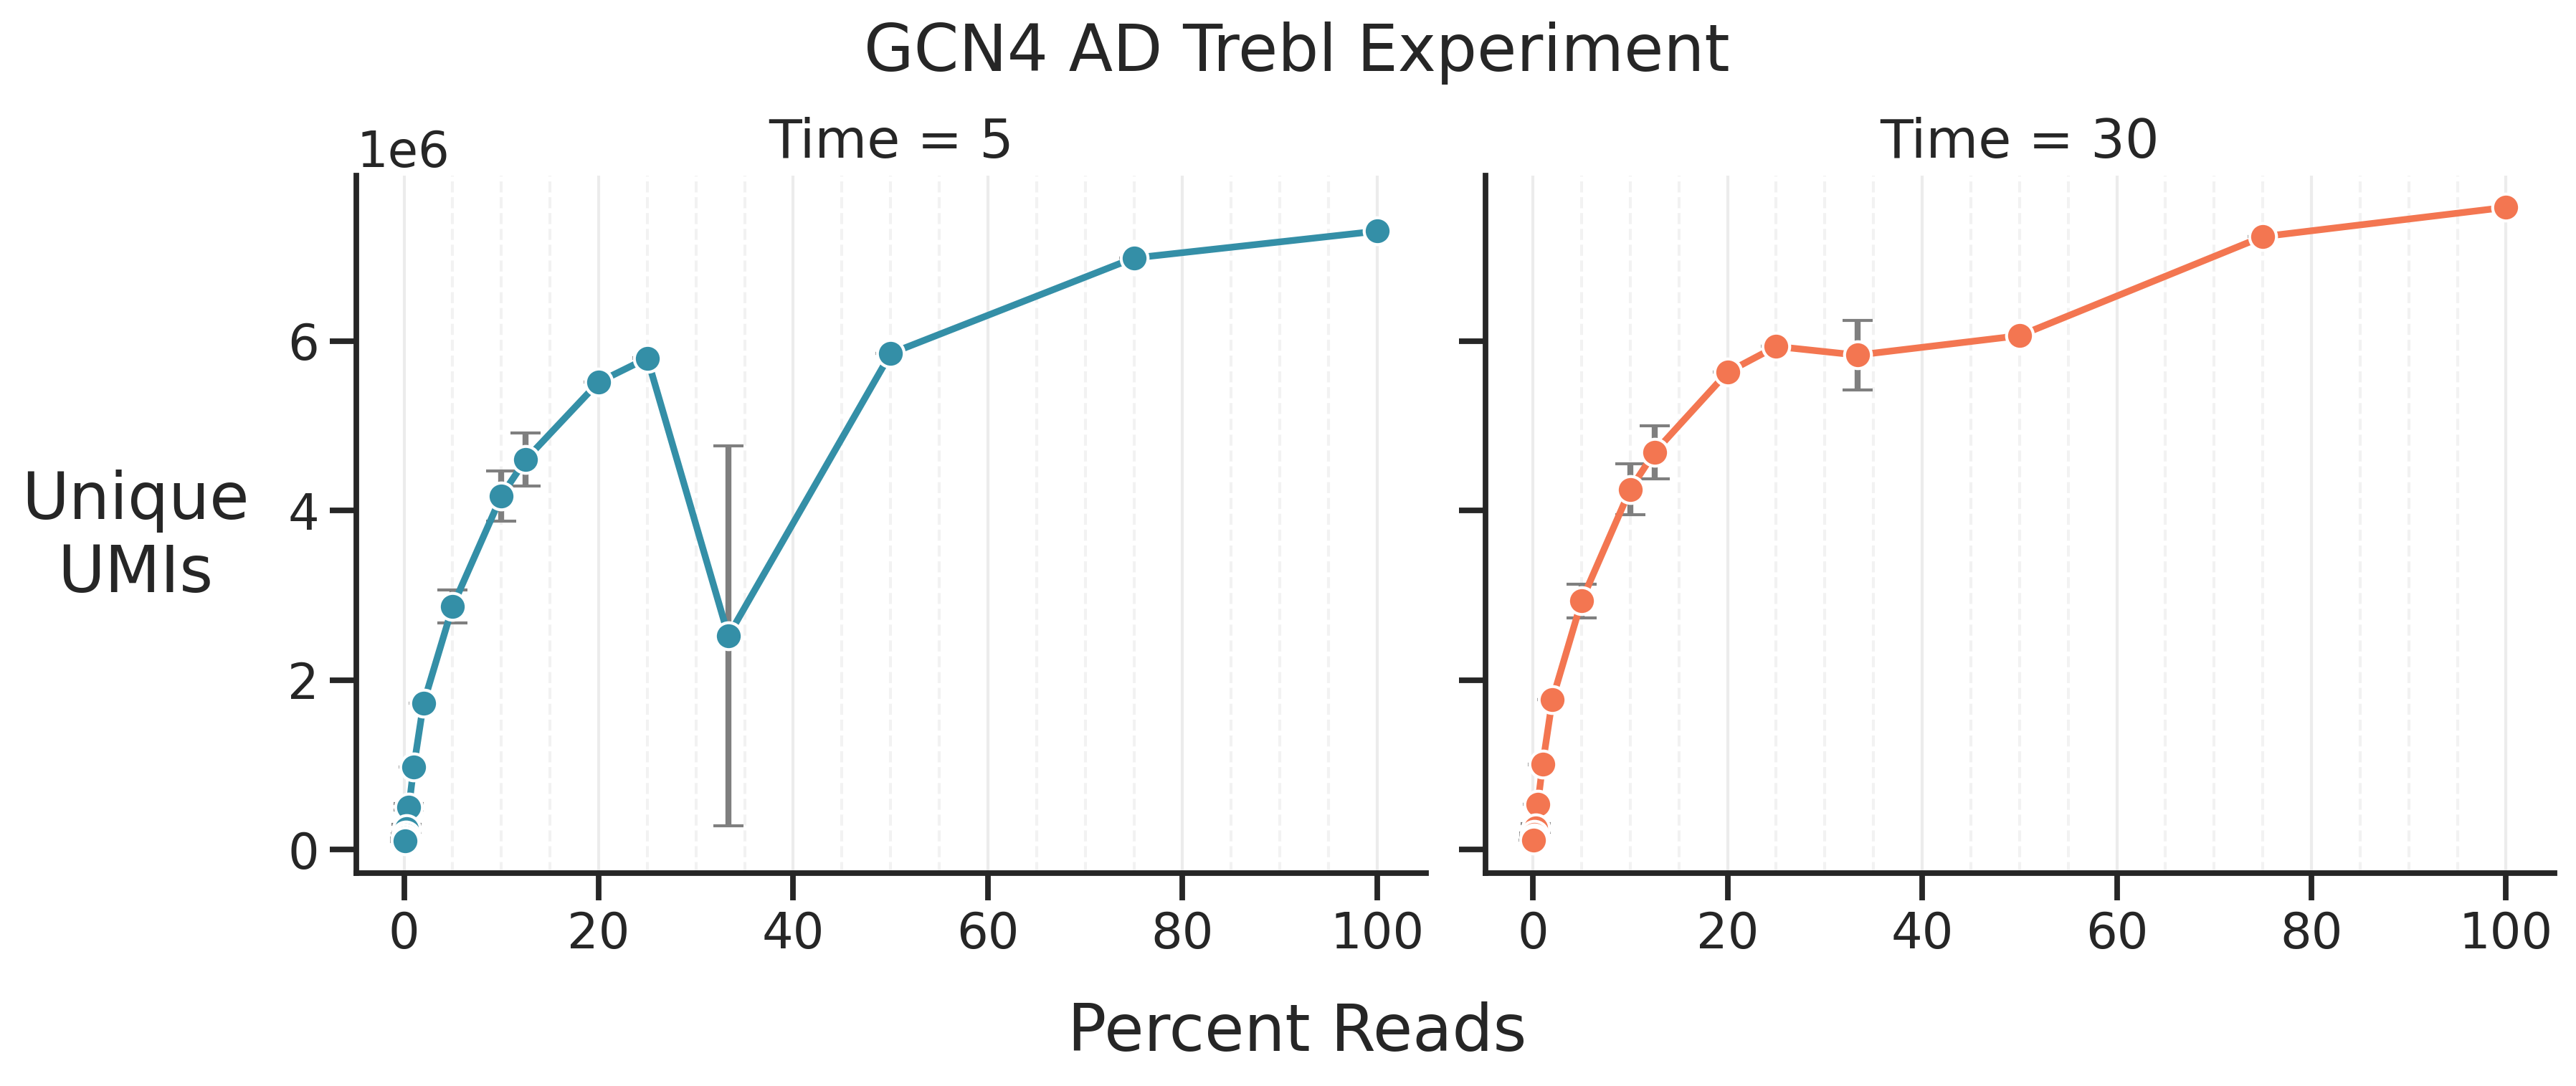

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Time 5 ----------
ax = axes[0]
x_5 = ad_time_5_summary['percent_reads']
y_mean_5 = ad_time_5_summary[('unique_umis', 'mean')]
y_std_5 = ad_time_5_summary[('unique_umis', 'std')]

ax.errorbar(
    x=x_5,
    y=y_mean_5,
    yerr=y_std_5,
    fmt='-o',
    capsize=5,
    color=t5_ad_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 5")
ax.set_xlabel("")
# ax.set_ylabel("Unique UMIs")
sns.despine(ax=ax)

# ---------- Time 30 ----------
ax = axes[1]
x_30 = ad_time_30_summary['percent_reads']
y_mean_30 = ad_time_30_summary[('unique_umis', 'mean')]
y_std_30 = ad_time_30_summary[('unique_umis', 'std')]

ax.errorbar(
    x=x_30,
    y=y_mean_30,
    yerr=y_std_30,
    fmt='-o',
    capsize=5,
    color=t30_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 30")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(ax=ax)

# --- Shared X limits and ticks ---
all_x = np.concatenate([x_5, x_30])
x_min, x_max = all_x.min(), all_x.max()
for ax in axes:
    #ax.set_xlim(x_min - 1e7, x_max + 1e7)
    #ax.set_ylim(0, max(y_mean_5.max(), y_mean_30.max()) * 1.05)

    # Major and minor vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    ax.xaxis.set_minor_locator(MultipleLocator(5))  # minor tick every 50M reads
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)

# Super labels and title
fig.supxlabel("Percent Reads")
fig.supylabel("Unique\nUMIs", rotation = 0, ha = 'center', x = 0.05)
fig.suptitle("GCN4 AD Trebl Experiment")

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs correlation

In [61]:
ad_correlation_df = pd.read_csv("../../output/GCN4_AD_downsampling_correlation_results.csv")
ad_correlation_df#["percent_reads"].value_counts()

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,../../output/GCN4/downsampling/trebl_experimen...,0.994656,0.965426,13734,200.0,0.5,30
1,../../output/GCN4/downsampling/trebl_experimen...,0.997653,0.997188,13921,10.0,10.0,5
2,../../output/GCN4/downsampling/trebl_experimen...,0.997604,0.996707,14178,20.0,5.0,30
3,../../output/GCN4/downsampling/trebl_experimen...,0.993623,0.964998,13736,200.0,0.5,30
4,../../output/GCN4/downsampling/trebl_experimen...,0.996653,0.994363,13903,20.0,5.0,5
...,...,...,...,...,...,...,...
164,../../output/GCN4/downsampling/trebl_experimen...,0.999386,0.999451,14207,5.0,20.0,30
165,../../output/GCN4/downsampling/trebl_experimen...,0.997270,0.996823,14180,20.0,5.0,30
166,../../output/GCN4/downsampling/trebl_experimen...,0.998536,0.998611,13925,5.0,20.0,5
167,../../output/GCN4/downsampling/trebl_experimen...,0.999560,0.999591,14214,4.0,25.0,30


In [62]:
# Filter data for time = 5 and time = 30
ad_correlation_df_5 = ad_correlation_df[ad_correlation_df["time"] == 5]
ad_correlation_df_30 = ad_correlation_df[ad_correlation_df["time"] == 30]


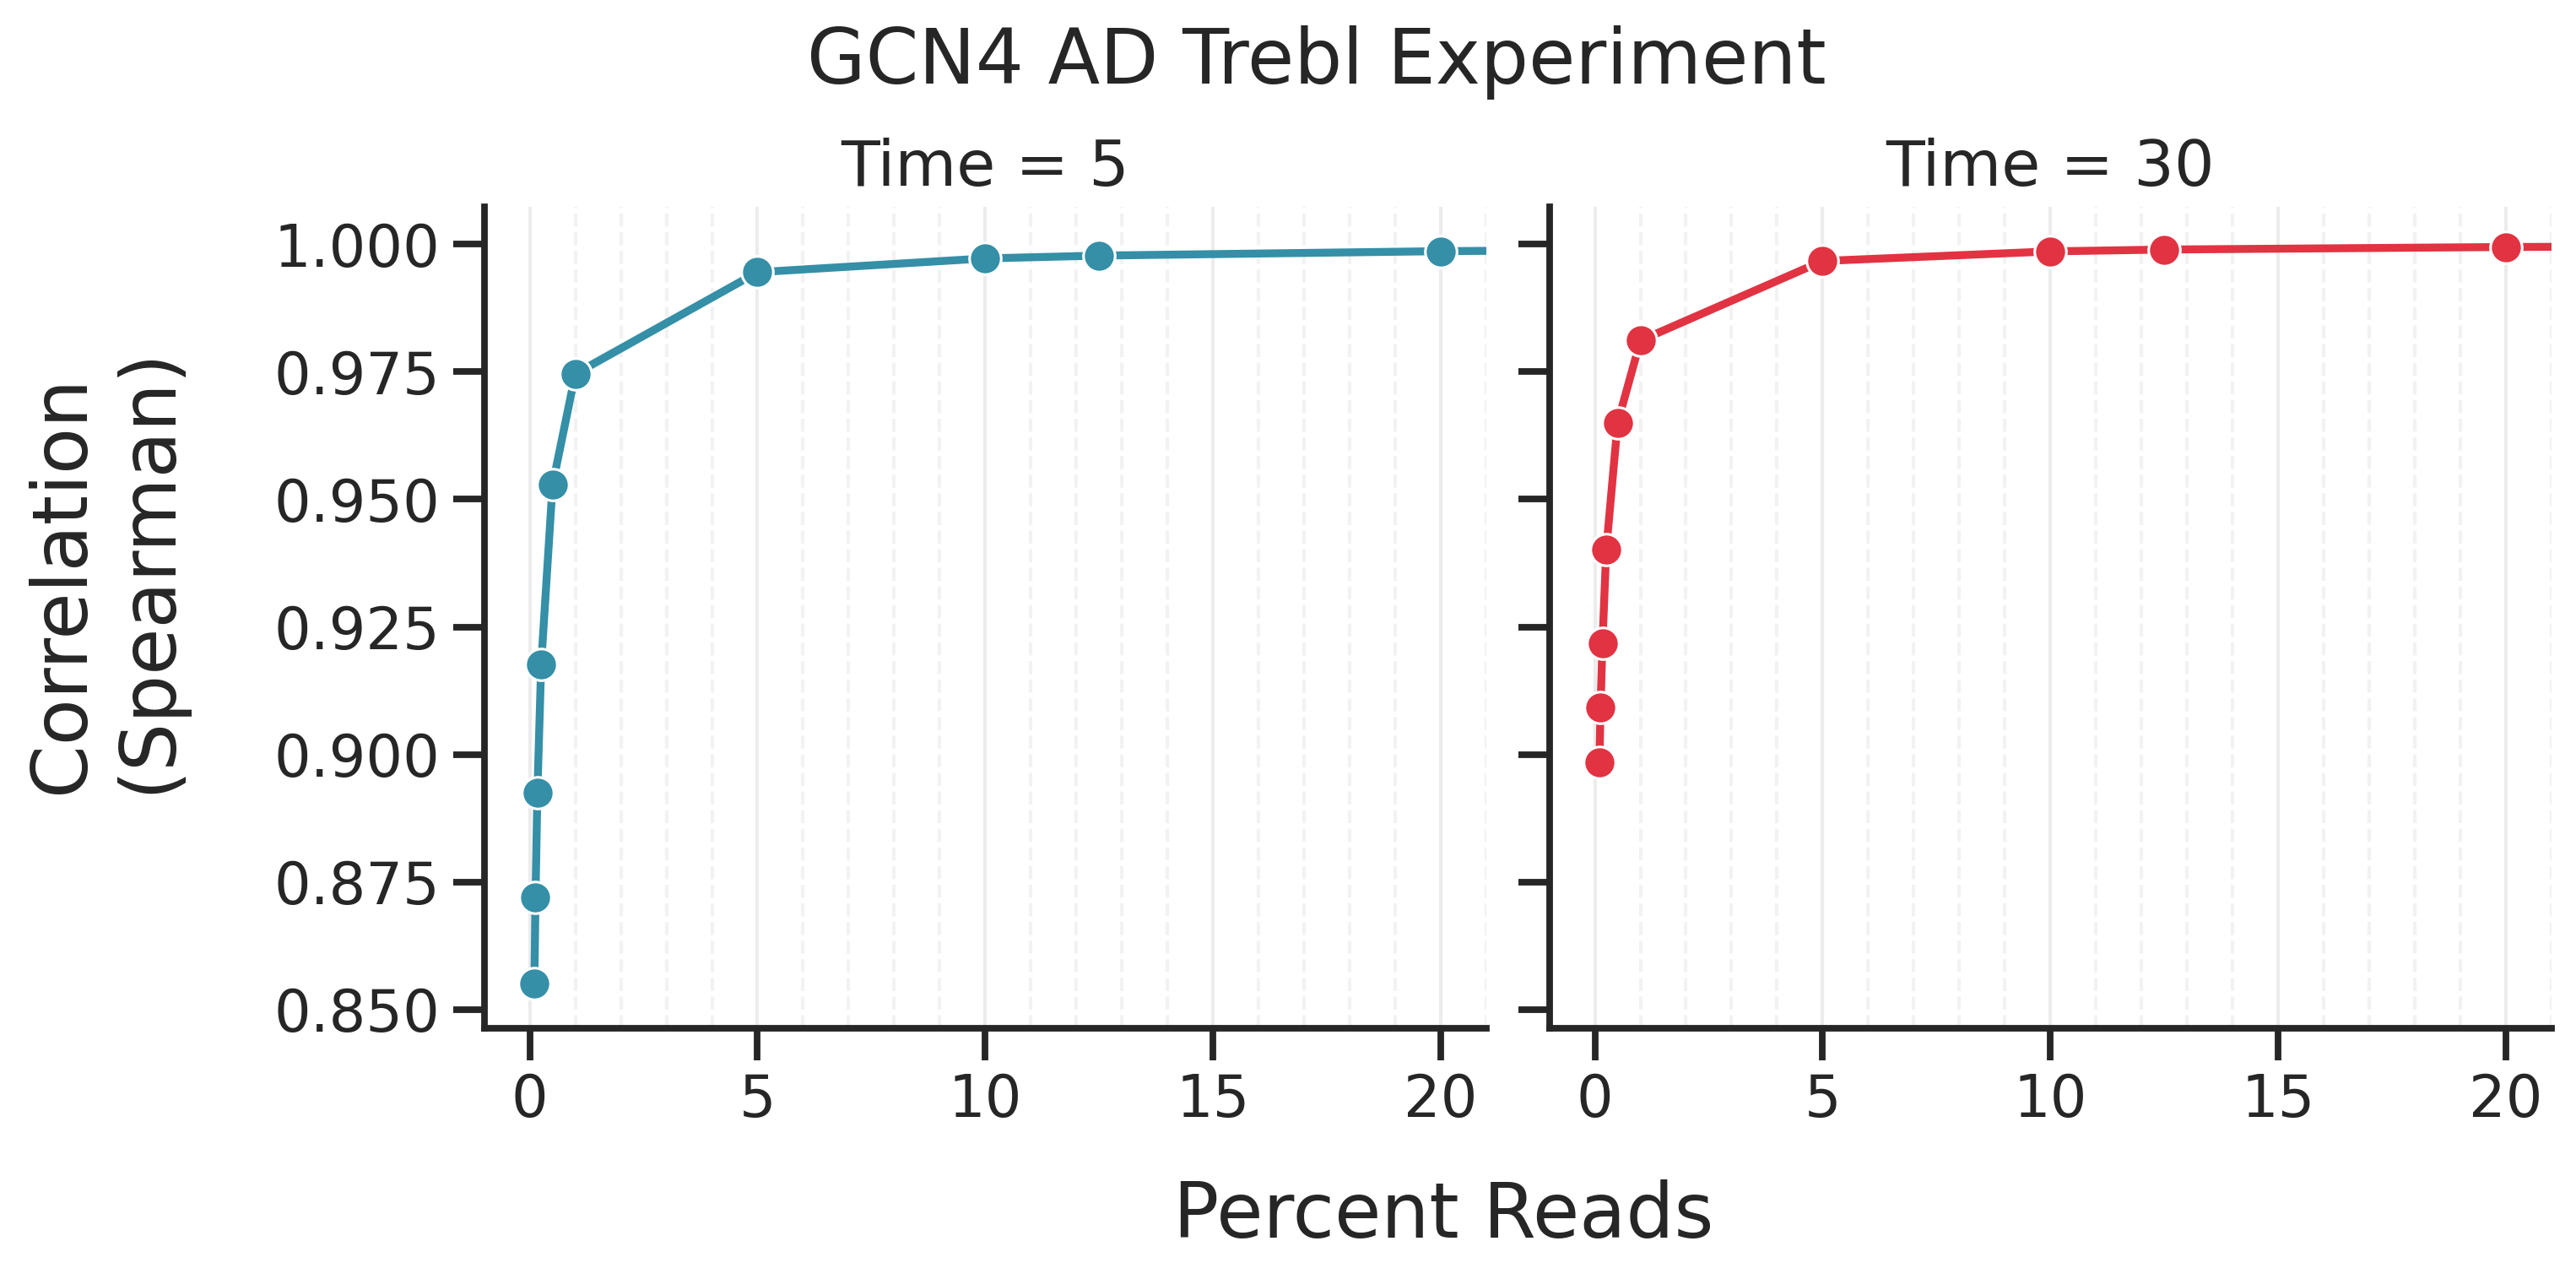

In [63]:
sns.set_context("talk")
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Spearman only ----------
sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_ad_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_ad_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 AD Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

plt.tight_layout(pad=0.5)
plt.show()

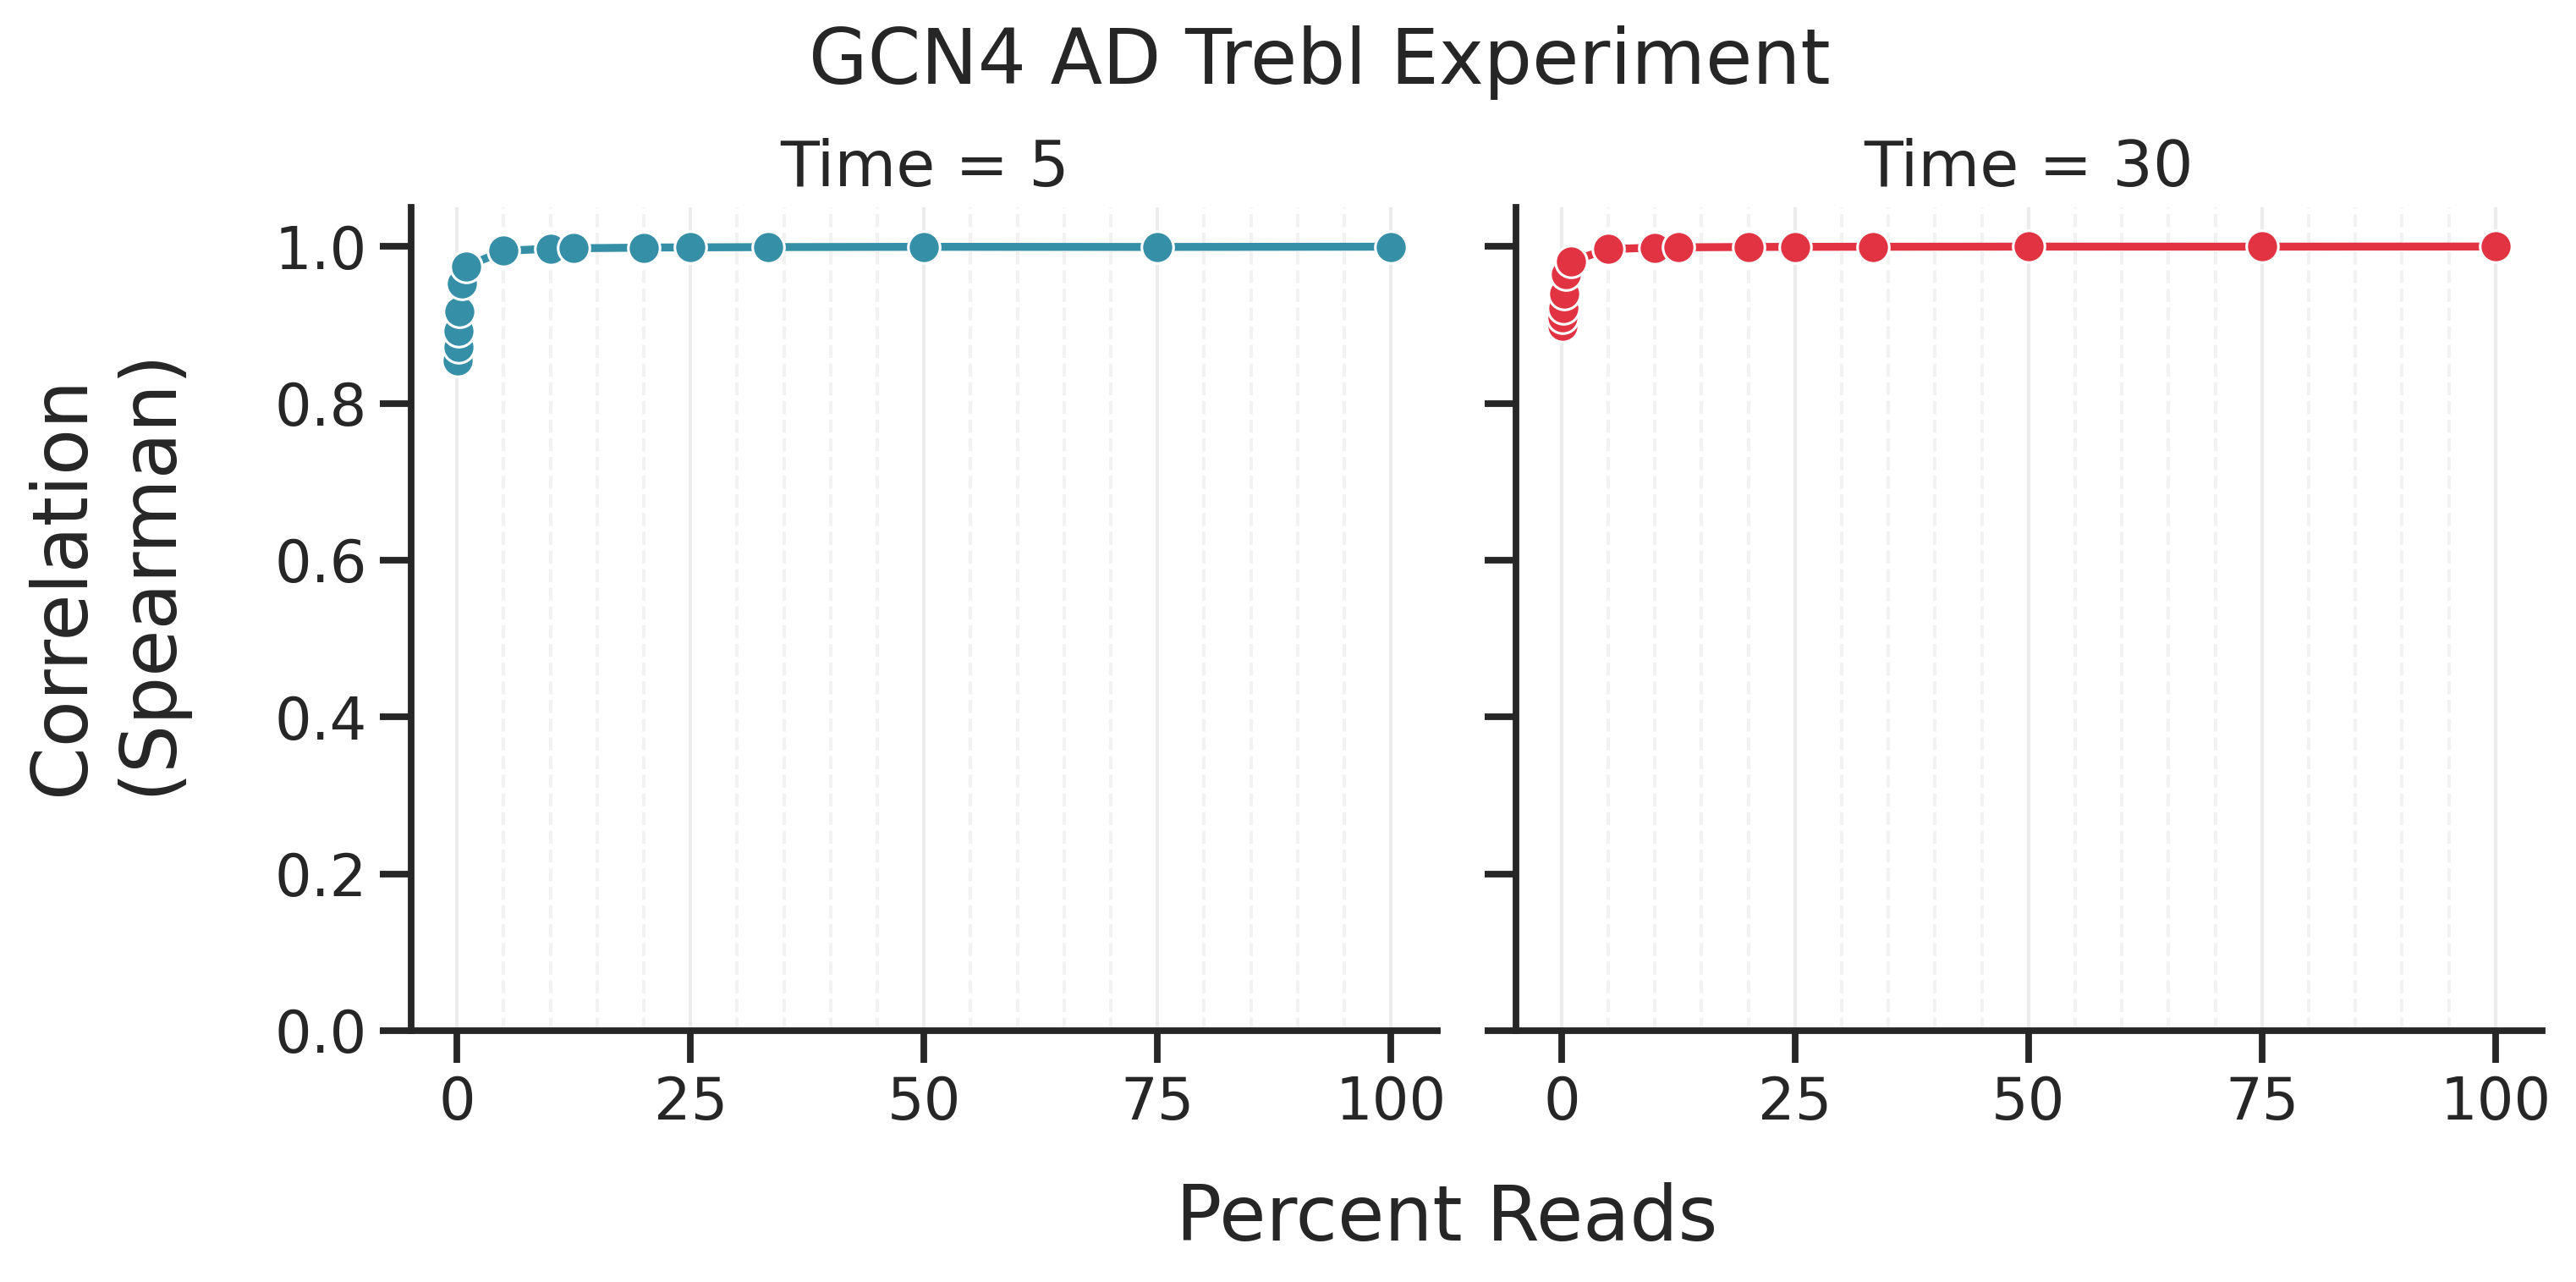

In [64]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)
sns.set_context("talk")

# ---------- Spearman only ----------
sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_ad_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_ad_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 AD Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0, 1.05)

plt.tight_layout(pad=0.5)
plt.show()

In [49]:
ad_correlation_df_5

,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
1,../../output/GCN4/downsampling/trebl_experimen...,0.997653,0.997188,13921,10.0,10.000000,5
4,../../output/GCN4/downsampling/trebl_experimen...,0.996653,0.994363,13903,20.0,5.000000,5
5,../../output/GCN4/downsampling/trebl_experimen...,0.997487,0.994369,13906,20.0,5.000000,5
6,../../output/GCN4/downsampling/trebl_experimen...,0.997124,0.997174,13919,10.0,10.000000,5
7,../../output/GCN4/downsampling/trebl_experimen...,0.996451,0.994475,13903,20.0,5.000000,5
...,...,...,...,...,...,...,...
161,../../output/GCN4/downsampling/trebl_experimen...,0.982995,0.891522,12413,600.0,0.166667,5
162,../../output/GCN4/downsampling/trebl_experimen...,0.999490,0.998940,13926,4.0,25.000000,5
163,../../output/GCN4/downsampling/trebl_experimen...,0.995860,0.994591,13902,20.0,5.000000,5
166,../../output/GCN4/downsampling/trebl_experimen...,0.998536,0.998611,13925,5.0,20.000000,5


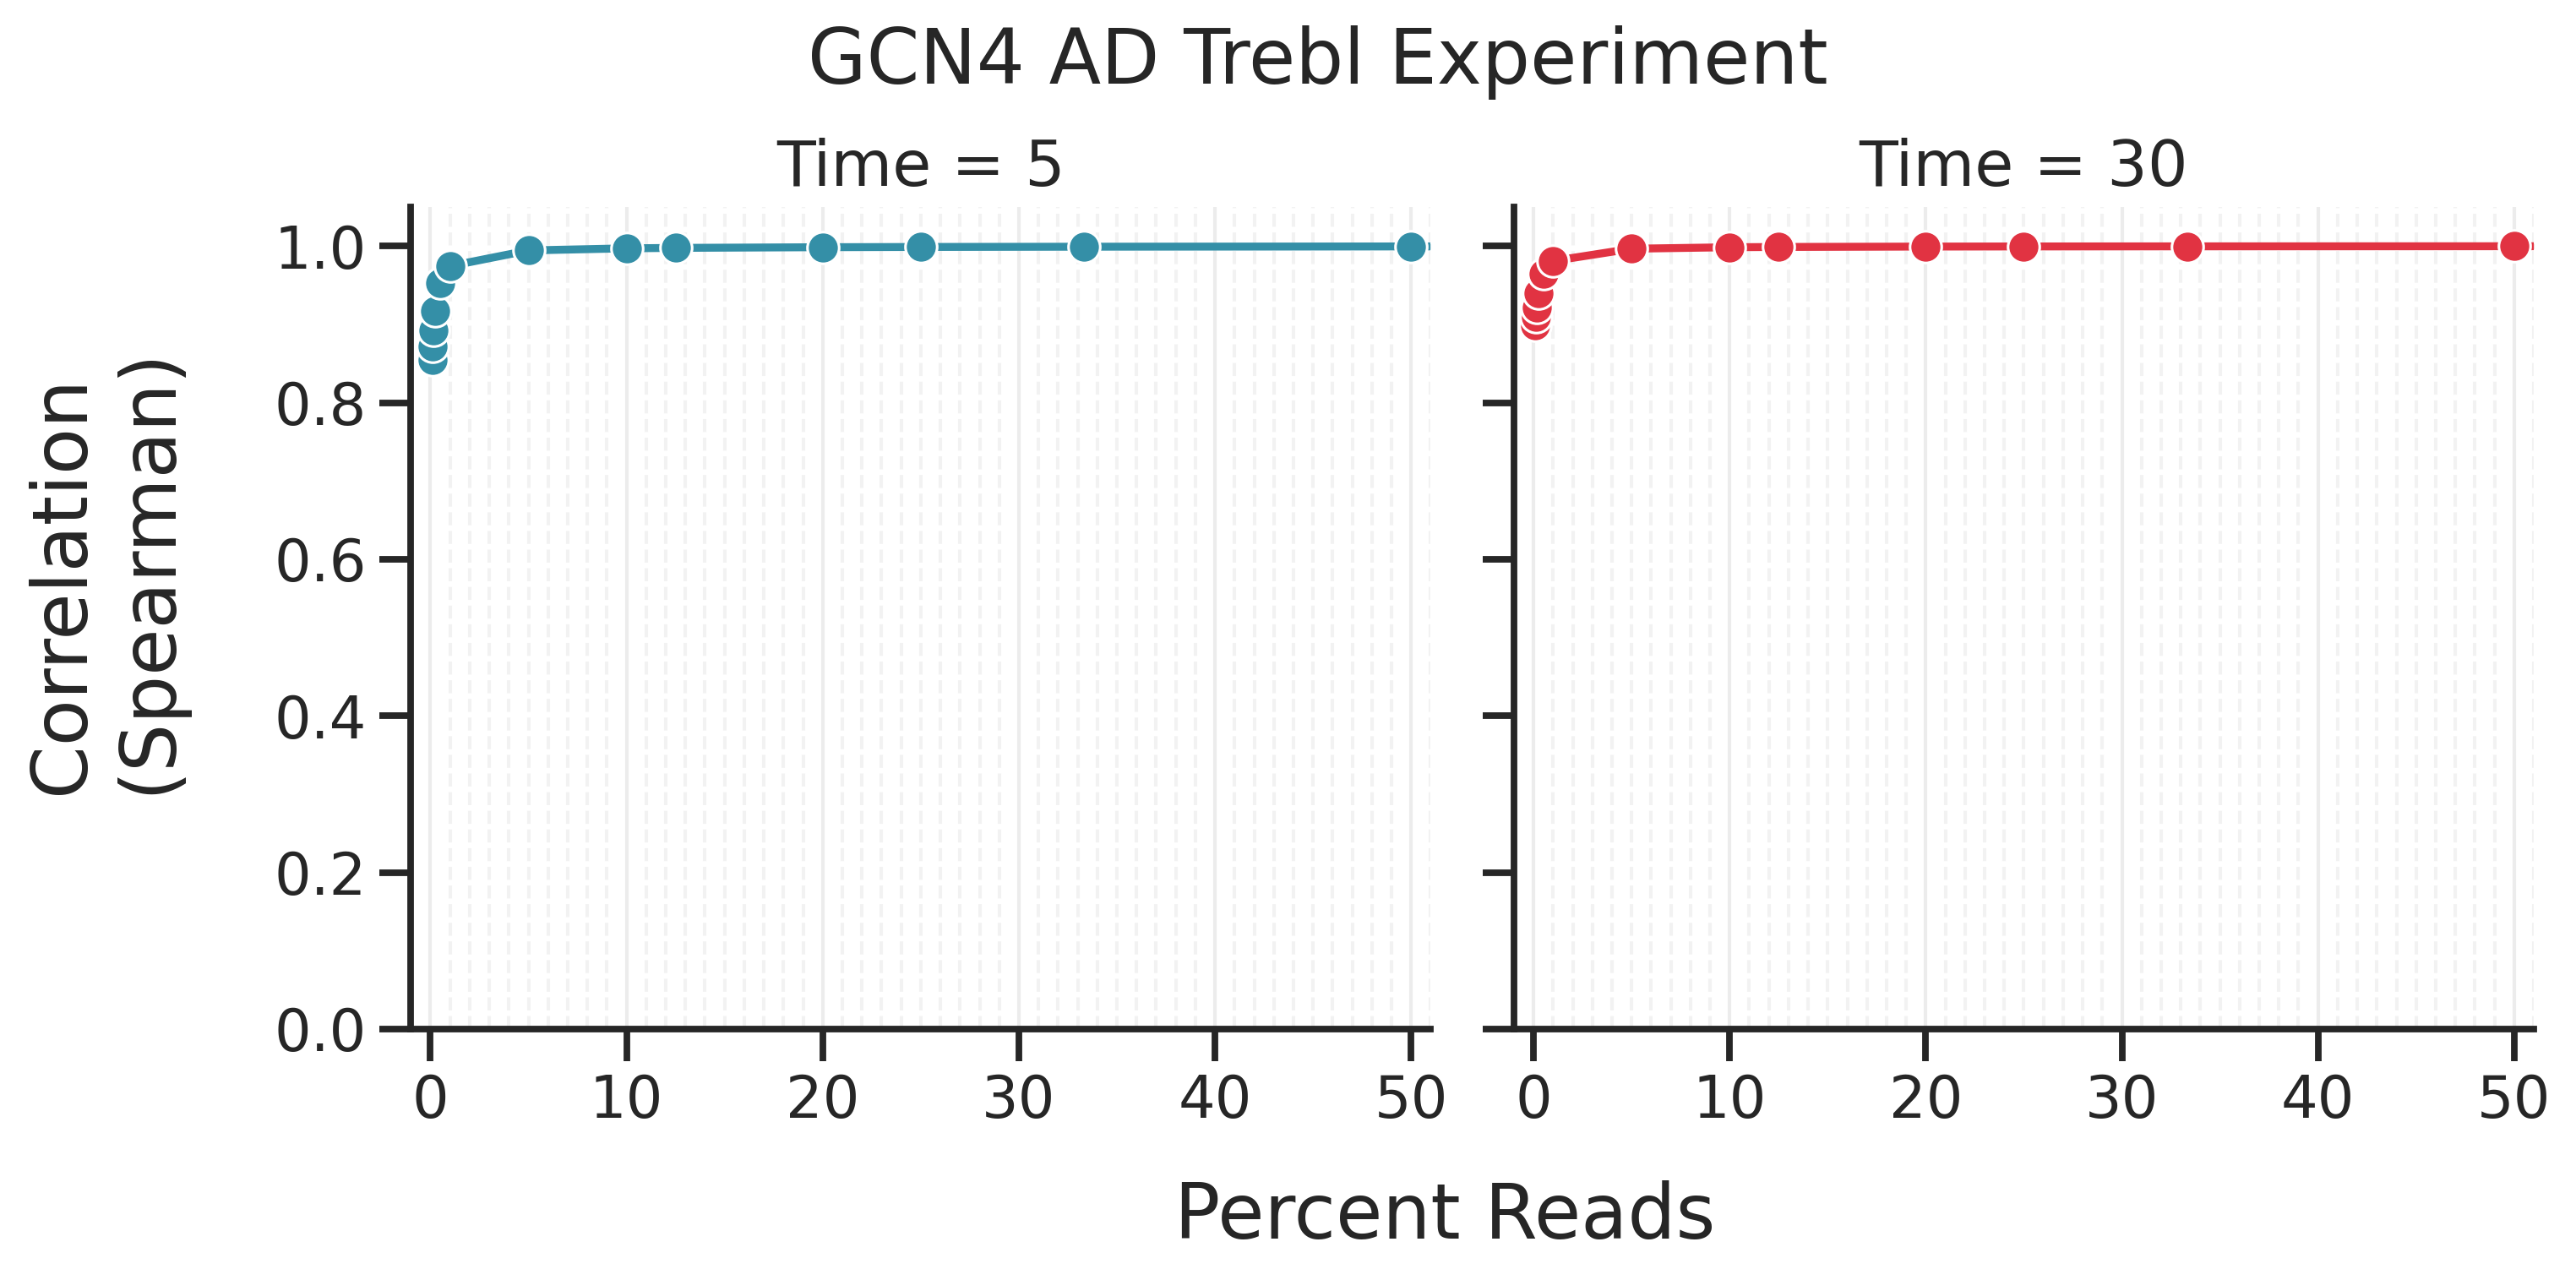

In [48]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)
sns.set_context("talk")

# ---------- Spearman only ----------
sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_ad_color
)
axes[0].set_title("Time = 5")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_ad_color
)
axes[1].set_title("Time = 30")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("GCN4 AD Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.xaxis.set_major_locator(MultipleLocator(10))

    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0, 1.05)
    ax.set_xlim(-1,51)

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs barcodes recovered

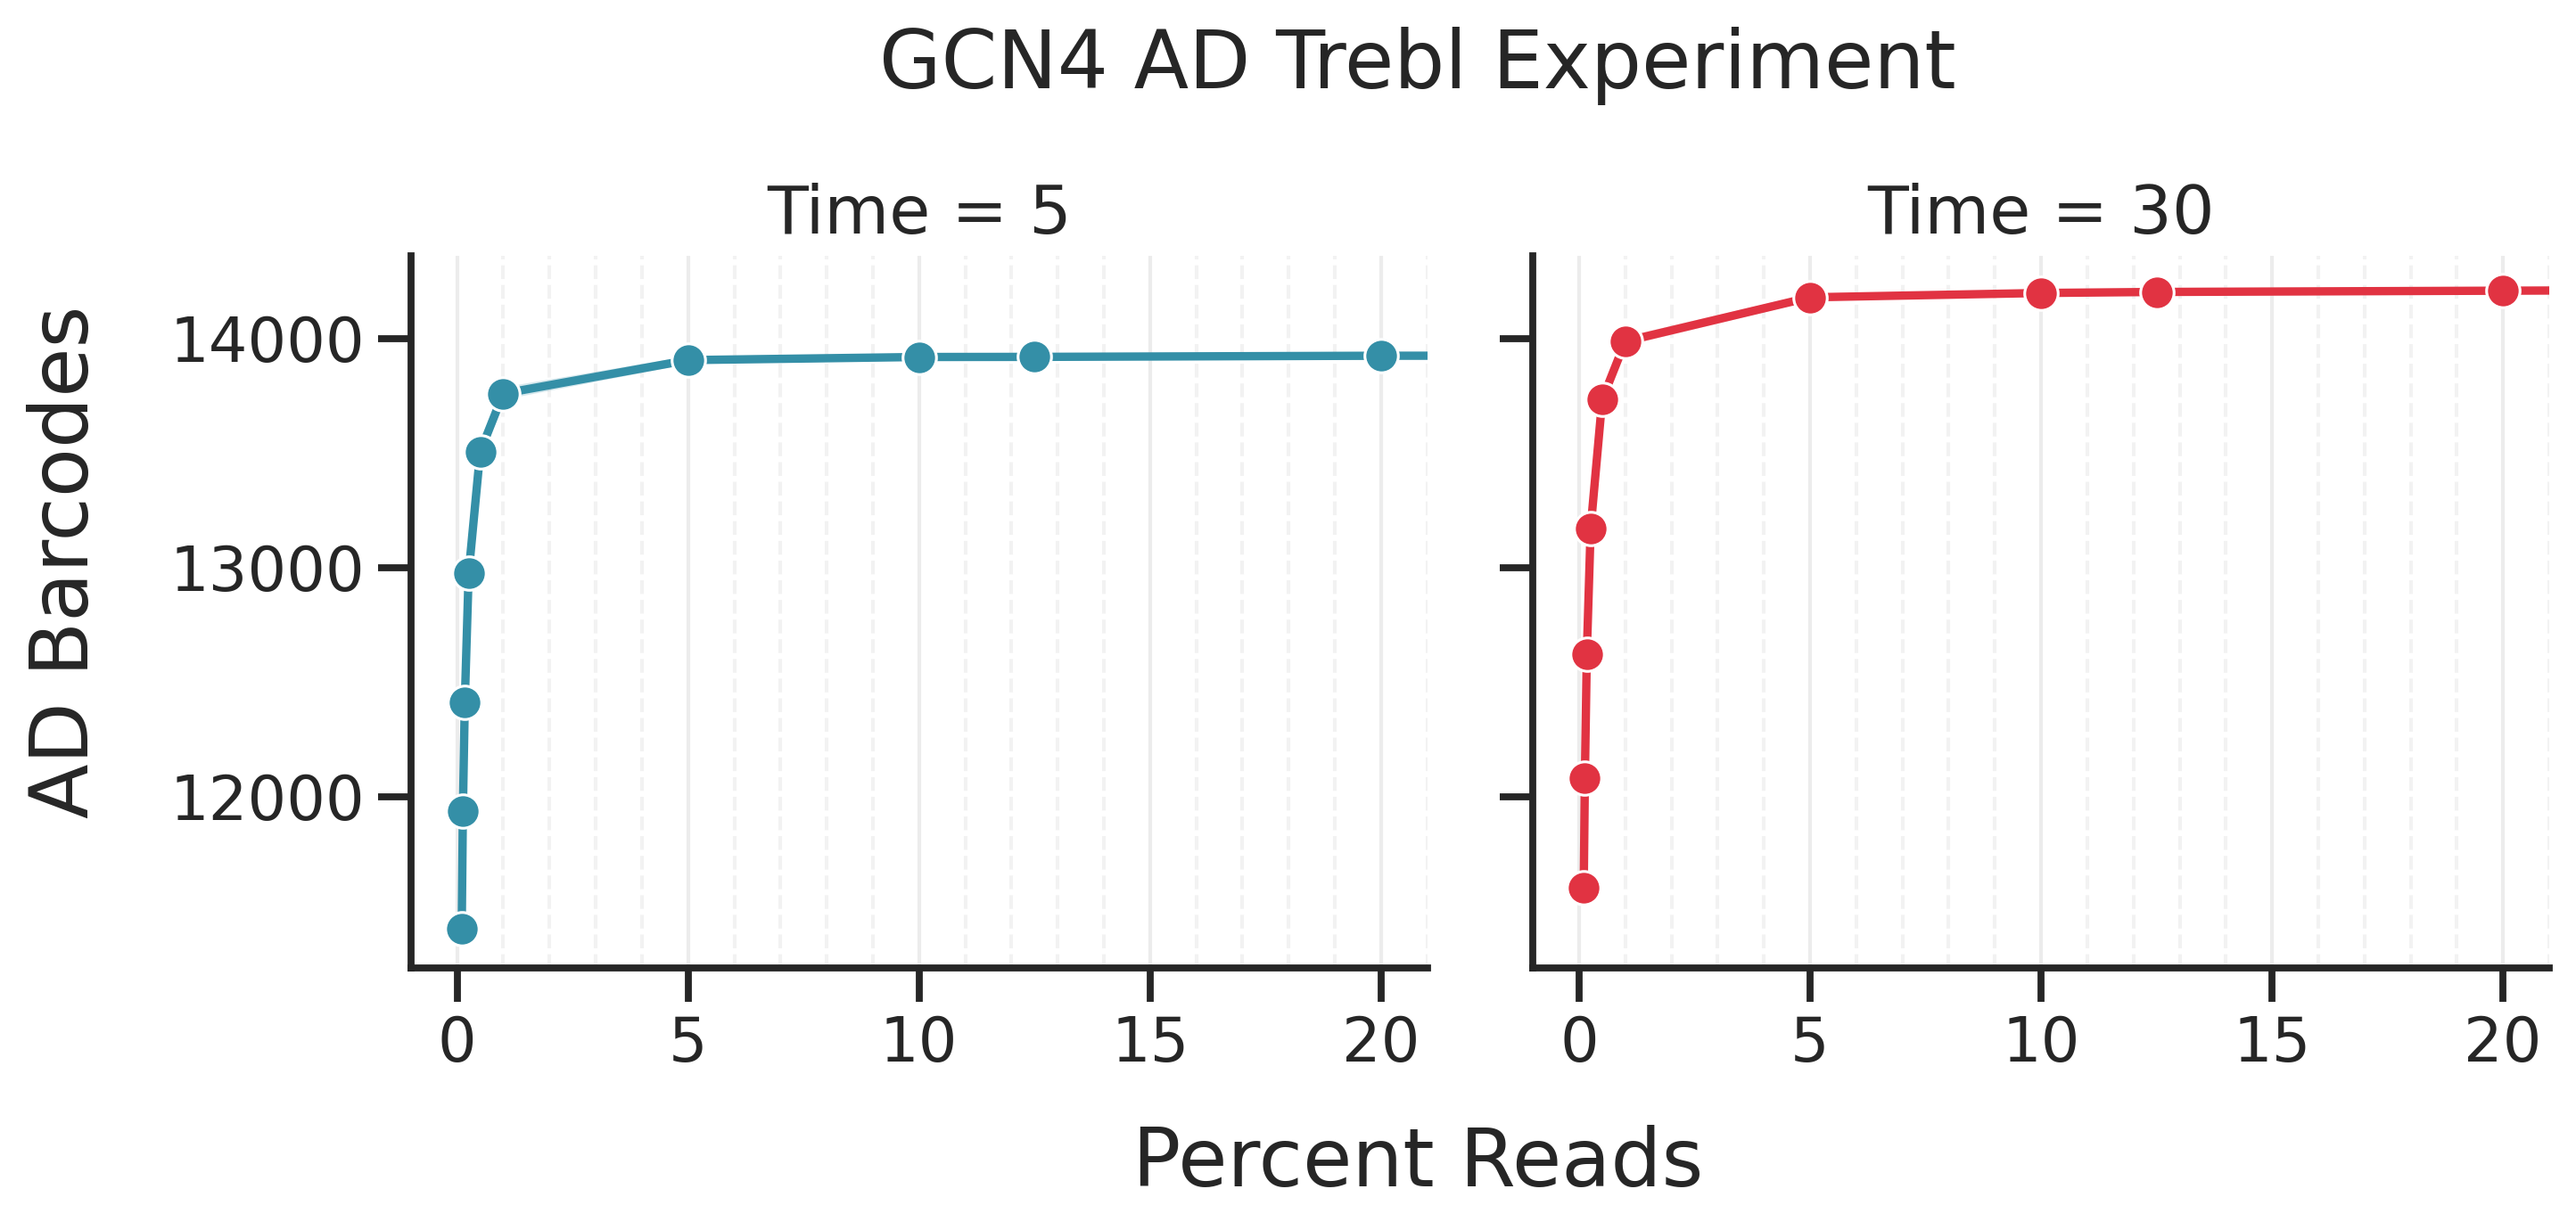

In [17]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_ad_color
)
ax.set_title("Time = 5")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_ad_color
)
ax.set_title("Time = 30")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("AD Barcodes", x=0.03, y=0.55)
fig.suptitle("GCN4 AD Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

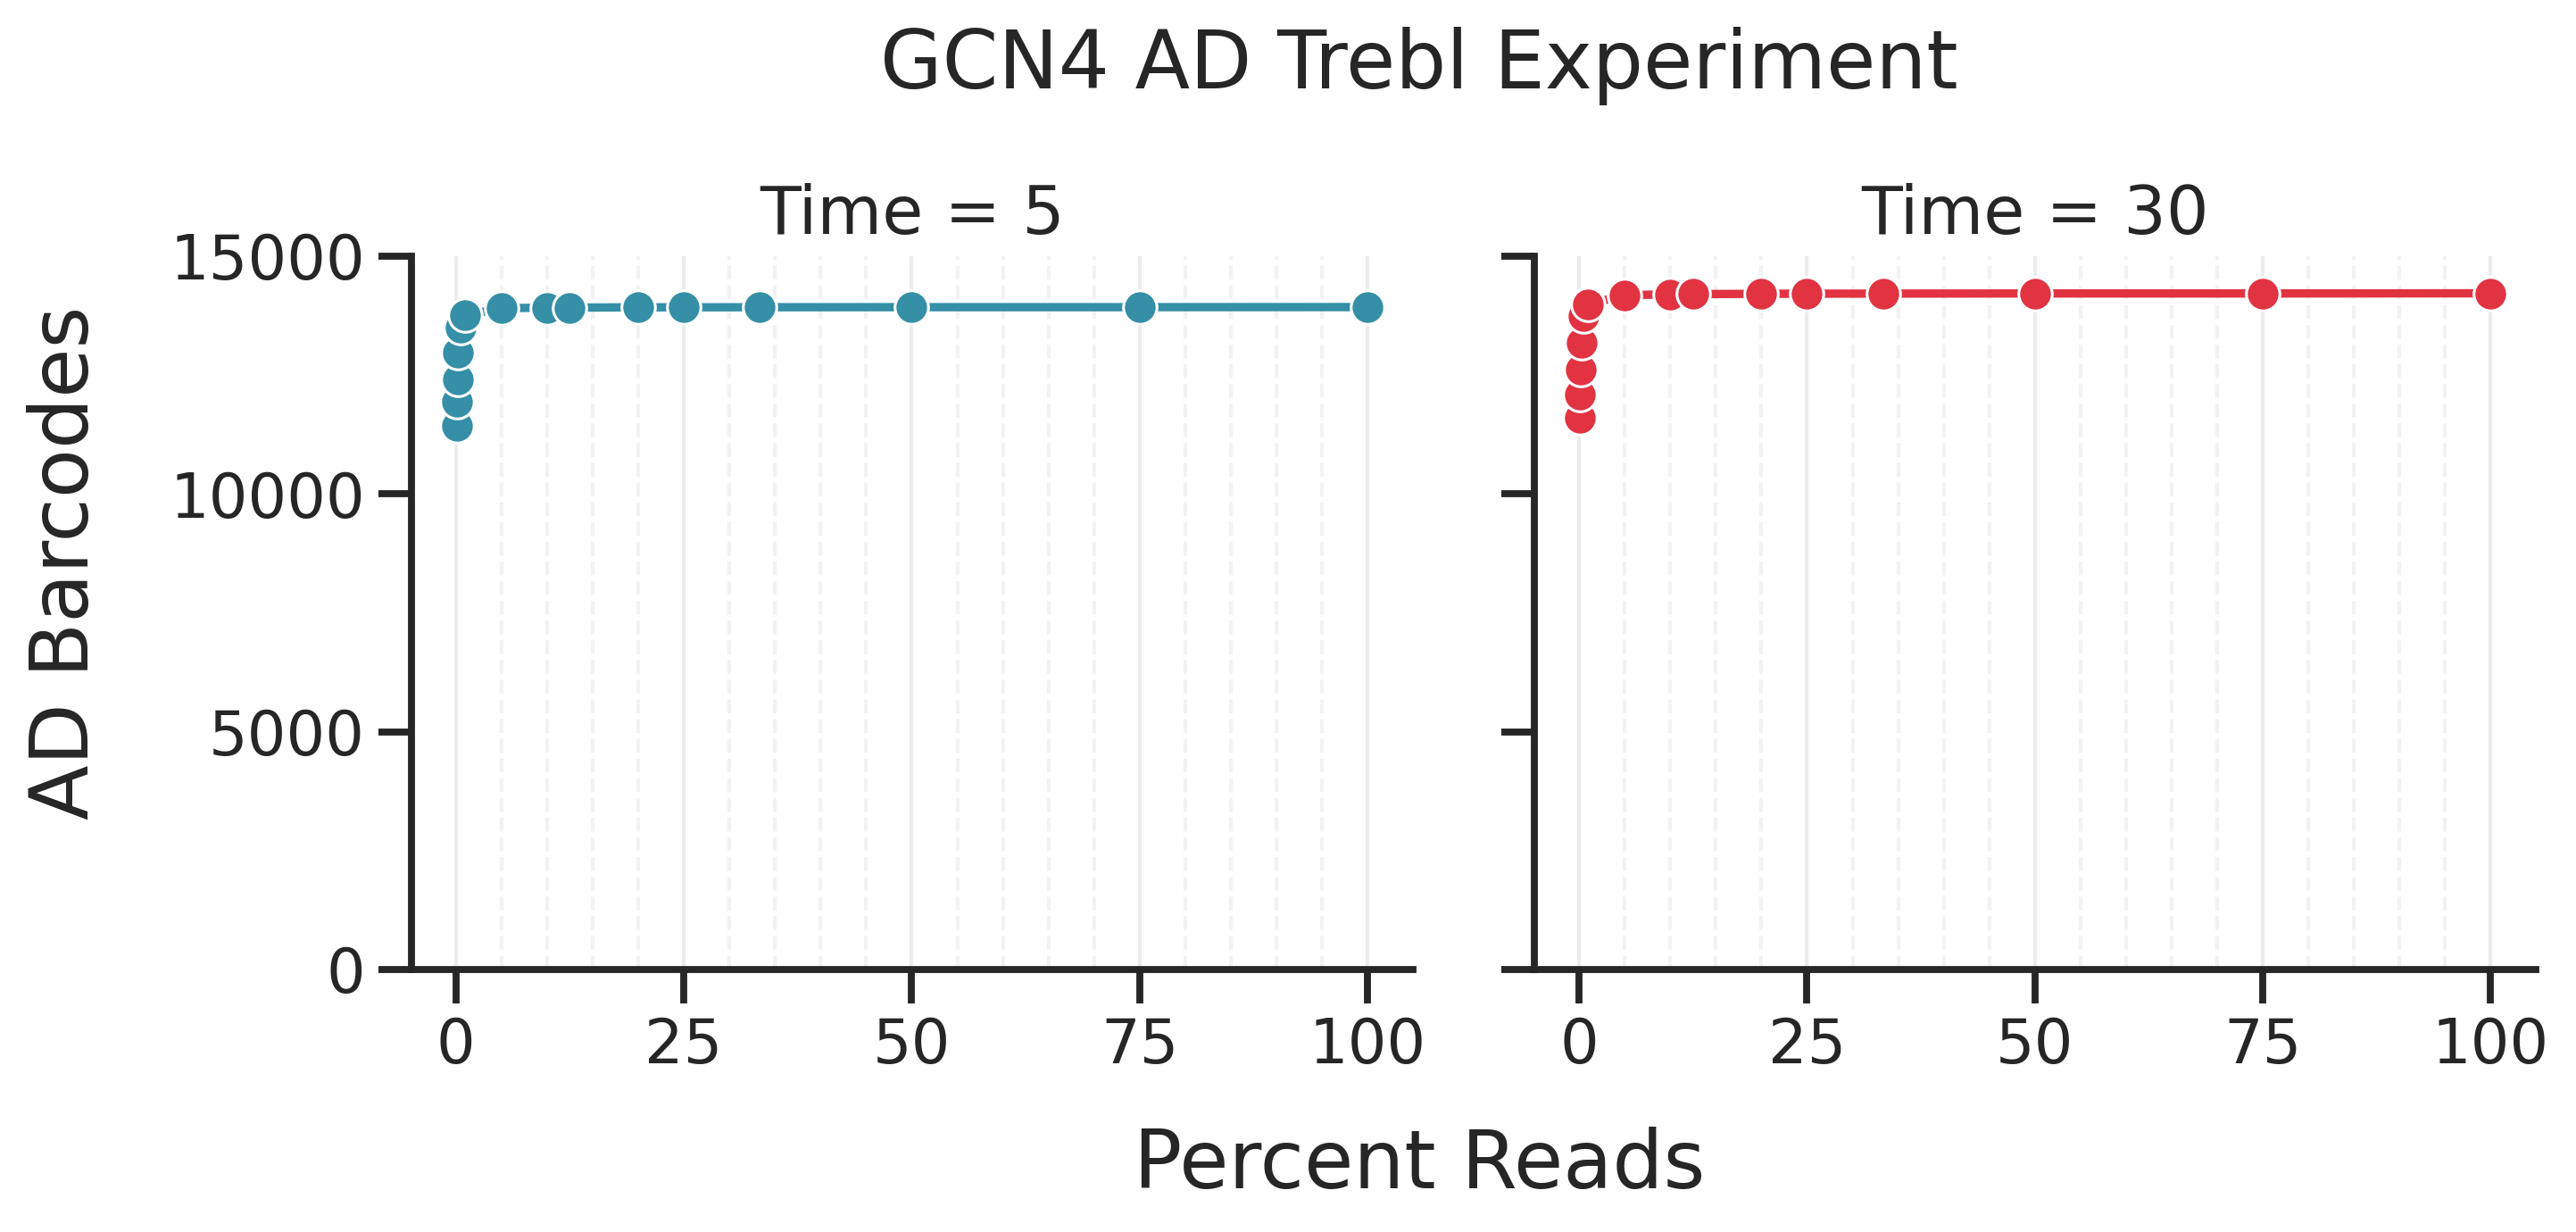

In [18]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_ad_color
)
ax.set_title("Time = 5")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_ad_color
)
ax.set_title("Time = 30")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_ylim(0,15000)

# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("AD Barcodes", x=0.03, y=0.55)
fig.suptitle("GCN4 AD Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

### All together

In [21]:
ad_time_5_summary.iloc[5:]

num_splits      percent_reads               time   unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1          mean   
5                 5.0          20.000000                  5  4.858768e+06   
6                 8.0          12.500000                  5  4.227410e+06   
7                10.0          10.000000                  5  3.888933e+06   
8                20.0           5.000000                  5  2.762910e+06   
9               100.0           1.000000                  5  8.251386e+05   
10              200.0           0.500000                  5  4.401068e+05   
11              400.0           0.250000                  5  2.155867e+05   
12              600.0           0.166667                  5  1.538301e+05   
13              800.0           0.125000                  5  1.161420e+05   
14             1000.0           0.100000                  5  9.348475e+04   

                  
             std  
5    2047.673485  
6     726.406407  
7    1365.650744  
8     984.987304  
9     639.995547  
10    339.989265  
11  30240.944123  
12    226.295845  
13    117.728501  
14     82.637260

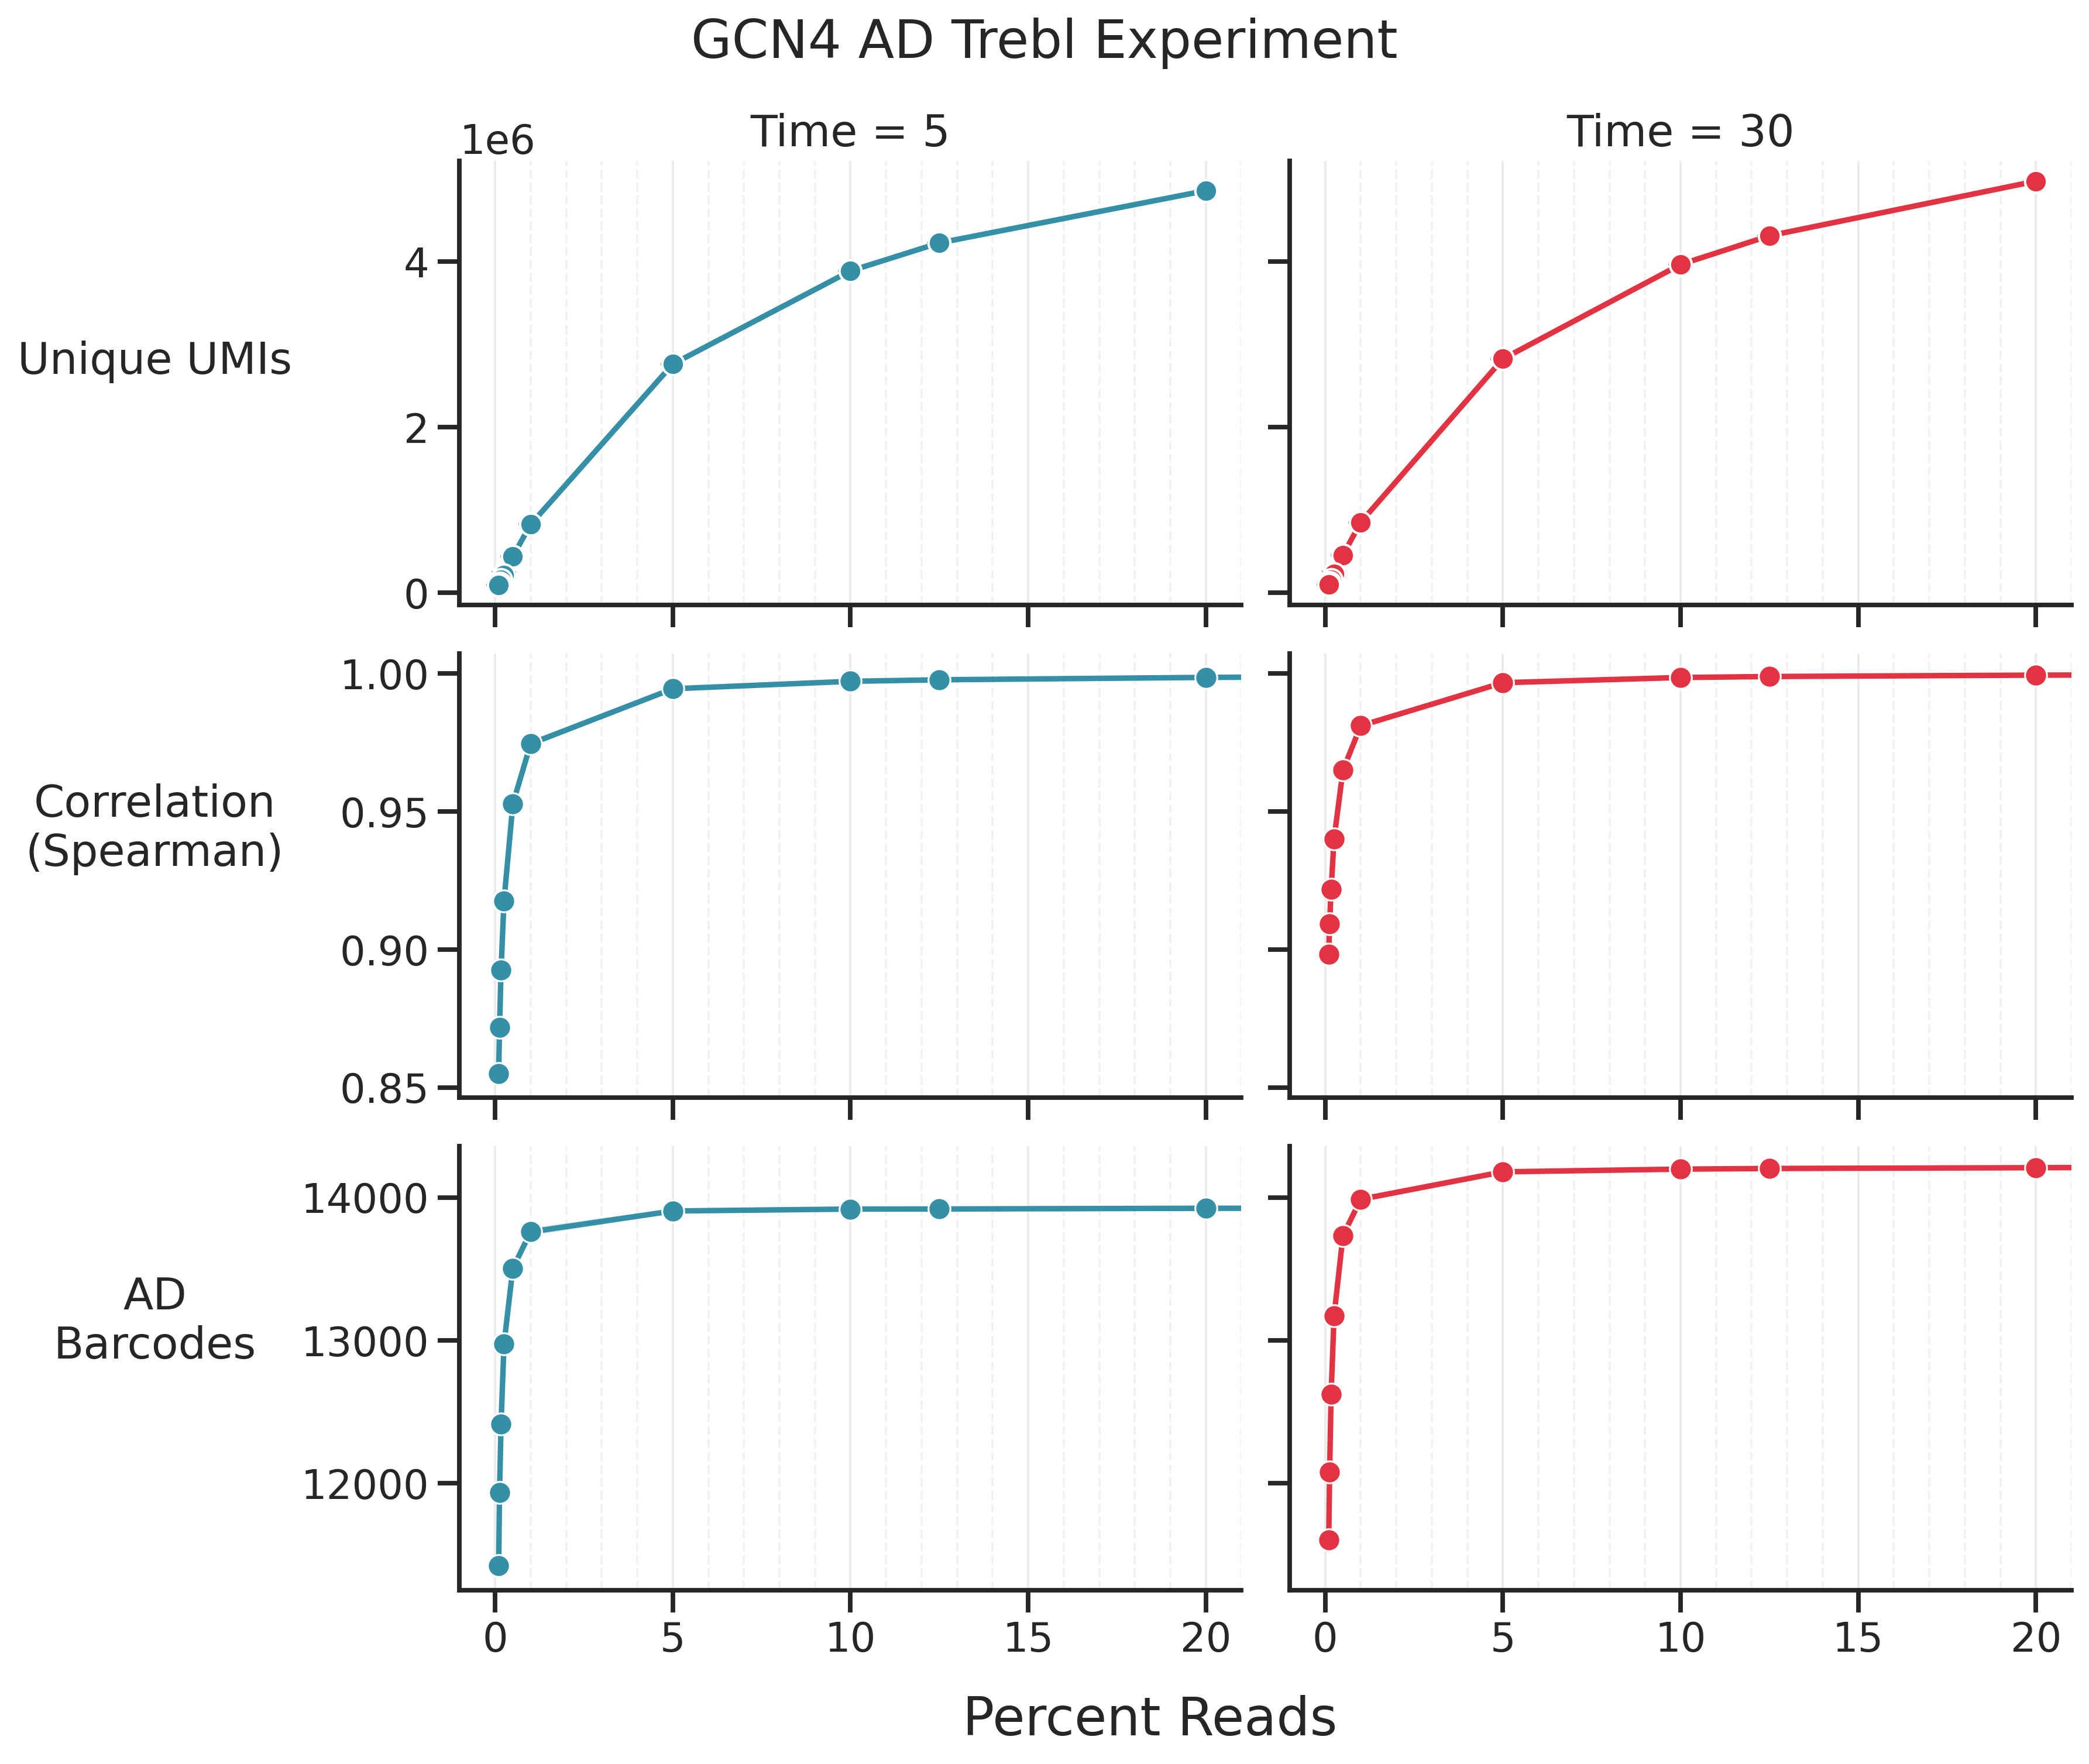

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 10),
    dpi=300,
    sharex=True,
    sharey = 'row'
)

# =========================
# Row 1 — Unique UMIs
# =========================

# ---- Time 5 ----
ax = axes[0, 0]
ax.errorbar(
    x=ad_time_5_summary.iloc[5:]['percent_reads'],
    y=ad_time_5_summary.iloc[5:][('unique_umis', 'mean')],
    yerr=ad_time_5_summary.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t5_ad_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 5")
ax.set_ylabel("Unique UMIs", rotation = 0, labelpad=60)
sns.despine(ax=ax)

# ---- Time 30 ----
ax = axes[0, 1]
ax.errorbar(
    x=ad_time_30_summary.iloc[5:]['percent_reads'],
    y=ad_time_30_summary.iloc[5:][('unique_umis', 'mean')],
    yerr=ad_time_30_summary.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t30_ad_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'

)
ax.set_title("Time = 30")
sns.despine(ax=ax)


# =========================
# Row 2 — Spearman correlation
# =========================

sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 0],
    color=t5_ad_color
)
axes[1, 0].set_ylabel("Correlation\n(Spearman)", rotation = 0, labelpad=60)
sns.despine(ax=axes[1, 0])

sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 1],
    color=t30_ad_color
)
sns.despine(ax=axes[1, 1])


# =========================
# Row 3 — Reporter barcodes
# =========================

sns.lineplot(
    data=ad_correlation_df_5,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 0],
    color=t5_ad_color
)
axes[2, 0].set_ylabel("AD\nBarcodes", rotation = 0, labelpad=60)
sns.despine(ax=axes[2, 0])

sns.lineplot(
    data=ad_correlation_df_30,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 1],
    color=t30_ad_color
)
sns.despine(ax=axes[2, 1])
axes[2, 1].set_ylabel("")


# =========================
# Shared formatting
# =========================

for ax in axes.flatten():
    ax.set_xlim(-1, 21)

    # Major vertical grid
    ax.grid(True, which='major', axis='x',
            linestyle='-', color='gray', alpha=0.15, linewidth=1)

    # Minor vertical grid every 1%
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(True, which='minor', axis='x',
            linestyle='--', color='gray', alpha=0.1, linewidth=1)

    # Hide minor tick marks (keep grid)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_xlabel("")

# Global labels
fig.supxlabel("Percent Reads",x = 0.55)
fig.suptitle("GCN4 AD Trebl Experiment", y=0.995)
fig.align_ylabels()

plt.tight_layout(pad=0.6)
plt.show()

### Reads per UMI

#### T = 5

In [52]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

dfs = []

folder = Path("../../output/GCN4/downsampling/")
chunk_files_t5 = sorted(folder.glob("*AD_1_5*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))

# Appending the last
chunk_files_t5.append("../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_1_5/AD_1_5_reads_per_umi.tsv")

for path in chunk_files_t5:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        downsample_pct = np.round(100 / num_chunks, 3)
    except:
        num_chunks = 1
        downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_10_chunks_part_1/AD_1_5_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_20_chunks_part_1/AD_1_5_20_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_2_chunks_part_1/AD_1_5_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_3_chunks_part_1/AD_1_5_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_4_chunks_part_1/AD_1_5_4_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_5_chunks_part_1/AD_1_5_5_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_8_chunks_part_1/AD_1_5_8_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_5_

,reads,downsample,downsample_val
2839352,1,100.0%,100.0
2839353,1,100.0%,100.0
2839354,1,100.0%,100.0
2839355,1,100.0%,100.0
2839356,1,100.0%,100.0
...,...,...,...
1400004,2,0.1%,0.1
1400005,2,0.1%,0.1
1400006,2,0.1%,0.1
1400007,2,0.1%,0.1


<Axes: xlabel='reads', ylabel='Count'>

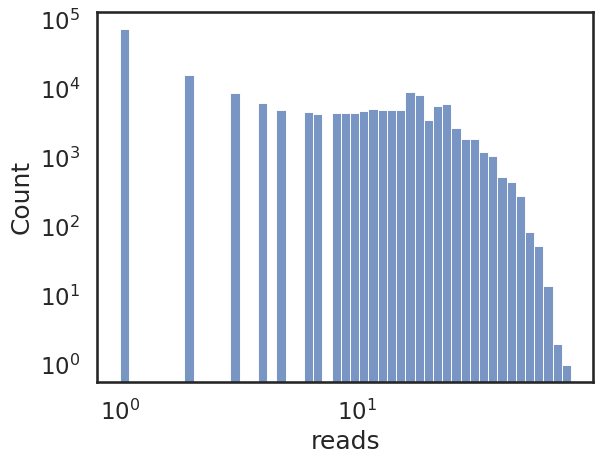

In [53]:
sns.histplot(all_df[all_df["downsample_val"] == 100]["reads"], log_scale = (True, True))

In [54]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      186559
0.125      140256
0.100      112545
Name: count, dtype: int64

In [55]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
2839352,1,100.0%,100.0,0.00000
2839353,1,100.0%,100.0,0.00000
2839354,1,100.0%,100.0,0.00000
2839355,1,100.0%,100.0,0.00000
2839356,1,100.0%,100.0,0.00000
...,...,...,...,...
1400004,2,0.1%,0.1,0.30103
1400005,2,0.1%,0.1,0.30103
1400006,2,0.1%,0.1,0.30103
1400007,2,0.1%,0.1,0.30103


In [59]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 33.333, 20, 10, 5,2, 1, 0.5])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
2839352,1,100.0%,100.0,0.0
2839353,1,100.0%,100.0,0.0
2839354,1,100.0%,100.0,0.0
2839355,1,100.0%,100.0,0.0
2839356,1,100.0%,100.0,0.0
...,...,...,...,...
1912540,1,0.5%,0.5,0.0
1912541,1,0.5%,0.5,0.0
1912542,1,0.5%,0.5,0.0
1912543,1,0.5%,0.5,0.0


In [60]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      186559
0.125      140256
0.100      112545
Name: count, dtype: int64

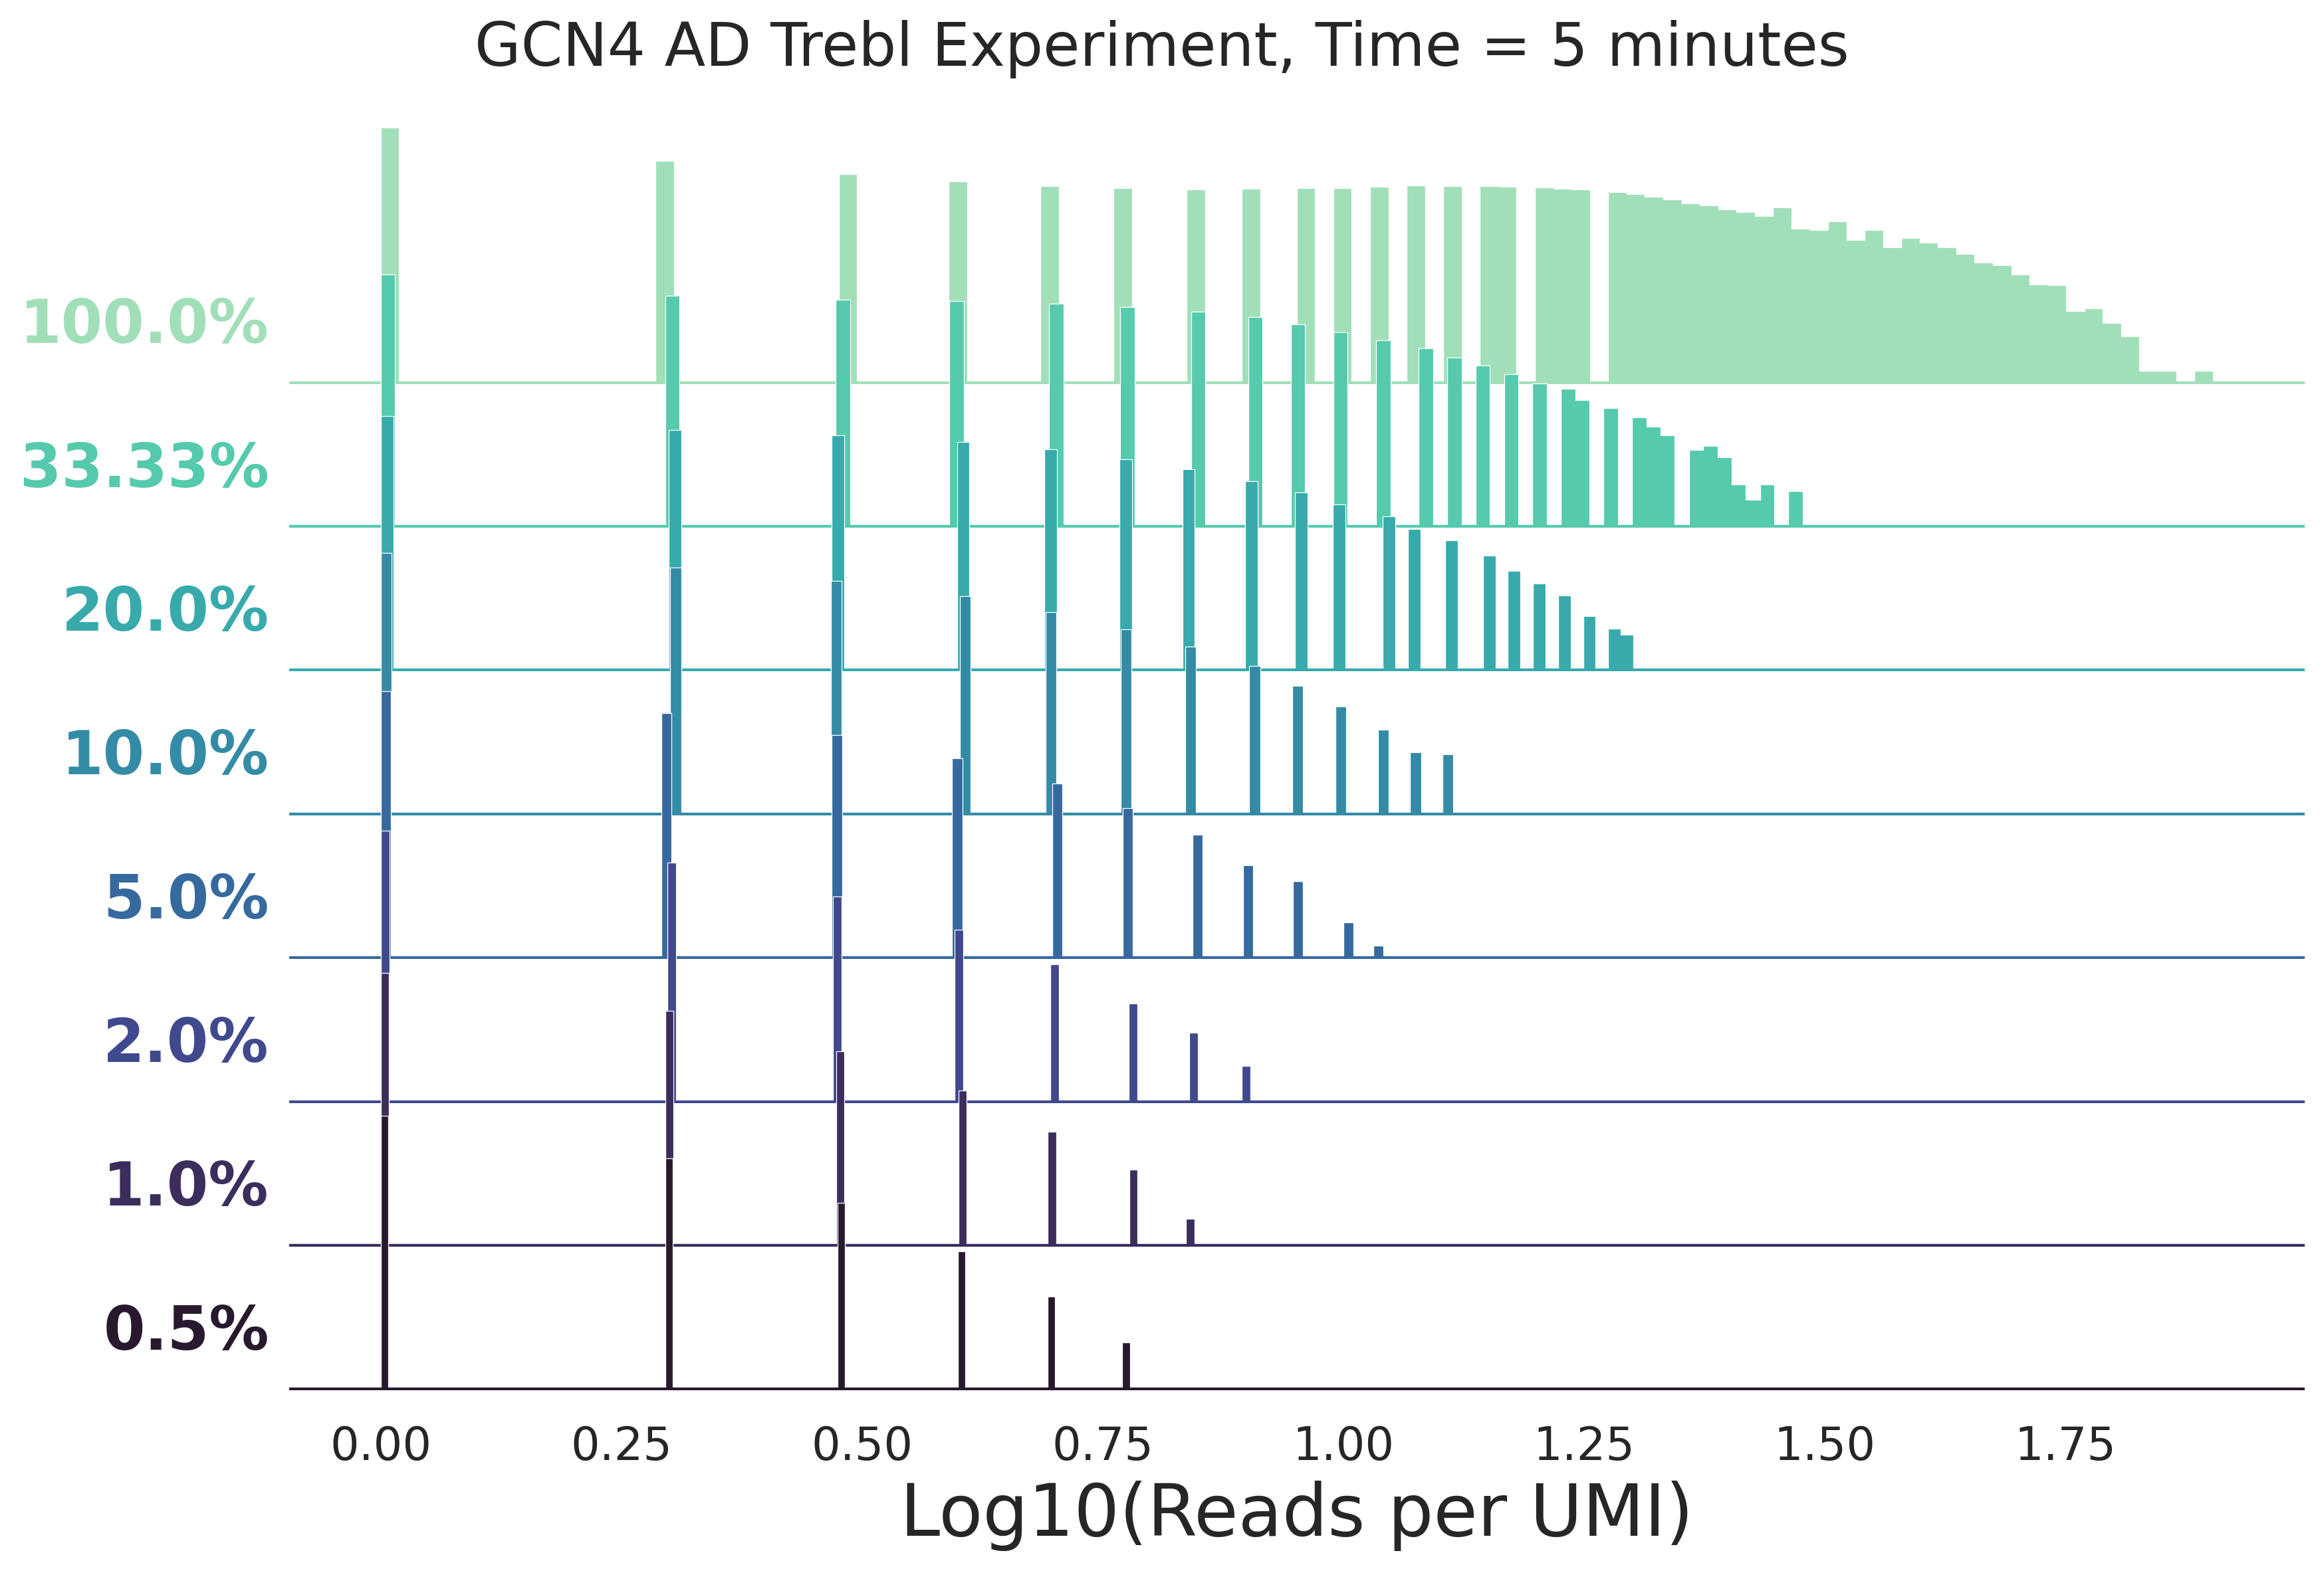

In [67]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=True)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=12,
    height=1,
    palette='mako_r',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='white',
        color=color,
        linewidth = 0.3,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=-0.5)
sns.despine(bottom = True, left=True)


g.fig.suptitle("GCN4 AD Trebl Experiment, Time = 5 minutes")
plt.show()

#### t = 30 minutes

In [25]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

dfs = []

folder = Path("../../output/GCN4/downsampling/")
chunk_files_t5 = sorted(folder.glob("*AD_1_30*chunks_part_1/*_part_1.fq_reads_per_umi.tsv"))

# Appending the last
chunk_files_t5.append("../../output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_30/AD_1_30_reads_per_umi.tsv")

for path in chunk_files_t5:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        downsample_pct = np.round(100 / num_chunks, 3)
    except:
        num_chunks = 1
        downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_10_chunks_part_1/AD_1_30_10_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_20_chunks_part_1/AD_1_30_20_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_2_chunks_part_1/AD_1_30_2_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_3_chunks_part_1/AD_1_30_3_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_4_chunks_part_1/AD_1_30_4_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_5_chunks_part_1/AD_1_30_5_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_8_chunks_part_1/AD_1_30_8_chunks_part_1.fq_reads_per_umi.tsv
../../output/GCN4/downsampling/trebl_experiment_yeast_pool

,reads,downsample,downsample_val
2796004,38,100.0%,100.0
2796005,38,100.0%,100.0
2796006,38,100.0%,100.0
2795991,42,100.0%,100.0
2796008,38,100.0%,100.0
...,...,...,...
1400009,1,0.1%,0.1
1400010,1,0.1%,0.1
1400011,1,0.1%,0.1
1400012,1,0.1%,0.1


In [26]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      167374
0.125      126555
0.100      102118
Name: count, dtype: int64

In [27]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
2796004,38,100.0%,100.0,1.579784
2796005,38,100.0%,100.0,1.579784
2796006,38,100.0%,100.0,1.579784
2795991,42,100.0%,100.0,1.623249
2796008,38,100.0%,100.0,1.579784
...,...,...,...,...
1400009,1,0.1%,0.1,0.000000
1400010,1,0.1%,0.1,0.000000
1400011,1,0.1%,0.1,0.000000
1400012,1,0.1%,0.1,0.000000


In [28]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 50, 33.333, 20, 10, 5,2, 1, 0.5])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
2796004,38,100.0%,100.0,1.579784
2796005,38,100.0%,100.0,1.579784
2796006,38,100.0%,100.0,1.579784
2795991,42,100.0%,100.0,1.623249
2796008,38,100.0%,100.0,1.579784
...,...,...,...,...
1799941,1,0.5%,0.5,0.000000
1799942,1,0.5%,0.5,0.000000
1799934,1,0.5%,0.5,0.000000
1799992,1,0.5%,0.5,0.000000


In [29]:
all_df["downsample_val"].value_counts()

downsample_val
100.000    200000
50.000     200000
33.333     200000
25.000     200000
20.000     200000
12.500     200000
10.000     200000
5.000      200000
2.000      200000
1.000      200000
0.500      200000
0.250      200000
0.167      167374
0.125      126555
0.100      102118
Name: count, dtype: int64

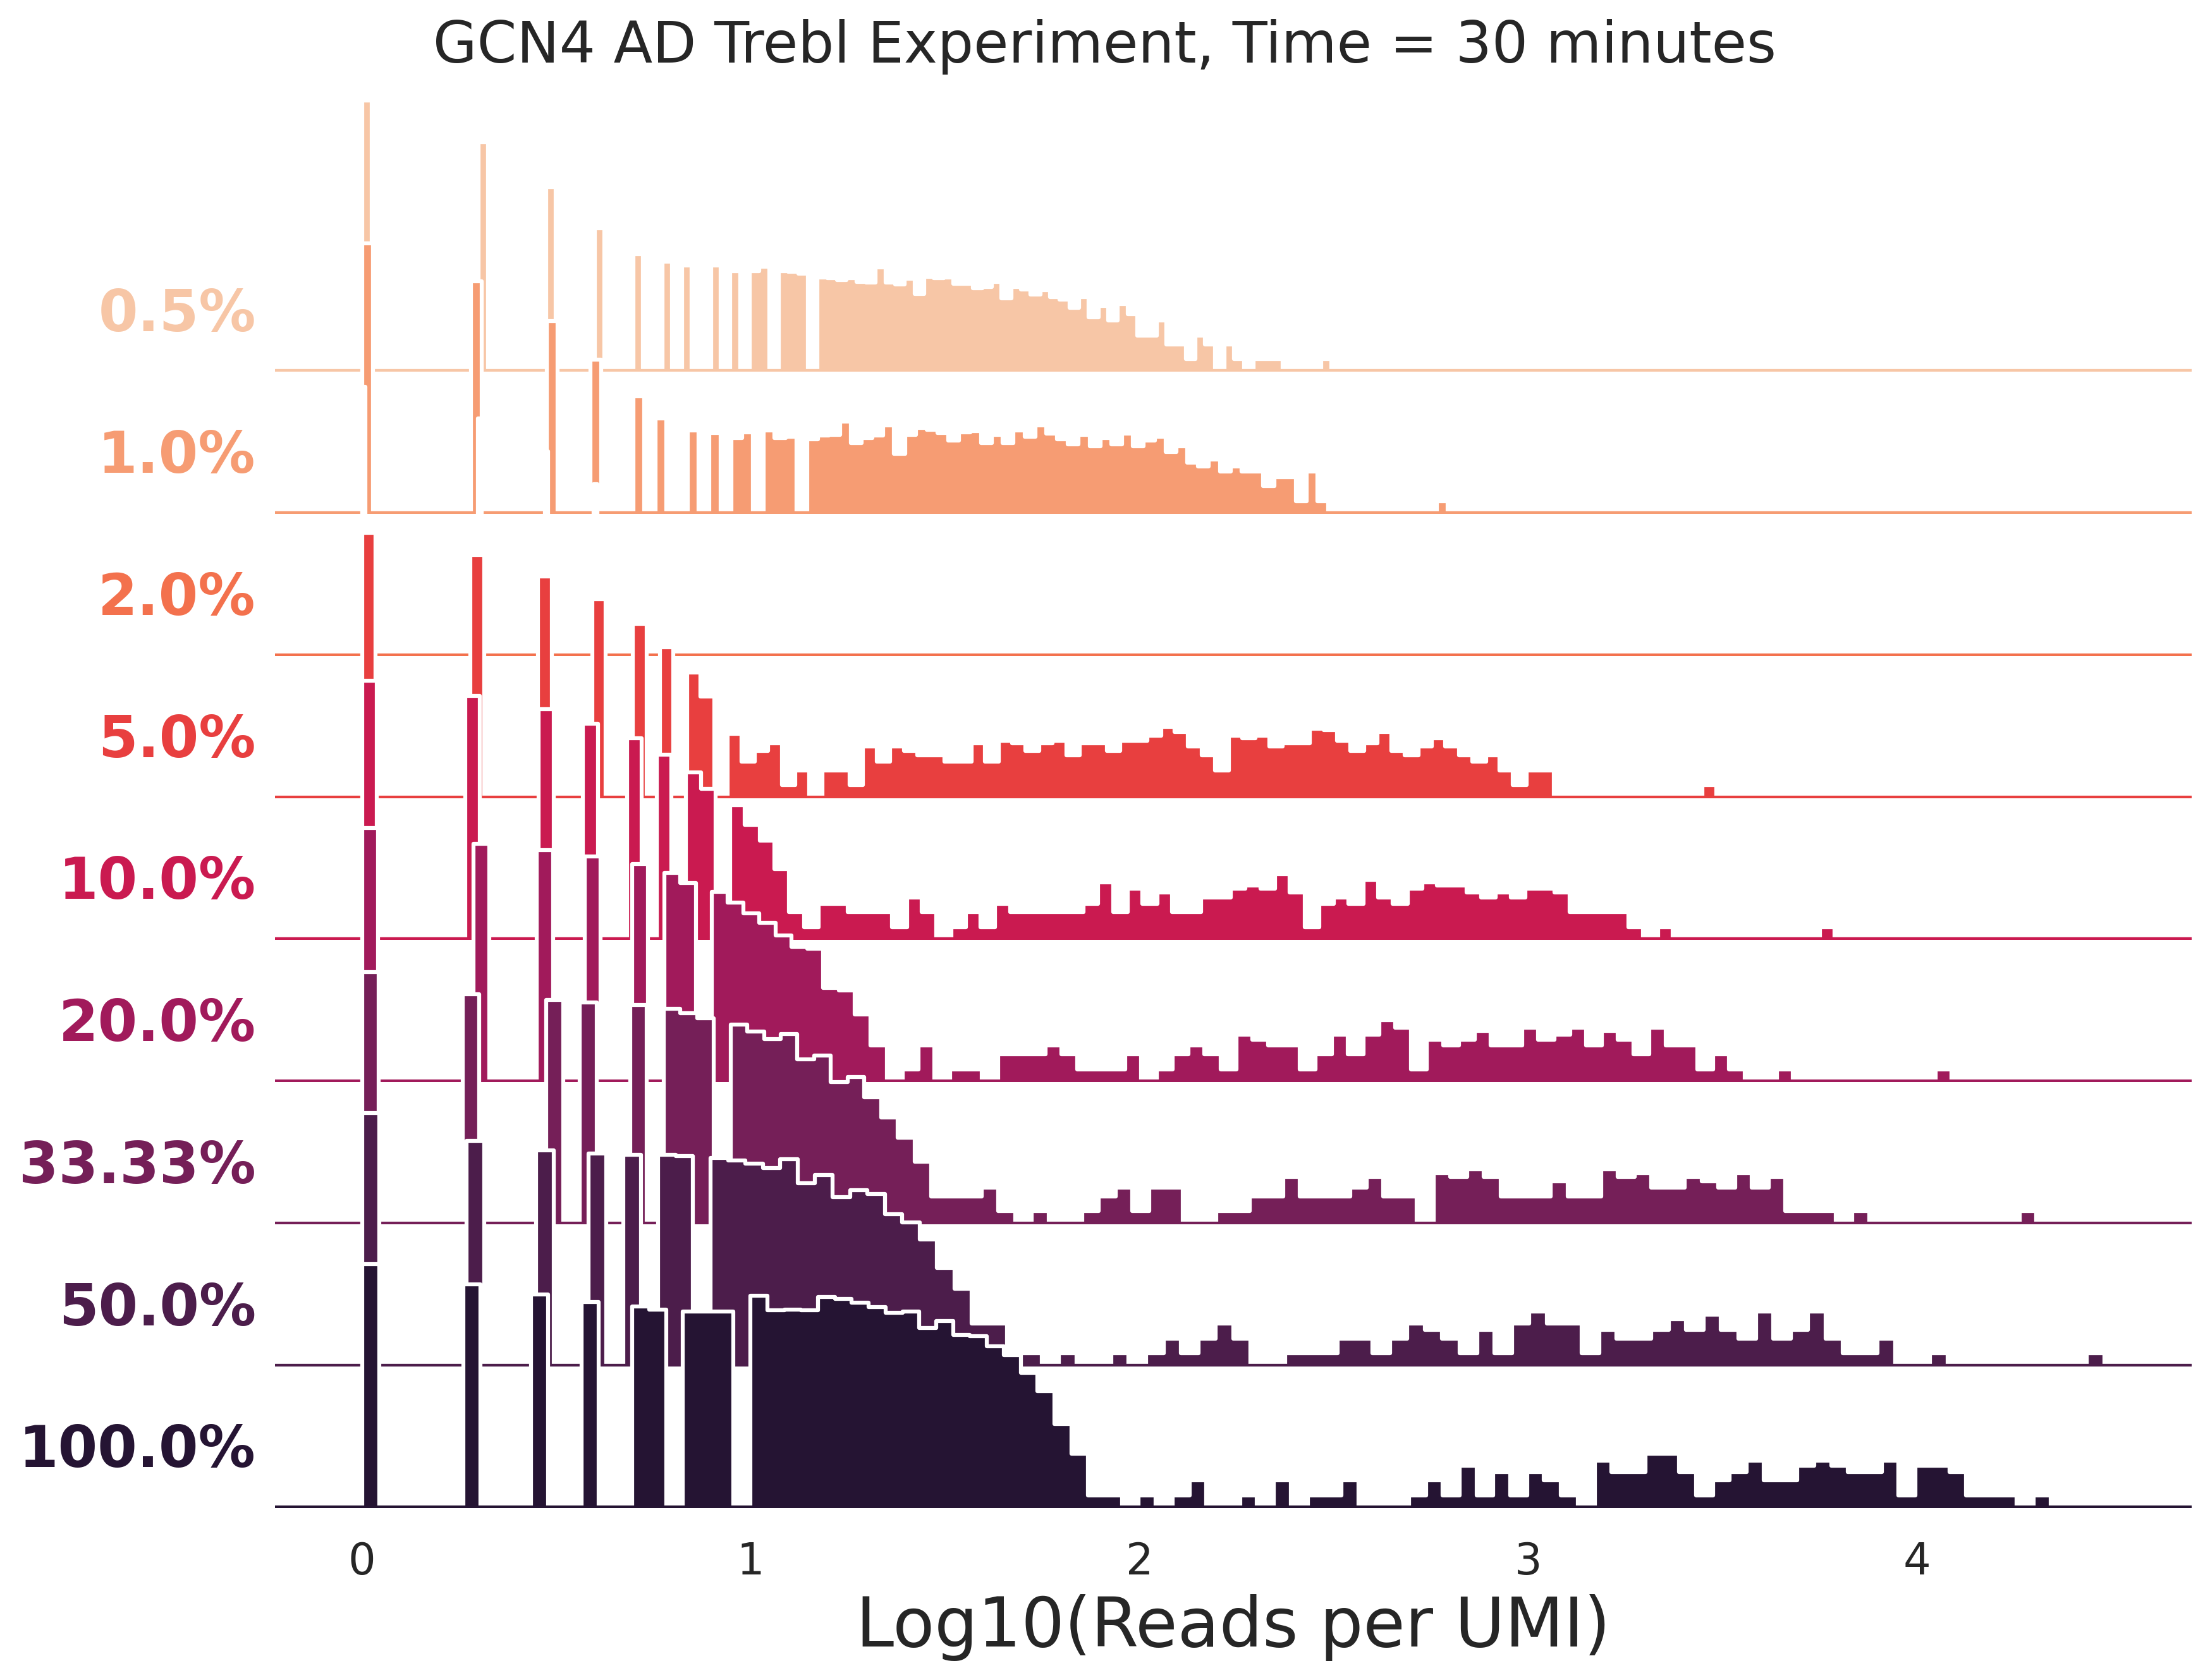

In [30]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=True)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=12,
    height=1,
    palette='rocket_r',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='white',
        color=color,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=-0.5)
sns.despine(bottom = True, left=True)


g.fig.suptitle("GCN4 AD Trebl Experiment, Time = 30 minutes")
plt.show()

# NKX2-2

### Reading in data

In [5]:
ad_time_4_summary_nkx2 = pd.read_csv("../../output/nkx2-2_downsampling_t4_summary.csv", index_col=0, header=[0,1])
ad_time_4_summary_nkx2

num_splits      percent_reads               time    unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1           mean   
0            1.000000                100                  4  493965.000000   
1            1.333333                 75                  4  456597.500000   
2            2.000000                 50                  4  401742.000000   
3            3.000000                 33                  4  341237.666667   
4            4.000000                 25                  4  296525.250000   
5            5.000000                 20                  4  261717.400000   
6            8.000000                 12                  4  192644.200000   
7           10.000000                 10                  4  163854.666667   
8           20.000000                  5                  4   93214.600000   
9           50.000000                  2                  4   40606.800000   
10         100.000000                  1                  4   20895.200000   
11         200.000000                  0                  4   10649.800000   
12         400.000000                  0                  4    5358.200000   
13         600.000000                  0                  4    3601.800000   
14         800.000000                  0                  4    2734.000000   
15        1000.000000                  0                  4    2223.800000   

                
           std  
0          NaN  
1   327.390440  
2   179.605122  
3   100.729009  
4   234.894835  
5   176.186833  
6   173.951717  
7   115.319845  
8   105.516823  
9   151.212433  
10   65.373542  
11   41.008536  
12   26.300190  
13   25.528416  
14   29.214722  
15   13.935566

In [6]:
ad_time_24_summary_nkx2 = pd.read_csv("../../output/nkx2-2_downsampling_t24_summary.csv", index_col=0, header=[0,1])
ad_time_24_summary_nkx2

num_splits      percent_reads               time unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1        mean   
0            1.000000                100                 24  2287912.00   
1            1.333333                 75                 24  2132797.50   
2            2.000000                 50                 24  1920772.50   
3            3.000000                 33                 24  1693688.00   
4            4.000000                 25                 24  1518651.00   
5            5.000000                 20                 24  1375312.60   
6            8.000000                 12                 24  1068587.00   
7           10.000000                 10                 24   928860.00   
8           20.000000                  5                 24   558901.80   
9           50.000000                  2                 24   253554.80   
10         100.000000                  1                 24   132689.60   
11         200.000000                  0                 24    68007.80   
12         400.000000                  0                 24    34459.25   
13         600.000000                  0                 24    23095.20   
14         800.000000                  0                 24    17357.20   
15        1000.000000                  0                 24    13864.60   

                
           std  
0          NaN  
1   161.927453  
2   327.390440  
3   632.958134  
4   572.527146  
5   705.398327  
6   643.666451  
7   478.702935  
8   382.884708  
9   134.750510  
10  196.339757  
11   75.988157  
12   72.697432  
13   28.534190  
14   50.756280  
15   51.296199

In [7]:
t5_ad_color = sns.color_palette(t5_palette)[2]
t30_ad_color = sns.color_palette(t30_palette)[2]


In [8]:
sns.color_palette(t30_palette)

[(0.96516917, 0.70776351, 0.5606593),
 (0.95381595, 0.46373781, 0.31769923),
 (0.8833417, 0.19830556, 0.26014181),
 (0.67824099, 0.09192342, 0.3504148),
 (0.43860848, 0.12177004, 0.34119475),
 (0.20973515, 0.09747934, 0.24238489)]

In [9]:
sns.color_palette(t5_palette)

[(0.54578602, 0.8544913, 0.69848331),
 (0.25187832, 0.71827158, 0.67872193),
 (0.20344718, 0.56074869, 0.65649508),
 (0.21607792, 0.39736958, 0.61948028),
 (0.25307401, 0.23772973, 0.48316271),
 (0.18195582, 0.11955283, 0.23136943)]

### Reads vs unique UMIs

In [10]:
ad_time_4_summary_nkx2

num_splits      percent_reads               time    unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1           mean   
0            1.000000                100                  4  493965.000000   
1            1.333333                 75                  4  456597.500000   
2            2.000000                 50                  4  401742.000000   
3            3.000000                 33                  4  341237.666667   
4            4.000000                 25                  4  296525.250000   
5            5.000000                 20                  4  261717.400000   
6            8.000000                 12                  4  192644.200000   
7           10.000000                 10                  4  163854.666667   
8           20.000000                  5                  4   93214.600000   
9           50.000000                  2                  4   40606.800000   
10         100.000000                  1                  4   20895.200000   
11         200.000000                  0                  4   10649.800000   
12         400.000000                  0                  4    5358.200000   
13         600.000000                  0                  4    3601.800000   
14         800.000000                  0                  4    2734.000000   
15        1000.000000                  0                  4    2223.800000   

                
           std  
0          NaN  
1   327.390440  
2   179.605122  
3   100.729009  
4   234.894835  
5   176.186833  
6   173.951717  
7   115.319845  
8   105.516823  
9   151.212433  
10   65.373542  
11   41.008536  
12   26.300190  
13   25.528416  
14   29.214722  
15   13.935566

In [11]:
ad_time_4_summary_nkx2["percent_reads"] = 100 / ad_time_4_summary_nkx2[('num_splits', 'Unnamed: 1_level_1')]
ad_time_24_summary_nkx2["percent_reads"] = 100 / ad_time_24_summary_nkx2[('num_splits', 'Unnamed: 1_level_1')]

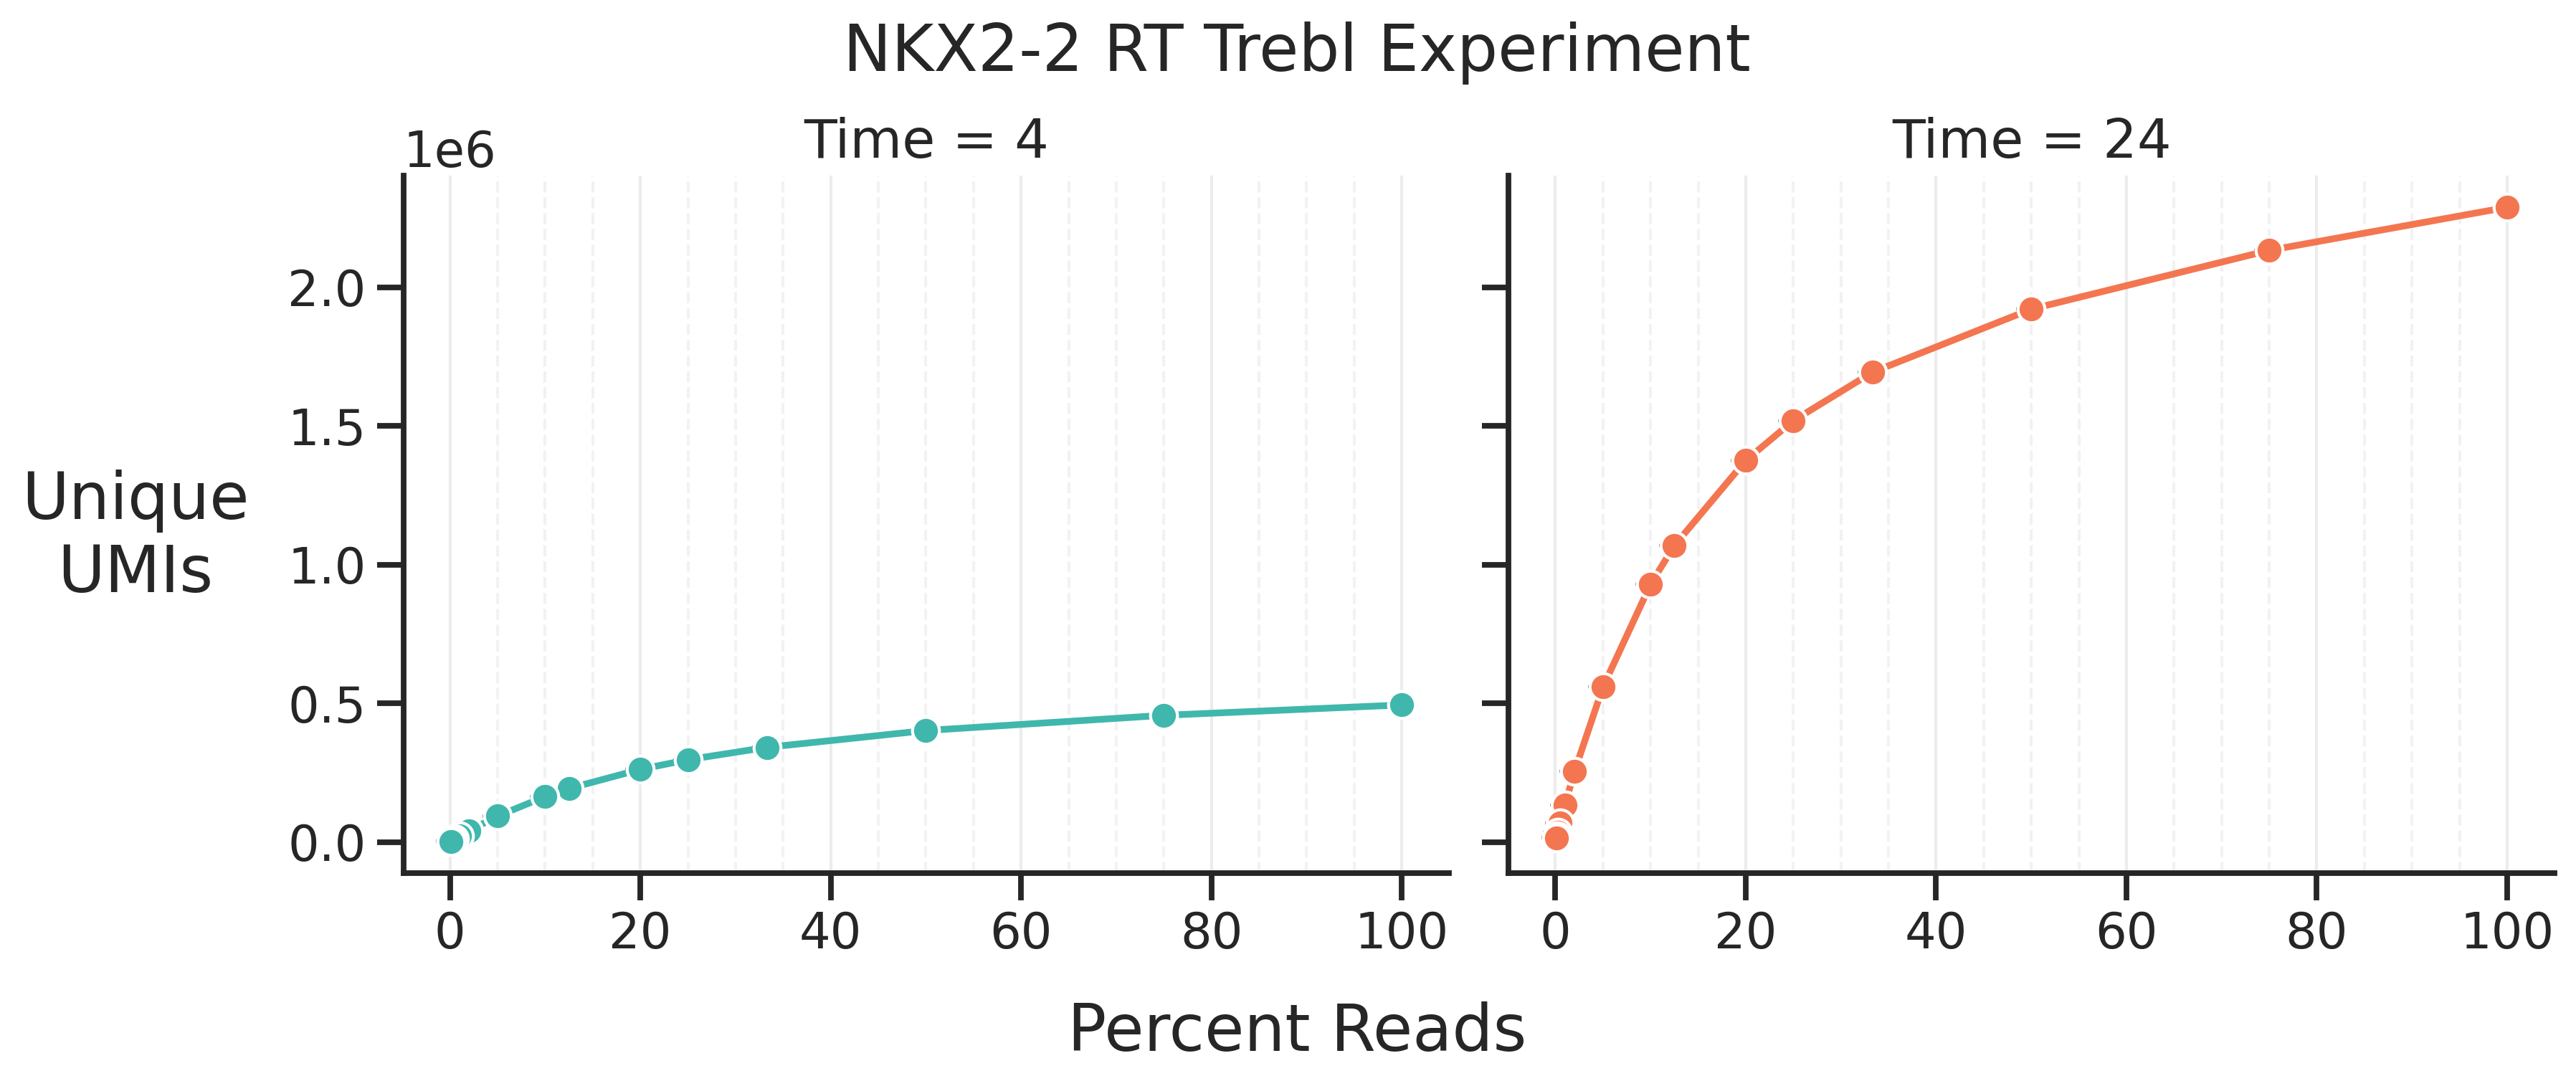

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Time 5 ----------
ax = axes[0]
x_5 = ad_time_4_summary_nkx2['percent_reads']
y_mean_5 = ad_time_4_summary_nkx2[('unique_umis', 'mean')]
y_std_5 = ad_time_4_summary_nkx2[('unique_umis', 'std')]

ax.errorbar(
    x=x_5,
    y=y_mean_5,
    yerr=y_std_5,
    fmt='-o',
    capsize=5,
    color=t5_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 4")
ax.set_xlabel("")
# ax.set_ylabel("Unique UMIs")
sns.despine(ax=ax)

# ---------- Time 30 ----------
ax = axes[1]
x_30 = ad_time_24_summary_nkx2['percent_reads']
y_mean_30 = ad_time_24_summary_nkx2[('unique_umis', 'mean')]
y_std_30 = ad_time_24_summary_nkx2[('unique_umis', 'std')]

ax.errorbar(
    x=x_30,
    y=y_mean_30,
    yerr=y_std_30,
    fmt='-o',
    capsize=5,
    color=t30_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 24")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine(ax=ax)

# --- Shared X limits and ticks ---
all_x = np.concatenate([x_5, x_30])
x_min, x_max = all_x.min(), all_x.max()
for ax in axes:
    #ax.set_xlim(x_min - 1e7, x_max + 1e7)
    #ax.set_ylim(0, max(y_mean_5.max(), y_mean_30.max()) * 1.05)

    # Major and minor vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth=1)
    ax.xaxis.set_minor_locator(MultipleLocator(5))  # minor tick every 50M reads
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth=1)
    ax.tick_params(axis='x', which='minor', length=0)

# Super labels and title
fig.supxlabel("Percent Reads")
fig.supylabel("Unique\nUMIs", rotation = 0, ha = 'center', x = 0.05)
fig.suptitle("NKX2-2 RT Trebl Experiment")

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs correlation

In [13]:
correlation_df_nkx2 = pd.read_csv("../../output/nkx2-2_rt_downsampling_correlation_results.csv")
correlation_df_nkx2#["percent_reads"].value_counts()

,Unnamed: 0,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
0,0,../../output/NKX2-2/downsampling/trebl_experim...,0.997921,0.892174,788,200.0,0.500000,24
1,1,../../output/NKX2-2/downsampling/trebl_experim...,0.998880,0.891296,754,50.0,2.000000,4
2,2,../../output/NKX2-2/downsampling/trebl_experim...,0.999894,0.978657,860,5.0,20.000000,4
3,3,../../output/NKX2-2/downsampling/trebl_experim...,0.999180,0.962348,858,20.0,5.000000,24
4,4,../../output/NKX2-2/downsampling/trebl_experim...,0.992452,0.840451,726,600.0,0.166667,24
...,...,...,...,...,...,...,...,...
123,123,../../output/NKX2-2/downsampling/trebl_experim...,0.997220,0.922768,818,100.0,1.000000,24
124,124,../../output/NKX2-2/downsampling/trebl_experim...,0.999814,0.983345,864,10.0,10.000000,24
125,125,../../output/NKX2-2/downsampling/trebl_experim...,0.999710,0.985831,863,8.0,12.500000,24
126,126,../../output/NKX2-2/downsampling/trebl_experim...,0.981263,0.866320,757,400.0,0.250000,24


In [14]:
# Filter data for time = 5 and time = 30
correlation_df_4_nkx2 = correlation_df_nkx2[correlation_df_nkx2["time"] == 4]
correlation_df_24_nkx2 = correlation_df_nkx2[correlation_df_nkx2["time"] == 24]
correlation_df_4_nkx2

,Unnamed: 0,folder_path,pearson_corr,spearman_corr,num_rows,num_splits,percent_reads,time
1,1,../../output/NKX2-2/downsampling/trebl_experim...,0.998880,0.891296,754,50.0,2.000000,4
2,2,../../output/NKX2-2/downsampling/trebl_experim...,0.999894,0.978657,860,5.0,20.000000,4
5,5,../../output/NKX2-2/downsampling/trebl_experim...,0.994110,0.679710,387,800.0,0.125000,4
6,6,../../output/NKX2-2/downsampling/trebl_experim...,0.999677,0.965103,845,10.0,10.000000,4
8,8,../../output/NKX2-2/downsampling/trebl_experim...,0.999072,0.939671,814,20.0,5.000000,4
...,...,...,...,...,...,...,...,...
116,116,../../output/NKX2-2/downsampling/trebl_experim...,0.998042,0.819337,602,200.0,0.500000,4
117,117,../../output/NKX2-2/downsampling/trebl_experim...,0.991298,0.809004,622,200.0,0.500000,4
118,118,../../output/NKX2-2/downsampling/trebl_experim...,0.999923,0.988988,863,3.0,33.333333,4
120,120,../../output/NKX2-2/downsampling/trebl_experim...,0.998745,0.705594,435,600.0,0.166667,4


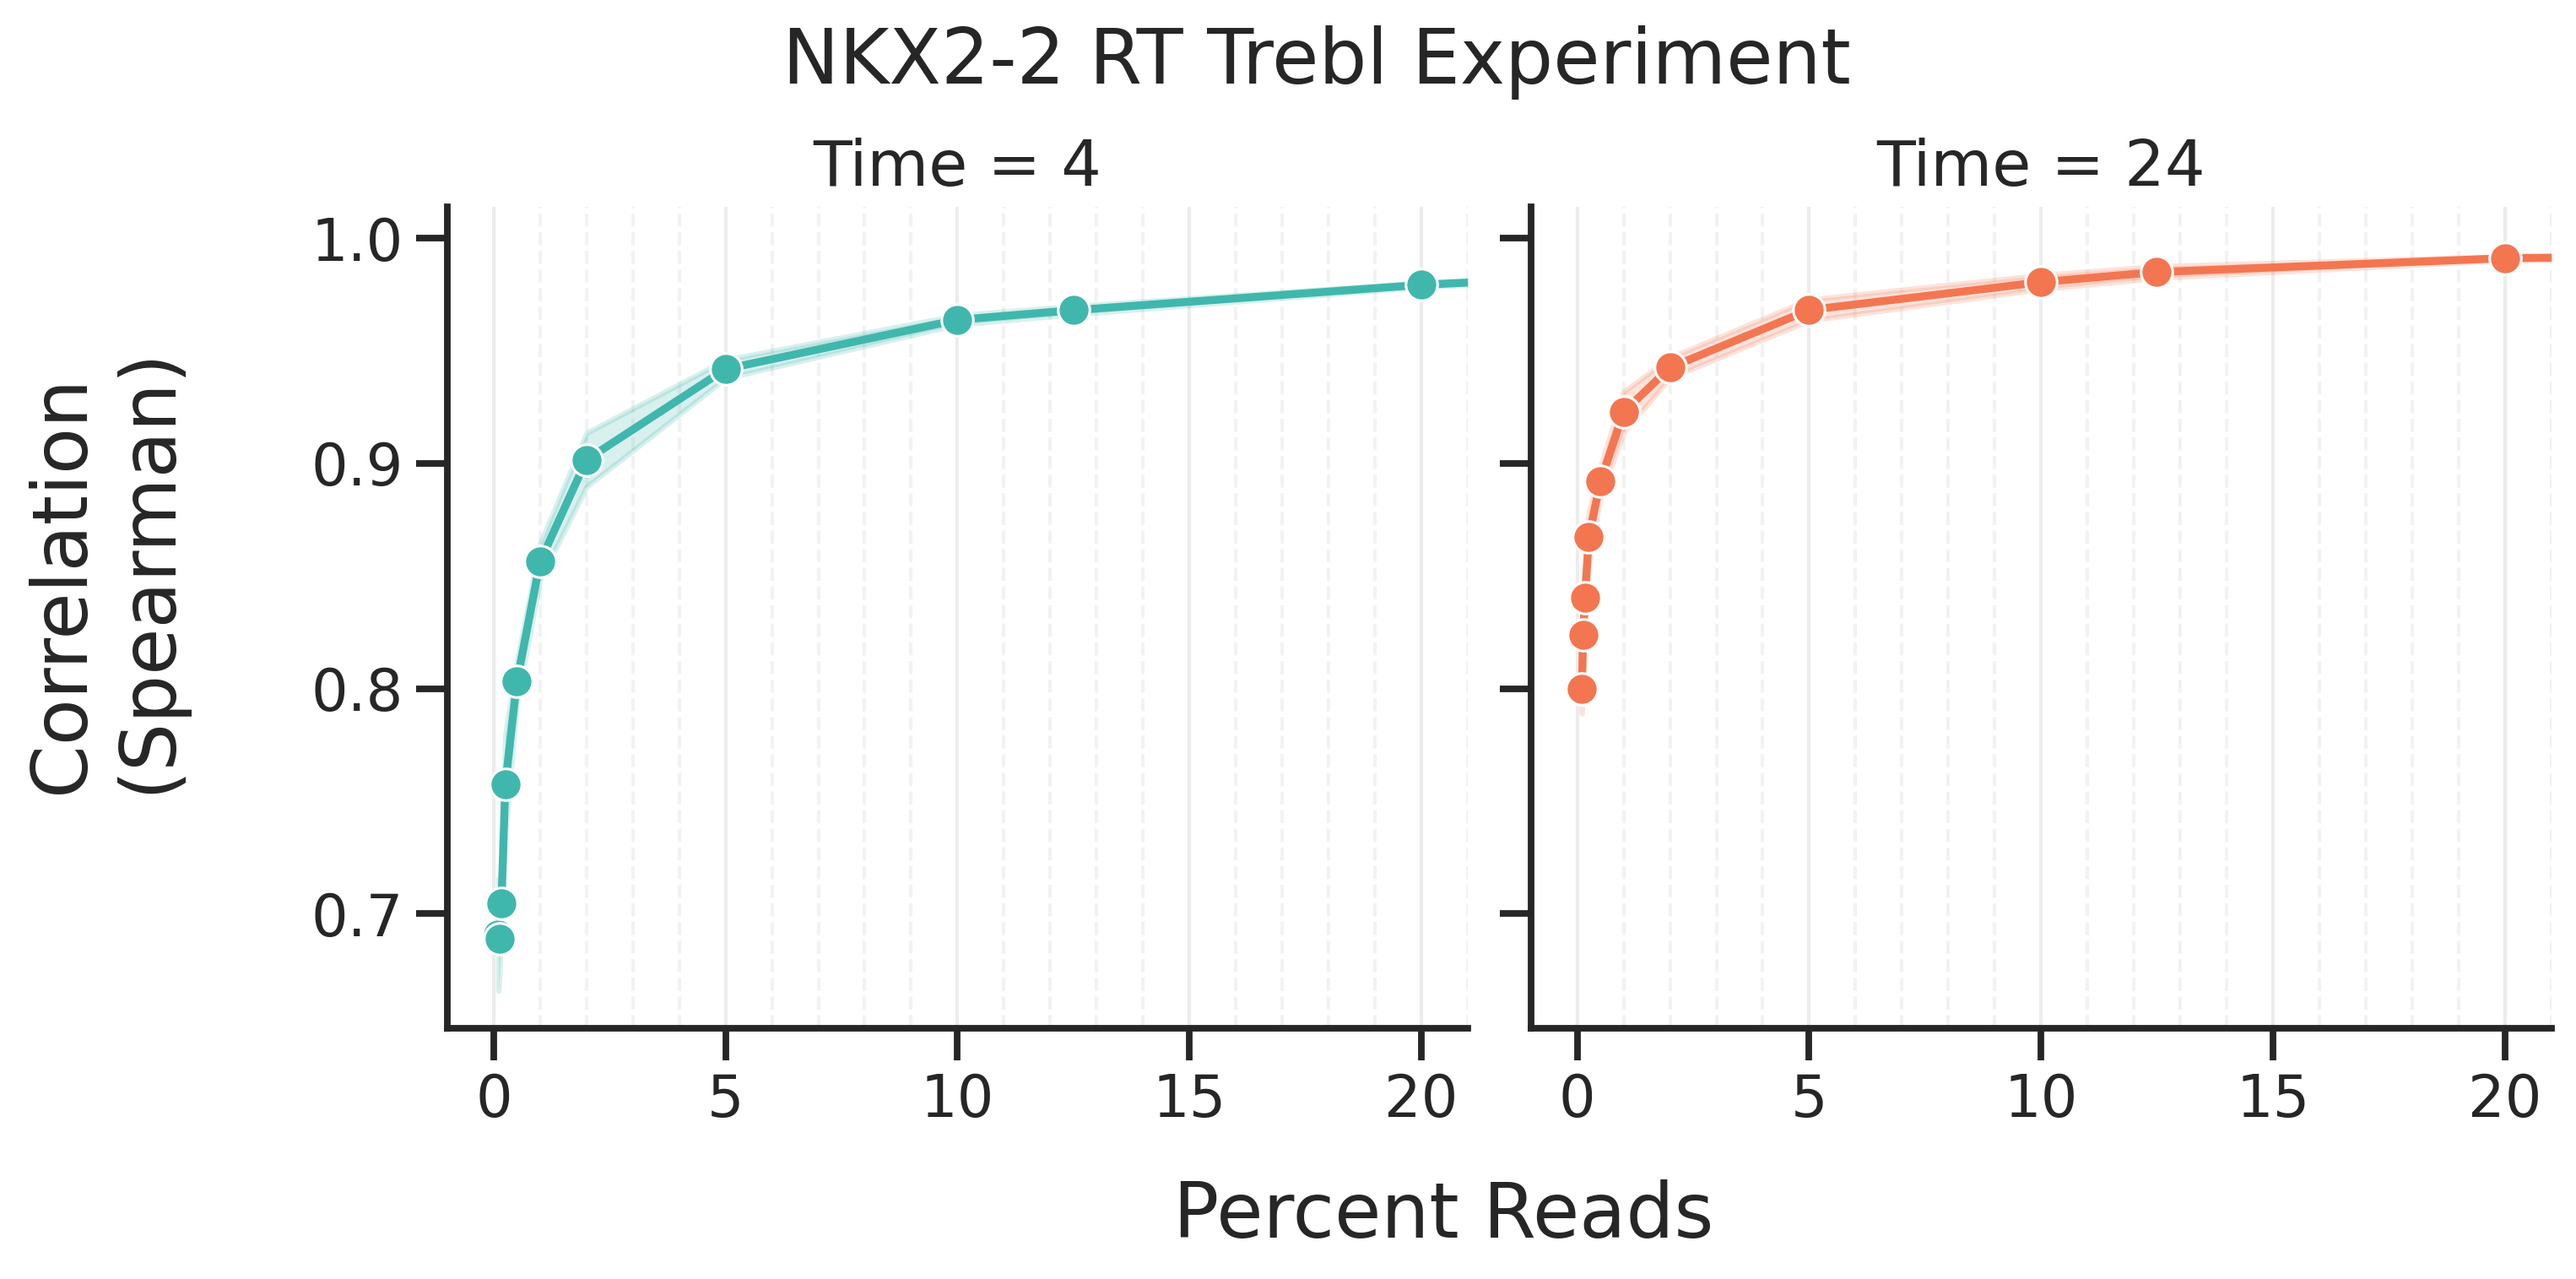

In [15]:
sns.set_context("talk")
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)

# ---------- Spearman only ----------
sns.lineplot(
    data=correlation_df_4_nkx2,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_color
)
axes[0].set_title("Time = 4")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=correlation_df_24_nkx2,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_color
)
axes[1].set_title("Time = 24")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("NKX2-2 RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

plt.tight_layout(pad=0.5)
plt.show()

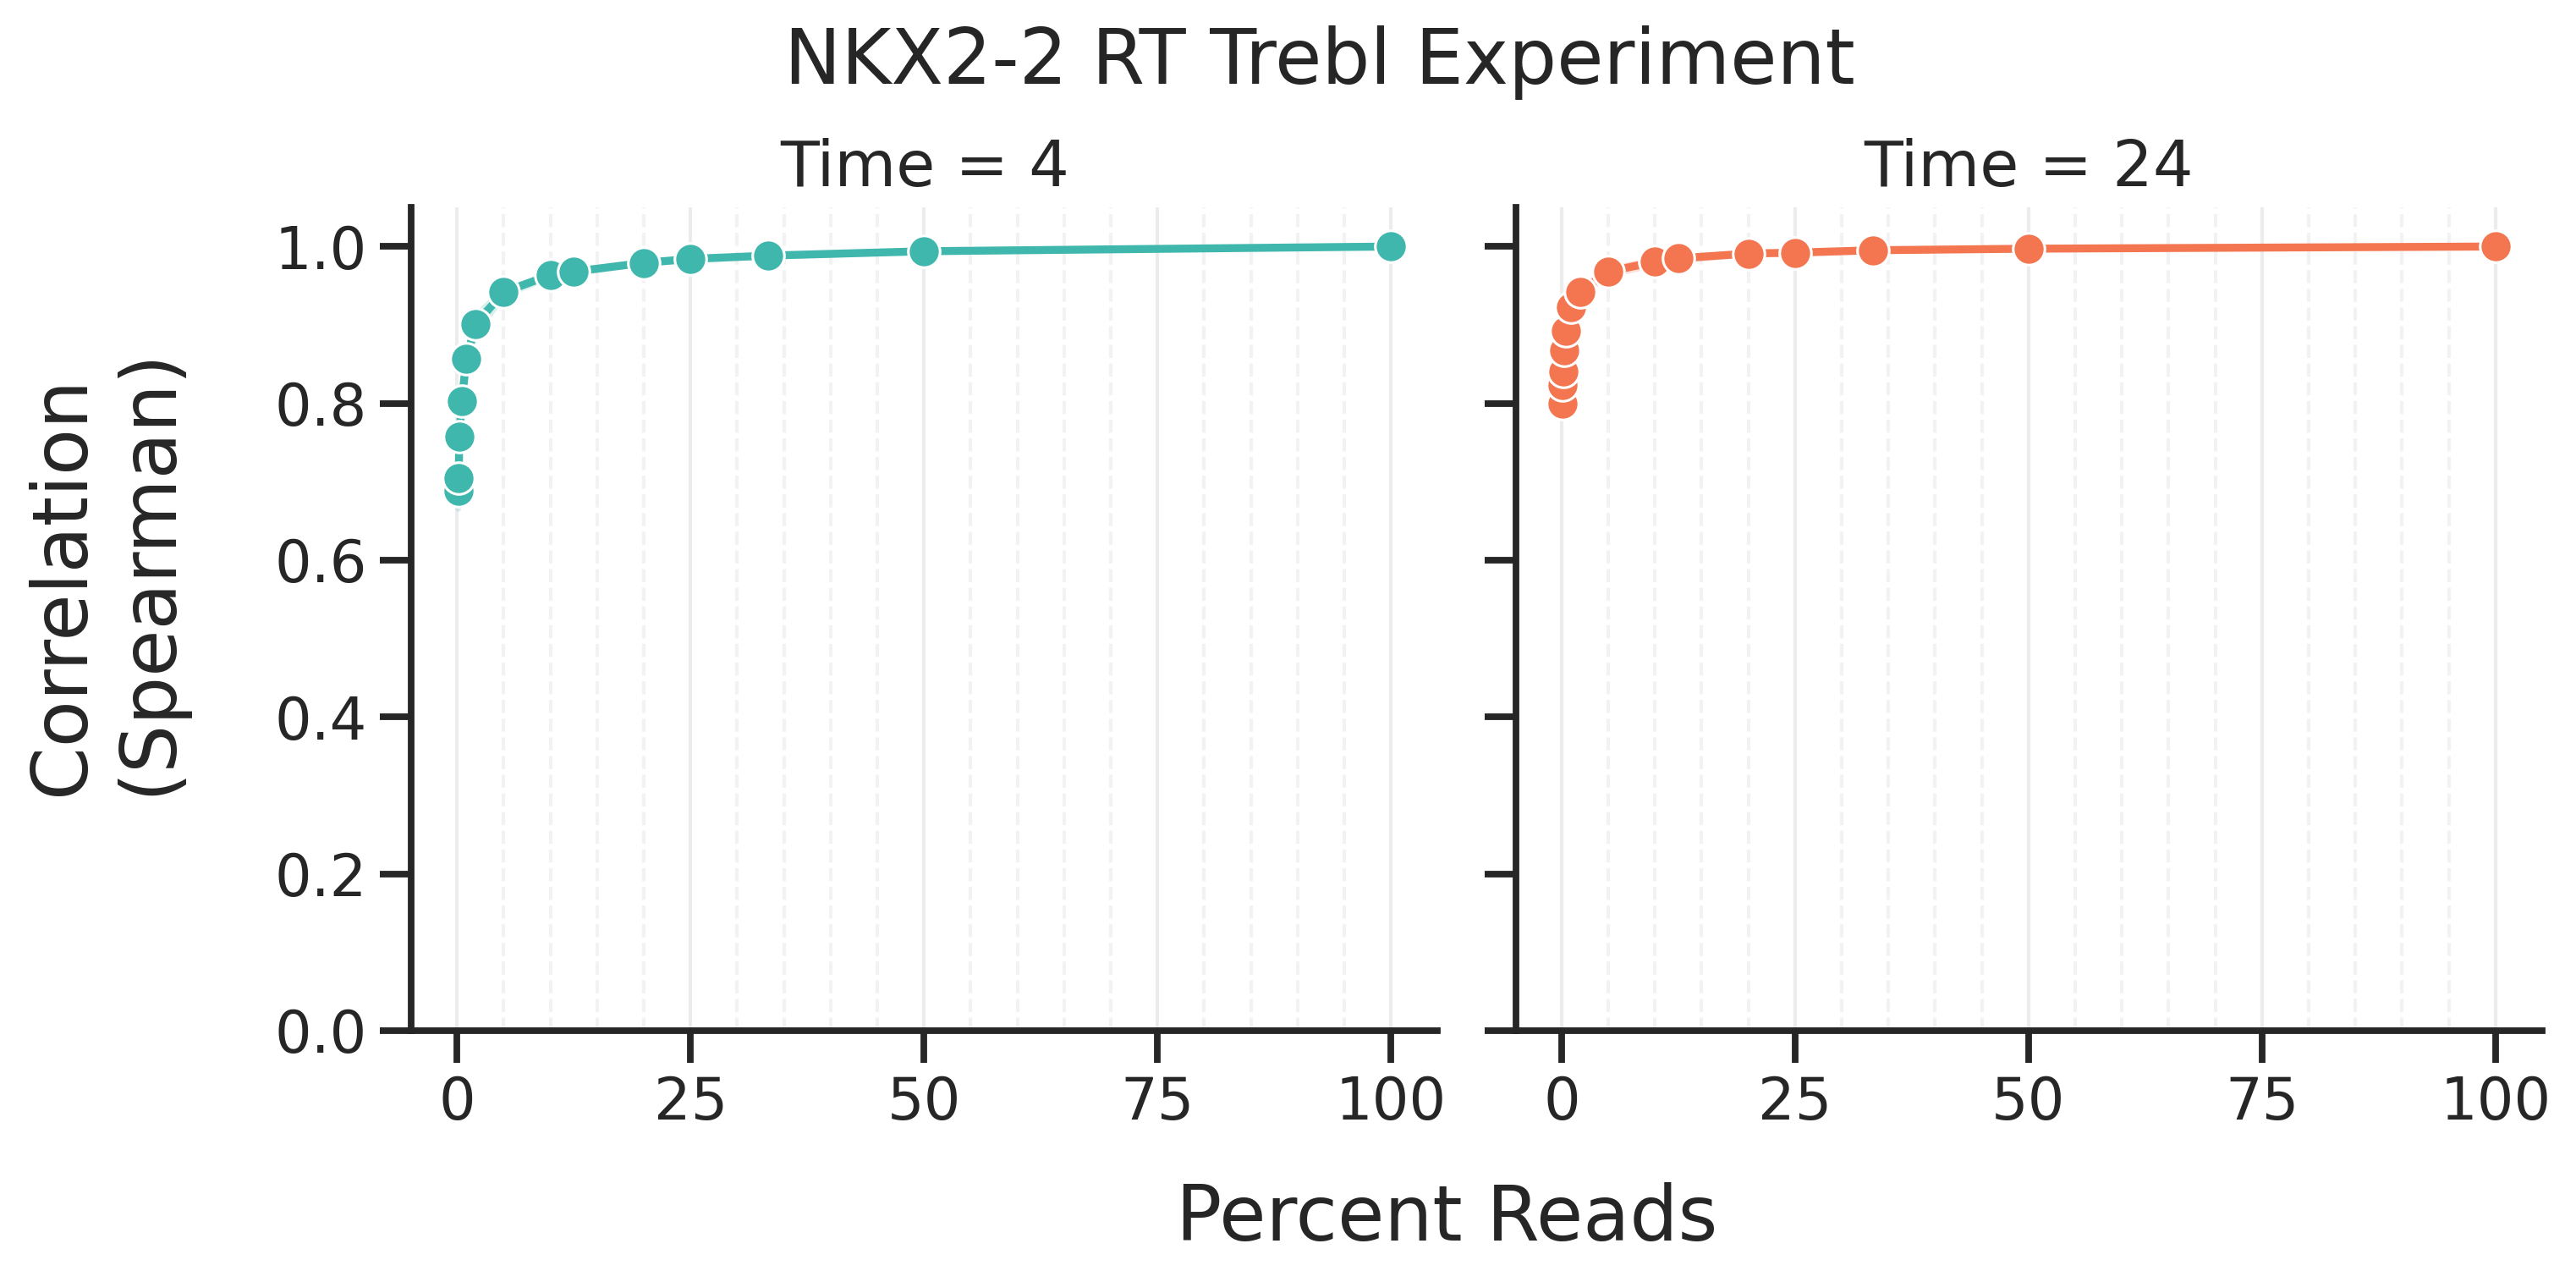

In [16]:
sns.set_context("talk")
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), dpi=300, sharex=True, sharey=True
)

extra_row = pd.DataFrame({
    "percent_reads": [100],
    "spearman_corr": [1.0]
})

correlation_df_4_nkx2_aug = pd.concat(
    [correlation_df_4_nkx2, extra_row],
    ignore_index=True
)

correlation_df_24_nkx2_aug = pd.concat(
    [correlation_df_24_nkx2, extra_row],
    ignore_index=True
)

# ---------- Spearman only ----------
sns.lineplot(
    data=correlation_df_4_nkx2_aug,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[0],
    color = t5_color
)
axes[0].set_title("Time = 4")
axes[0].set_ylabel("")
axes[0].set_xlabel("")
sns.despine(ax=axes[0])

sns.lineplot(
    data=correlation_df_24_nkx2_aug,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1],
    color = t30_color
)
axes[1].set_title("Time = 24")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
sns.despine(ax=axes[1])

fig.supxlabel("Percent Reads", x = 0.55)
fig.supylabel("Correlation\n(Spearman)", x = -0.01, y = 0.55)
fig.suptitle("NKX2-2 RT Trebl Experiment")

for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_ylim(0,1.05)

plt.tight_layout(pad=0.5)
plt.show()

### Reads vs barcodes recovered

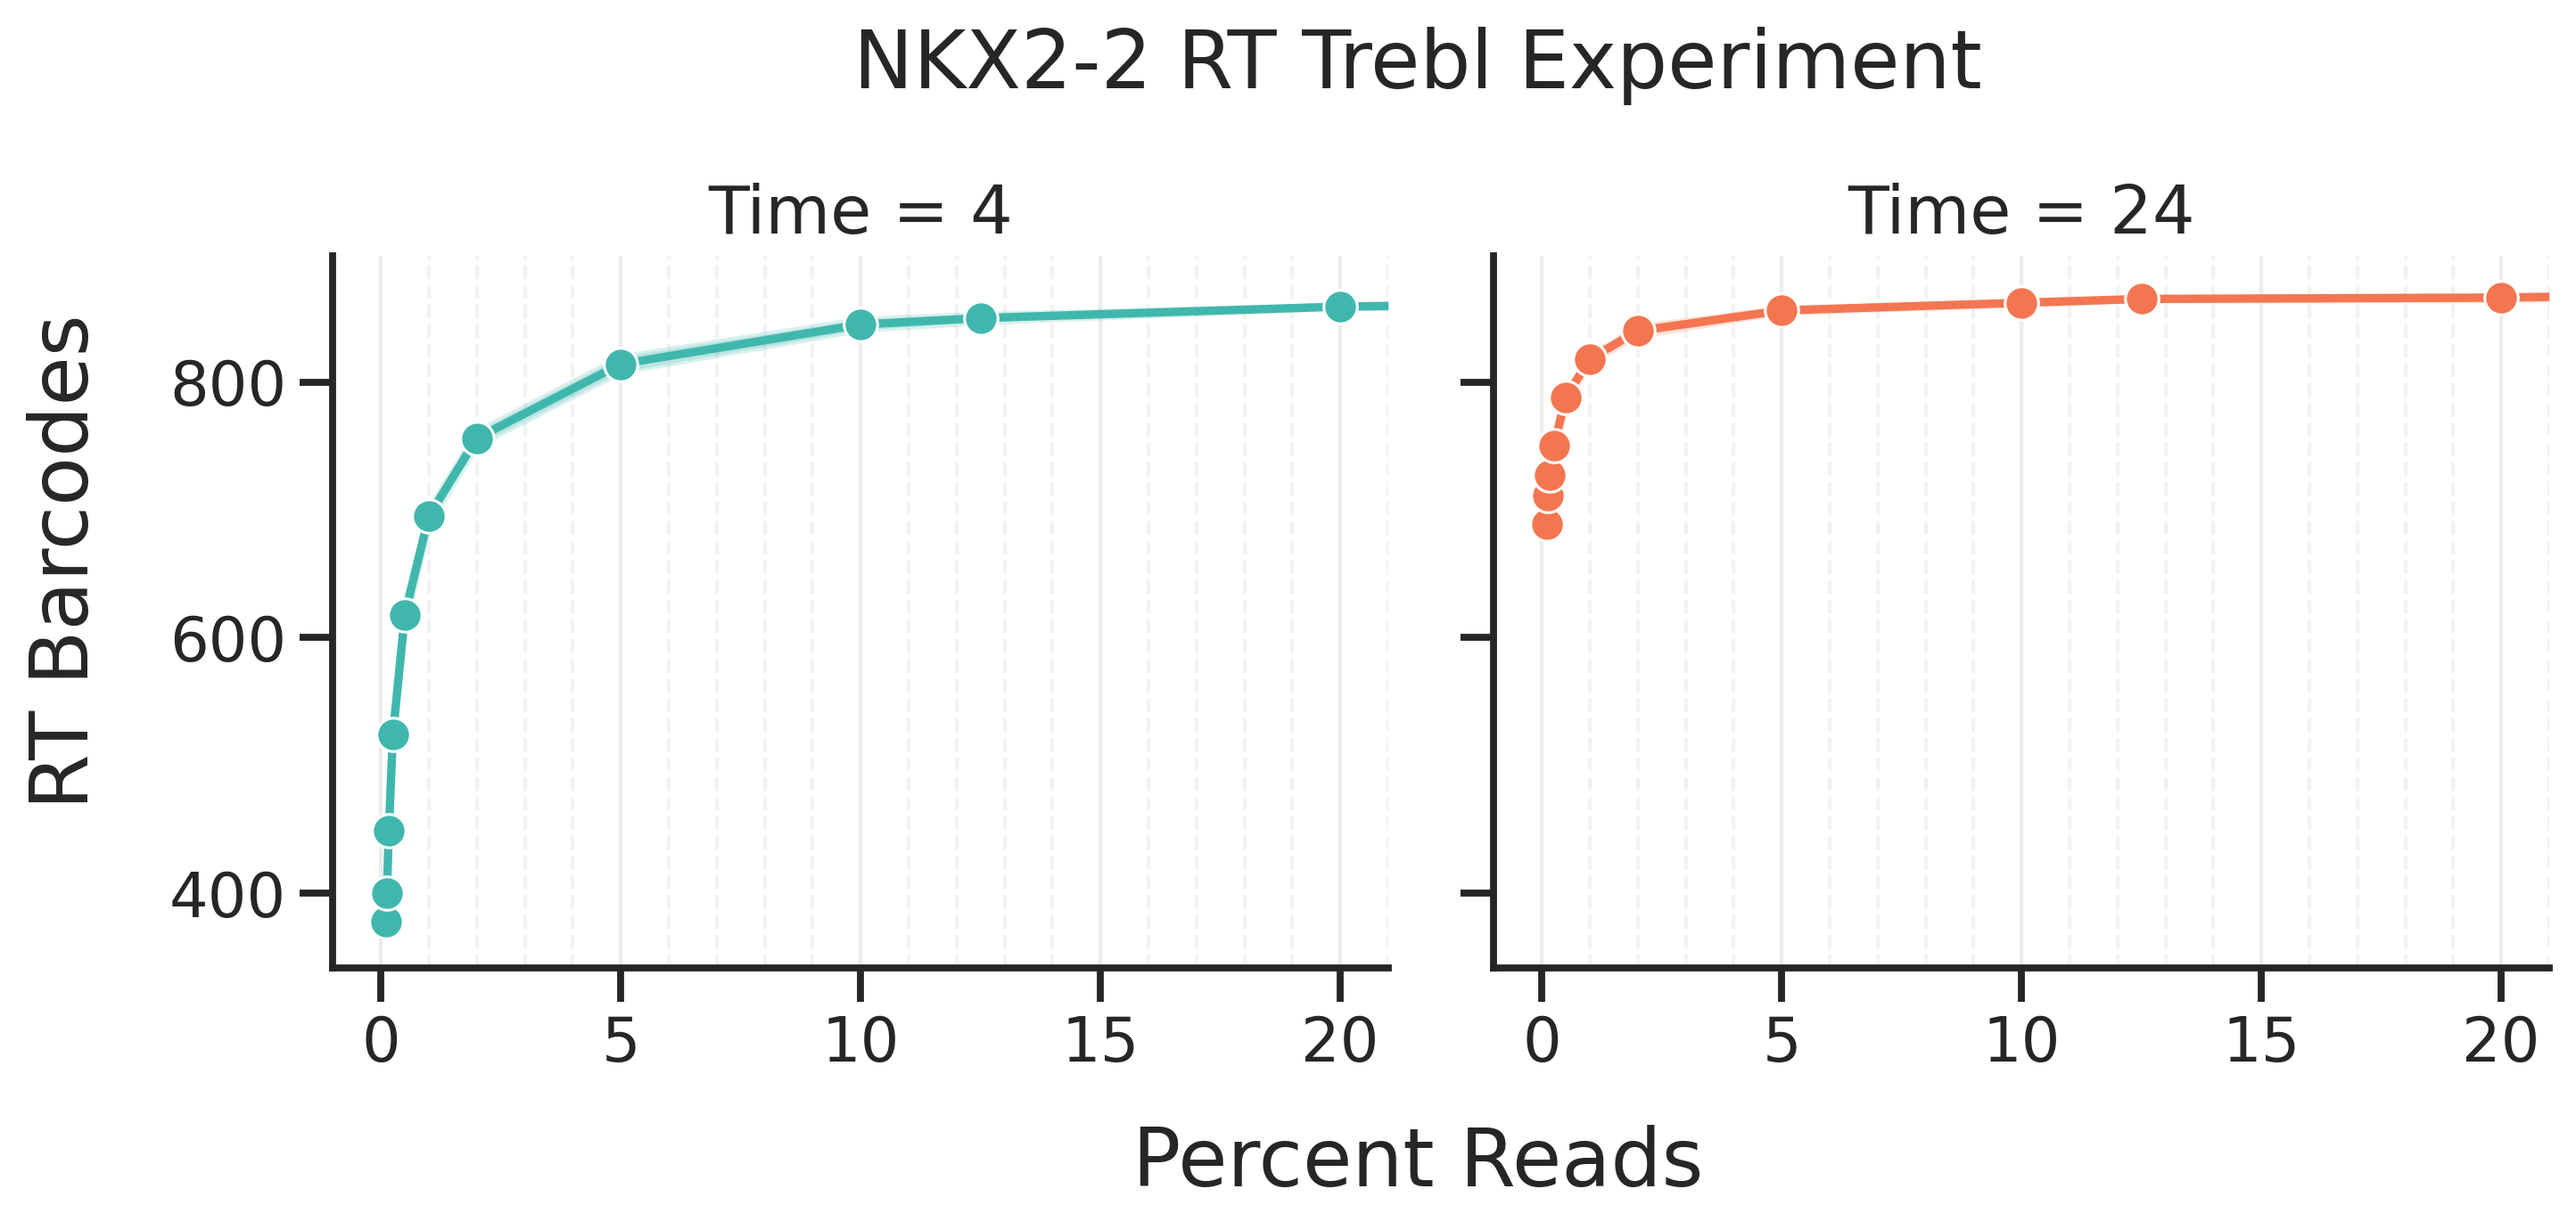

In [17]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=correlation_df_4_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_color
)
ax.set_title("Time = 4")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=correlation_df_24_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_color
)
ax.set_title("Time = 24")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.set_xlim(-1,21)

# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("RT Barcodes", x=0.03, y=0.55)
fig.suptitle("NKX2-2 RT Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

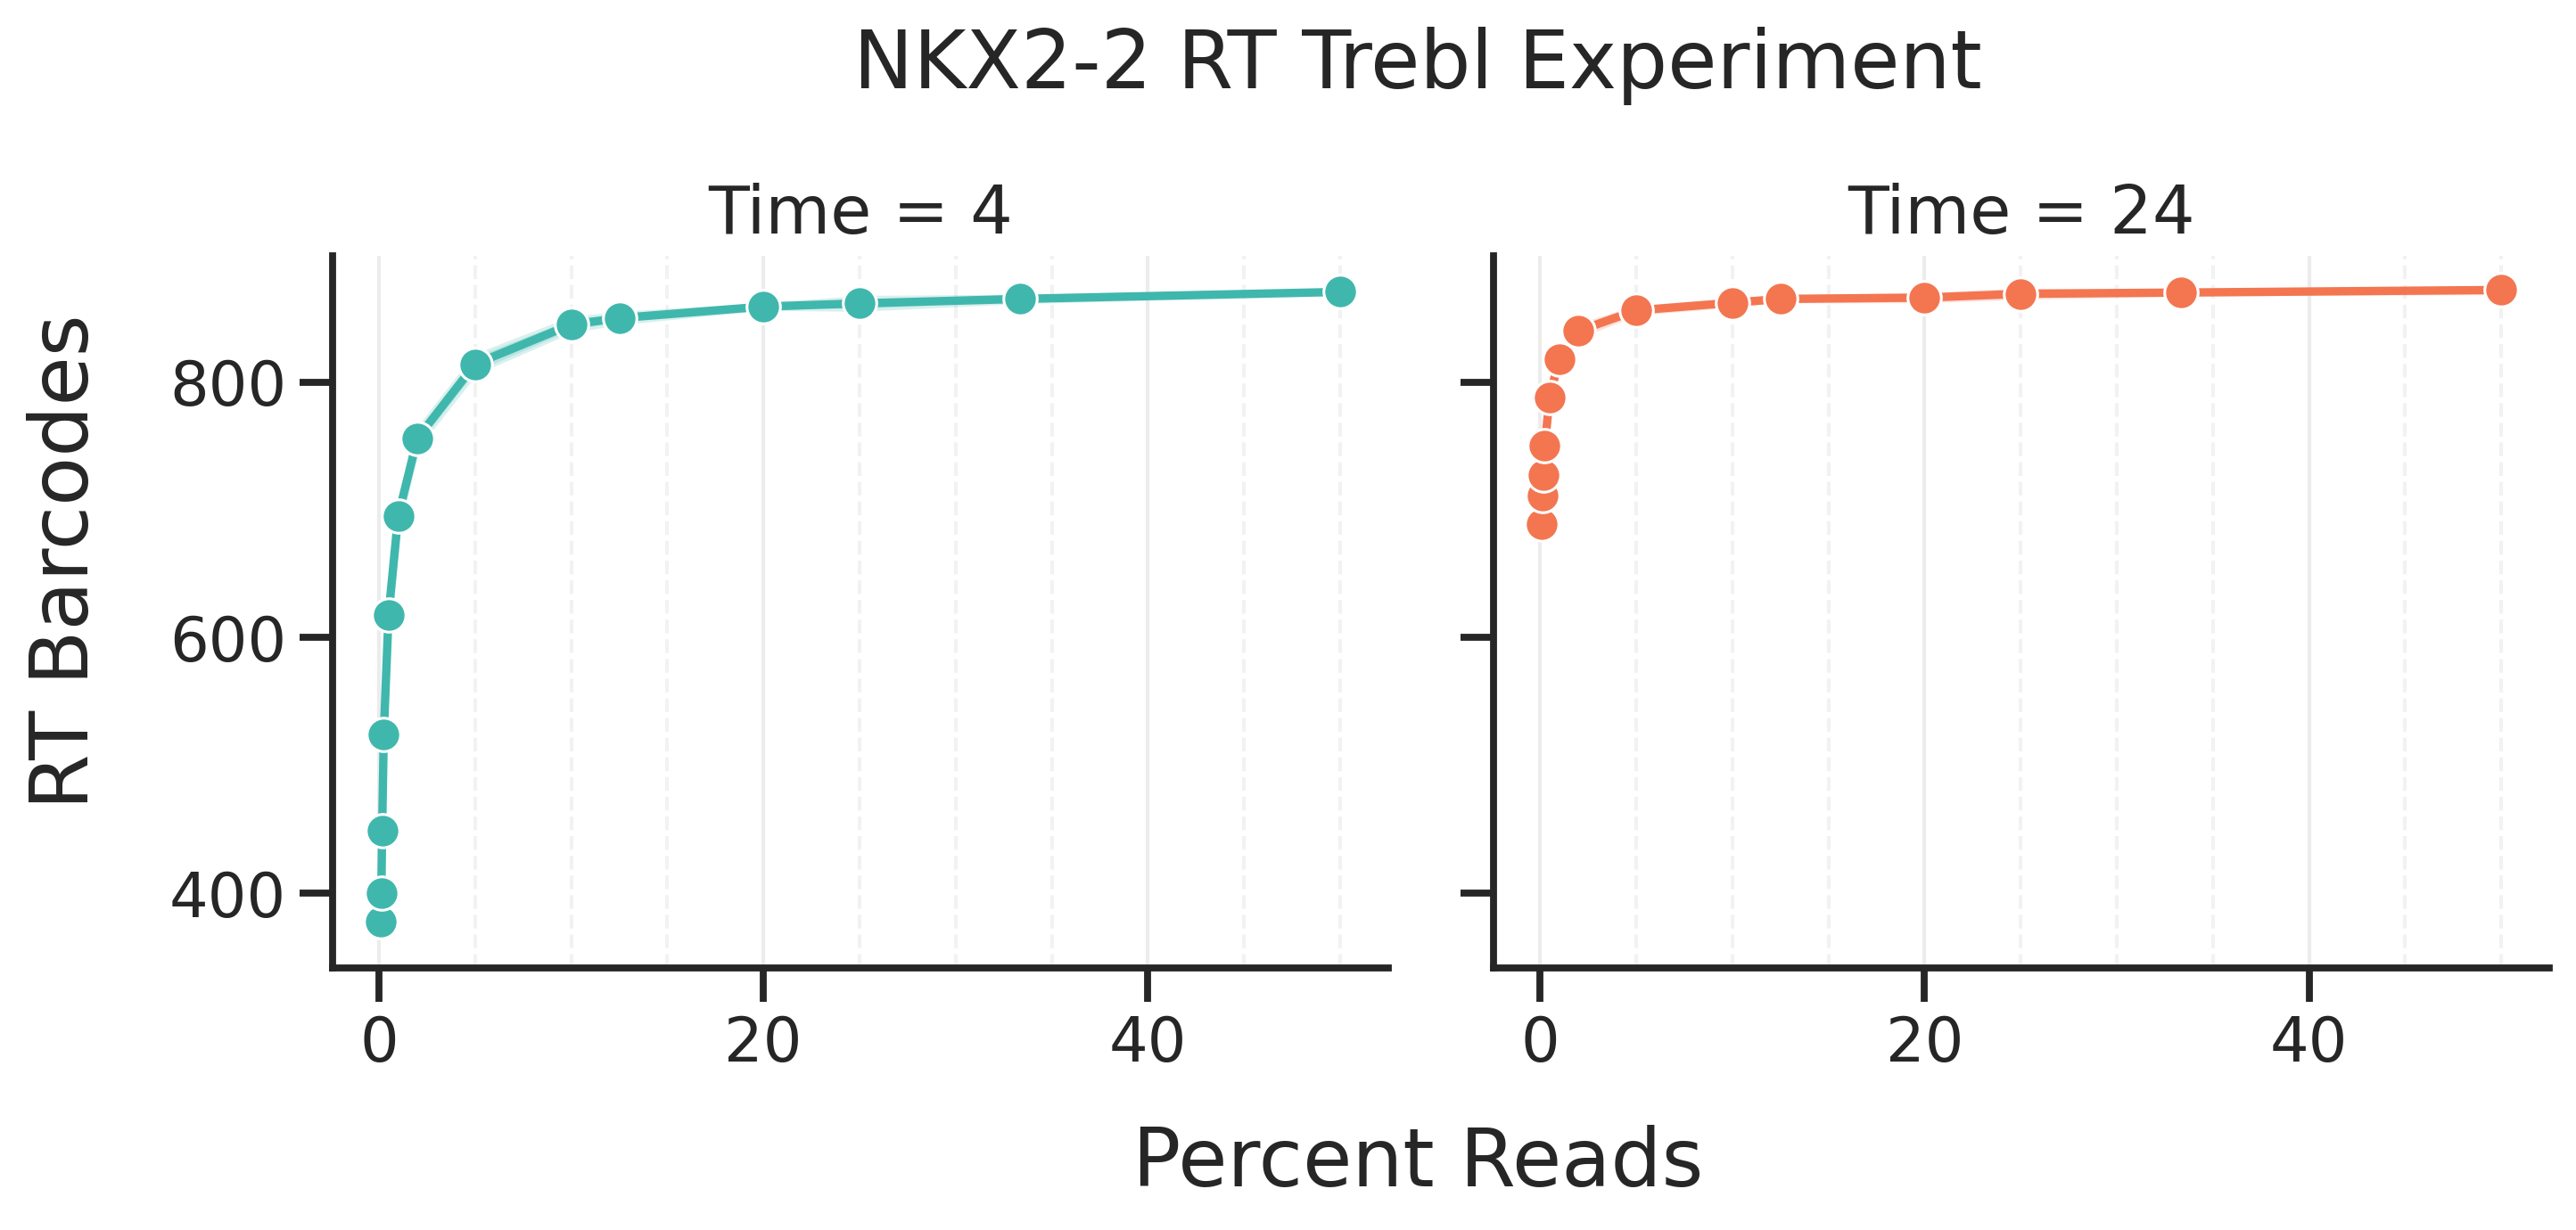

In [18]:
from matplotlib.ticker import MultipleLocator

# Create subplots
sns.set_style('ticks')

fig, axes = plt.subplots(
    1, 2,
    figsize=(10,5),
    dpi=300,
    sharey=True,sharex = True
)
sns.set_context("talk")

# ---------- Time = 5 ----------
ax = axes[0]
sns.lineplot(
    data=correlation_df_4_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t5_color
)
ax.set_title("Time = 4")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


# ---------- Time = 30 ----------
ax = axes[1]
sns.lineplot(
    data=correlation_df_24_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=ax,
    color=t30_color
)
ax.set_title("Time = 24")
ax.set_ylabel("")
ax.set_xlabel("")
sns.despine(ax=ax)


for ax in axes.flatten():
    # Major vertical grid lines
    ax.grid(True, which='major', axis='x', linestyle='-', color='gray', alpha=0.15, linewidth = 1)
    # Minor ticks
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    # Minor vertical grid lines
    ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', alpha=0.1, linewidth = 1)
    ax.tick_params(axis='x', which='minor', length=0)


# Axis labels and title
fig.supxlabel("Percent Reads", x=0.55, y=0.07)
fig.supylabel("RT Barcodes", x=0.03, y=0.55)
fig.suptitle("NKX2-2 RT Trebl Experiment", y=0.95, x=0.55)

plt.tight_layout()
plt.show()

### All together

In [19]:
ad_time_4_summary_nkx2.iloc[5:]

num_splits      percent_reads               time    unique_umis  \
   Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1           mean   
5                 5.0          20.000000                  4  261717.400000   
6                 8.0          12.500000                  4  192644.200000   
7                10.0          10.000000                  4  163854.666667   
8                20.0           5.000000                  4   93214.600000   
9                50.0           2.000000                  4   40606.800000   
10              100.0           1.000000                  4   20895.200000   
11              200.0           0.500000                  4   10649.800000   
12              400.0           0.250000                  4    5358.200000   
13              600.0           0.166667                  4    3601.800000   
14              800.0           0.125000                  4    2734.000000   
15             1000.0           0.100000                  4    2223.800000   

                
           std  
5   176.186833  
6   173.951717  
7   115.319845  
8   105.516823  
9   151.212433  
10   65.373542  
11   41.008536  
12   26.300190  
13   25.528416  
14   29.214722  
15   13.935566

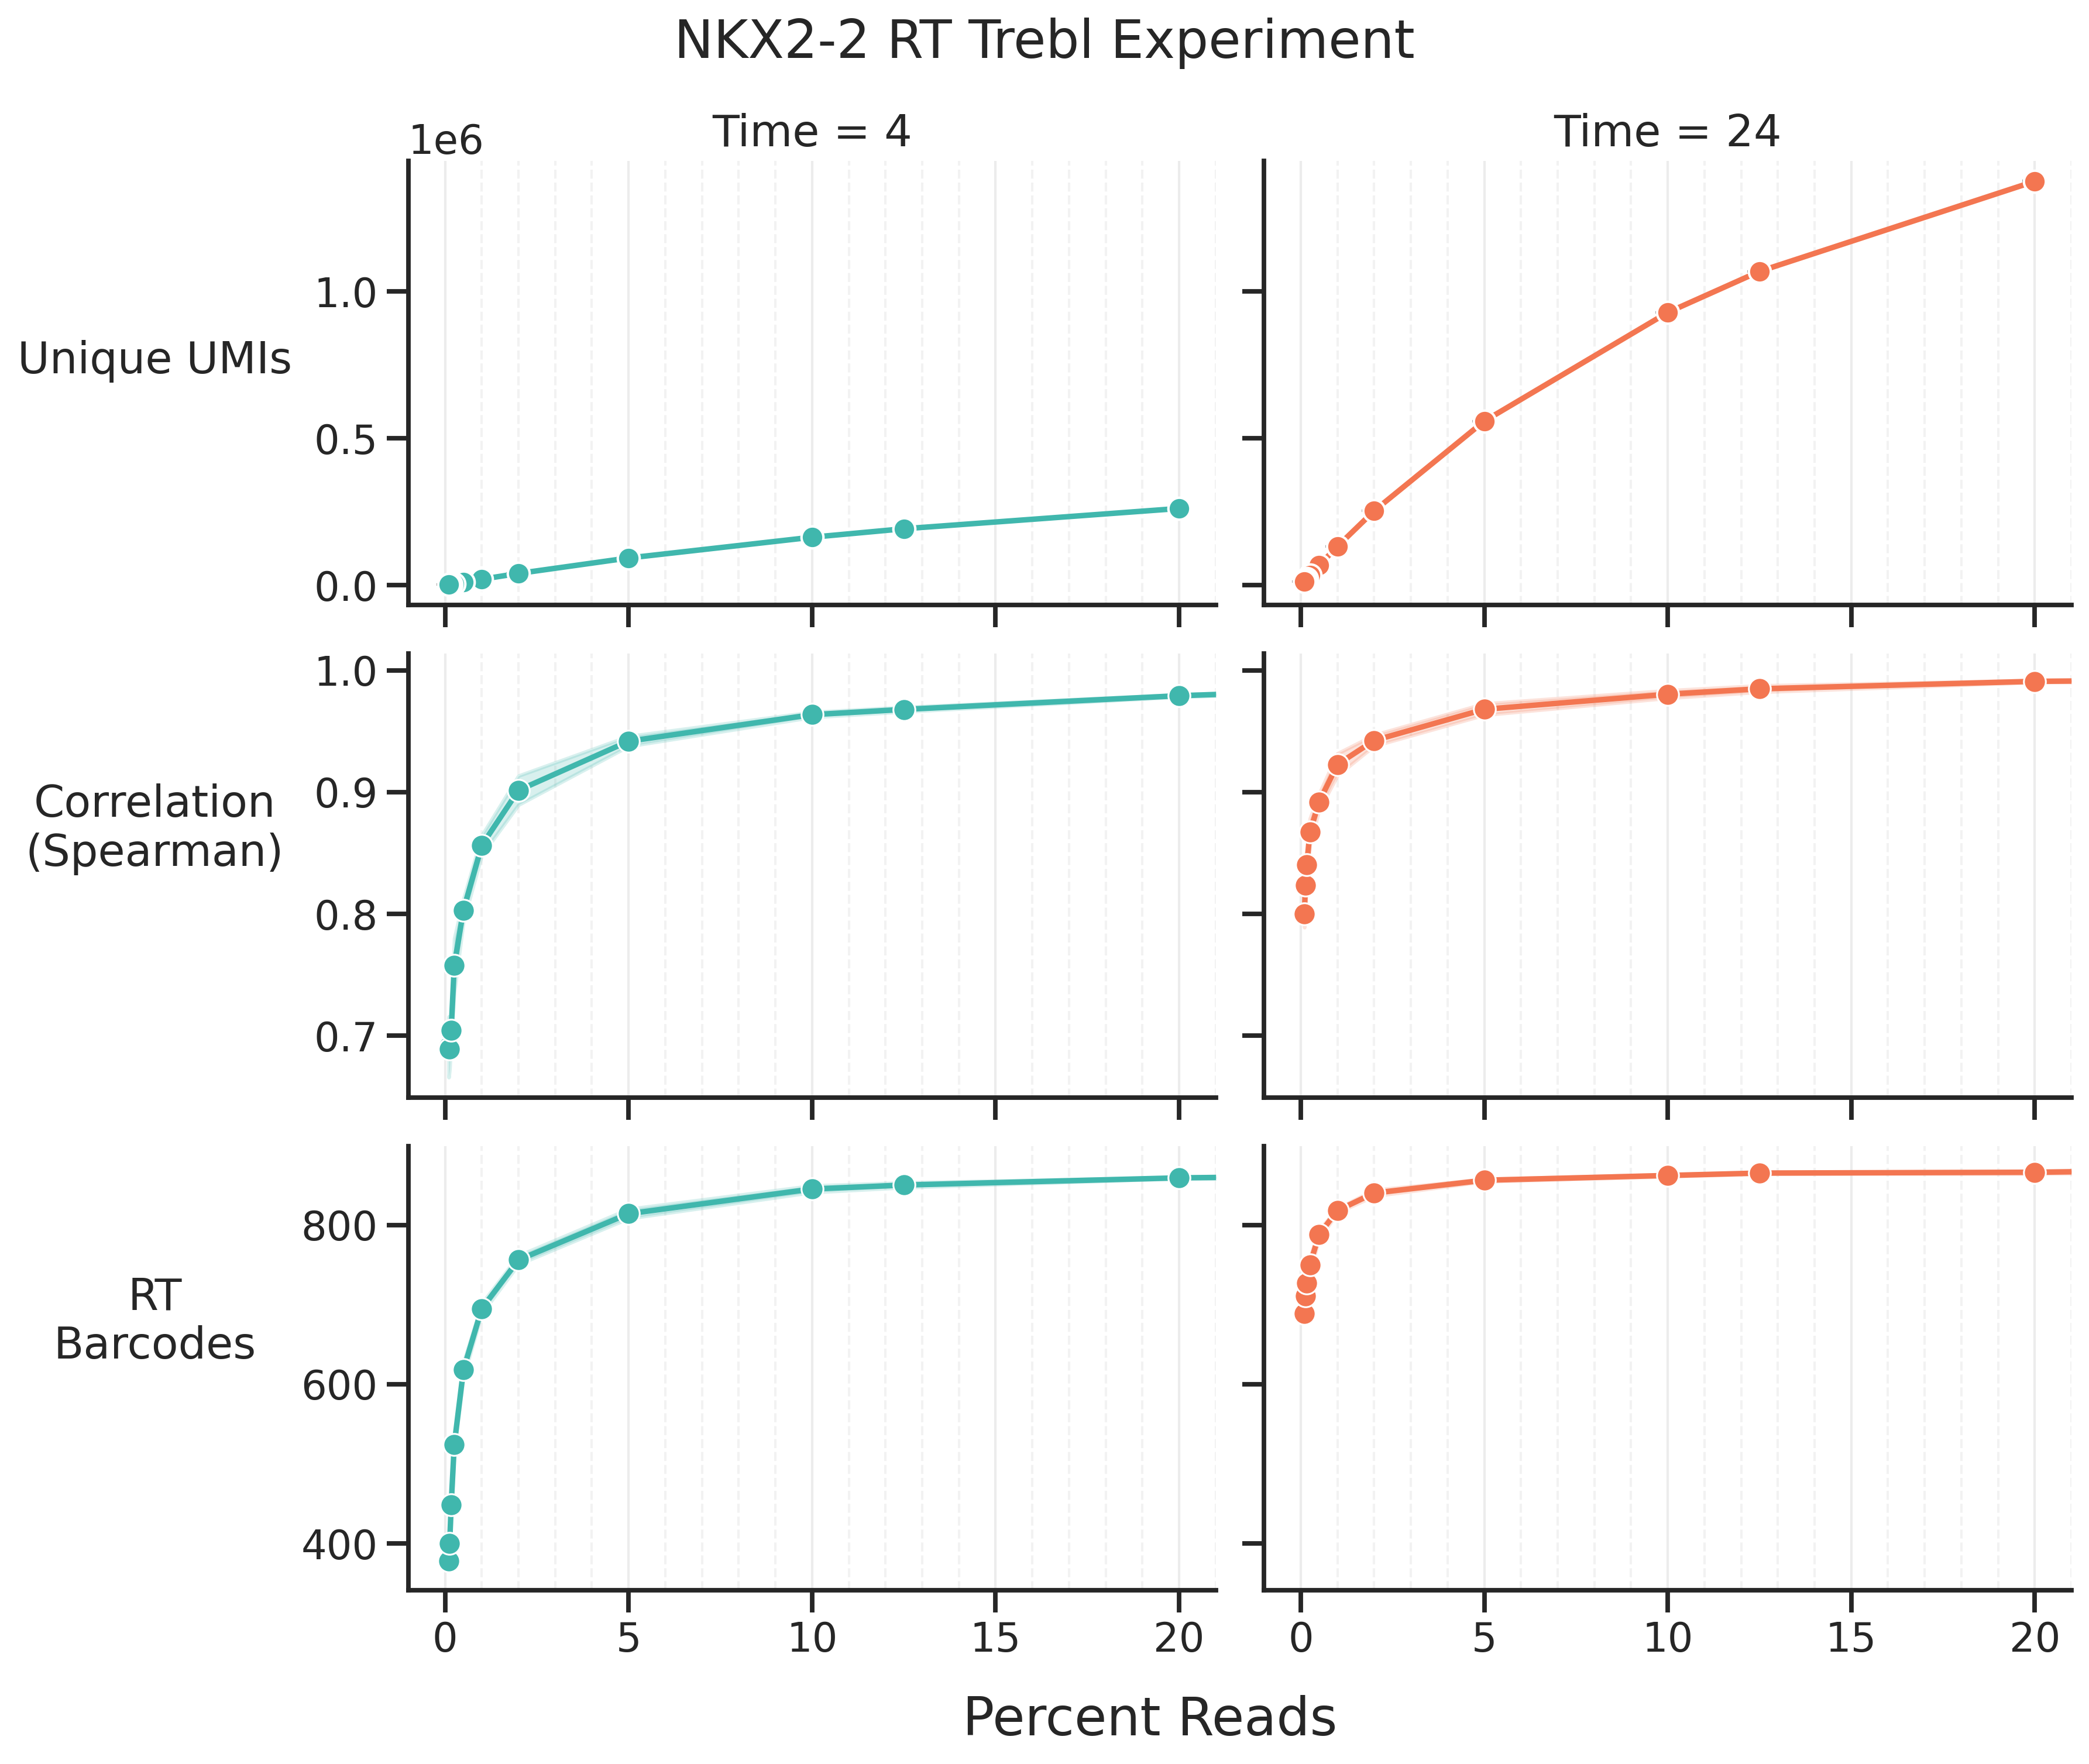

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

sns.set_style("ticks")
sns.set_context("talk")

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 10),
    dpi=300,
    sharex=True,
    sharey = 'row'
)

# =========================
# Row 1 — Unique UMIs
# =========================

# ---- Time 5 ----
ax = axes[0, 0]
ax.errorbar(
    x=ad_time_4_summary_nkx2.iloc[5:]['percent_reads'],
    y=ad_time_4_summary_nkx2.iloc[5:][('unique_umis', 'mean')],
    yerr=ad_time_4_summary_nkx2.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t5_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'
)
ax.set_title("Time = 4")
ax.set_ylabel("Unique UMIs", rotation = 0, labelpad=60)
sns.despine(ax=ax)

# ---- Time 30 ----
ax = axes[0, 1]
ax.errorbar(
    x=ad_time_24_summary_nkx2.iloc[5:]['percent_reads'],
    y=ad_time_24_summary_nkx2.iloc[5:][('unique_umis', 'mean')],
    yerr=ad_time_24_summary_nkx2.iloc[5:][('unique_umis', 'std')],
    fmt='-o',
    capsize=5,
    color=t30_color,
    ecolor='tab:gray',
    elinewidth=2,
    markeredgecolor = 'white'

)
ax.set_title("Time = 24")
sns.despine(ax=ax)


# =========================
# Row 2 — Spearman correlation
# =========================

sns.lineplot(
    data=correlation_df_4_nkx2,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 0],
    color=t5_color
)
axes[1, 0].set_ylabel("Correlation\n(Spearman)", rotation = 0, labelpad=60)
sns.despine(ax=axes[1, 0])

sns.lineplot(
    data=correlation_df_24_nkx2,
    x="percent_reads",
    y="spearman_corr",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[1, 1],
    color=t30_color
)
sns.despine(ax=axes[1, 1])


# =========================
# Row 3 — Reporter barcodes
# =========================

sns.lineplot(
    data=correlation_df_4_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 0],
    color=t5_color
)
axes[2, 0].set_ylabel("RT\nBarcodes", rotation = 0, labelpad=60)
sns.despine(ax=axes[2, 0])

sns.lineplot(
    data=correlation_df_24_nkx2,
    x="percent_reads",
    y="num_rows",
    estimator="median",
    errorbar=("sd"),
    marker="o",
    ax=axes[2, 1],
    color=t30_color
)
sns.despine(ax=axes[2, 1])
axes[2, 1].set_ylabel("")


# =========================
# Shared formatting
# =========================

for ax in axes.flatten():
    ax.set_xlim(-1, 21)

    # Major vertical grid
    ax.grid(True, which='major', axis='x',
            linestyle='-', color='gray', alpha=0.15, linewidth=1)

    # Minor vertical grid every 1%
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(True, which='minor', axis='x',
            linestyle='--', color='gray', alpha=0.1, linewidth=1)

    # Hide minor tick marks (keep grid)
    ax.tick_params(axis='x', which='minor', length=0)

    ax.set_xlabel("")

# Global labels
fig.supxlabel("Percent Reads",x = 0.55)
fig.suptitle("NKX2-2 RT Trebl Experiment", y=0.995)
fig.align_ylabels()

plt.tight_layout(pad=0.6)
plt.show()

### Reads per UMI

#### T = 5

In [21]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

dfs = []

folder = Path("../../output/NKX2-2/downsampling/")
chunk_files_t5 = sorted(folder.glob("*RTBC_Puro_Only_R1_T4*/*_reads_per_umi.tsv"))

# Appending the last
chunk_files_t5.append("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102/r5_RTBC_Puro_Only_R1_T4_S102_reads_per_umi.tsv")

for path in chunk_files_t5:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        downsample_pct = np.round(100 / num_chunks, 3)
    except:
        num_chunks = 1
        downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_1_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_1.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_2_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_2.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_3_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_3.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_4_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_4.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_5_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_1000_chunks_part_5.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r5_RTBC_Puro_Only_R1_T4_S102_100_chunks_part_1_fq_gz/r5_RTBC_Puro_Only_R1_T4_S102_100

,reads,downsample,downsample_val
5736223,1,100.0%,100.0
5736224,1,100.0%,100.0
5736225,1,100.0%,100.0
5736226,1,100.0%,100.0
5736227,1,100.0%,100.0
...,...,...,...
29,1,0.1%,0.1
30,1,0.1%,0.1
31,1,0.1%,0.1
32,1,0.1%,0.1


In [22]:
all_df["downsample_val"].value_counts()

downsample_val
20.000     1000000
10.000      993742
12.500      975786
25.000      800000
33.333      600000
5.000       468930
50.000      400000
2.000       203588
100.000     200000
1.000       104630
0.500        53290
0.250        26806
0.167        18015
0.125        13675
0.100        11122
Name: count, dtype: int64

In [23]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
5736223,1,100.0%,100.0,0.0
5736224,1,100.0%,100.0,0.0
5736225,1,100.0%,100.0,0.0
5736226,1,100.0%,100.0,0.0
5736227,1,100.0%,100.0,0.0
...,...,...,...,...
29,1,0.1%,0.1,0.0
30,1,0.1%,0.1,0.0
31,1,0.1%,0.1,0.0
32,1,0.1%,0.1,0.0


In [33]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 50, 33.333, 20, 10, 5, 1])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
5736223,1,100.0%,100.0,0.0
5736224,1,100.0%,100.0,0.0
5736225,1,100.0%,100.0,0.0
5736226,1,100.0%,100.0,0.0
5736227,1,100.0%,100.0,0.0
...,...,...,...,...
115721,1,1.0%,1.0,0.0
115722,1,1.0%,1.0,0.0
115723,1,1.0%,1.0,0.0
115724,1,1.0%,1.0,0.0


In [34]:
all_df["downsample_val"].value_counts()

downsample_val
20.000     1000000
10.000      993742
12.500      975786
25.000      800000
33.333      600000
5.000       468930
50.000      400000
2.000       203588
100.000     200000
1.000       104630
0.500        53290
0.250        26806
0.167        18015
0.125        13675
0.100        11122
Name: count, dtype: int64

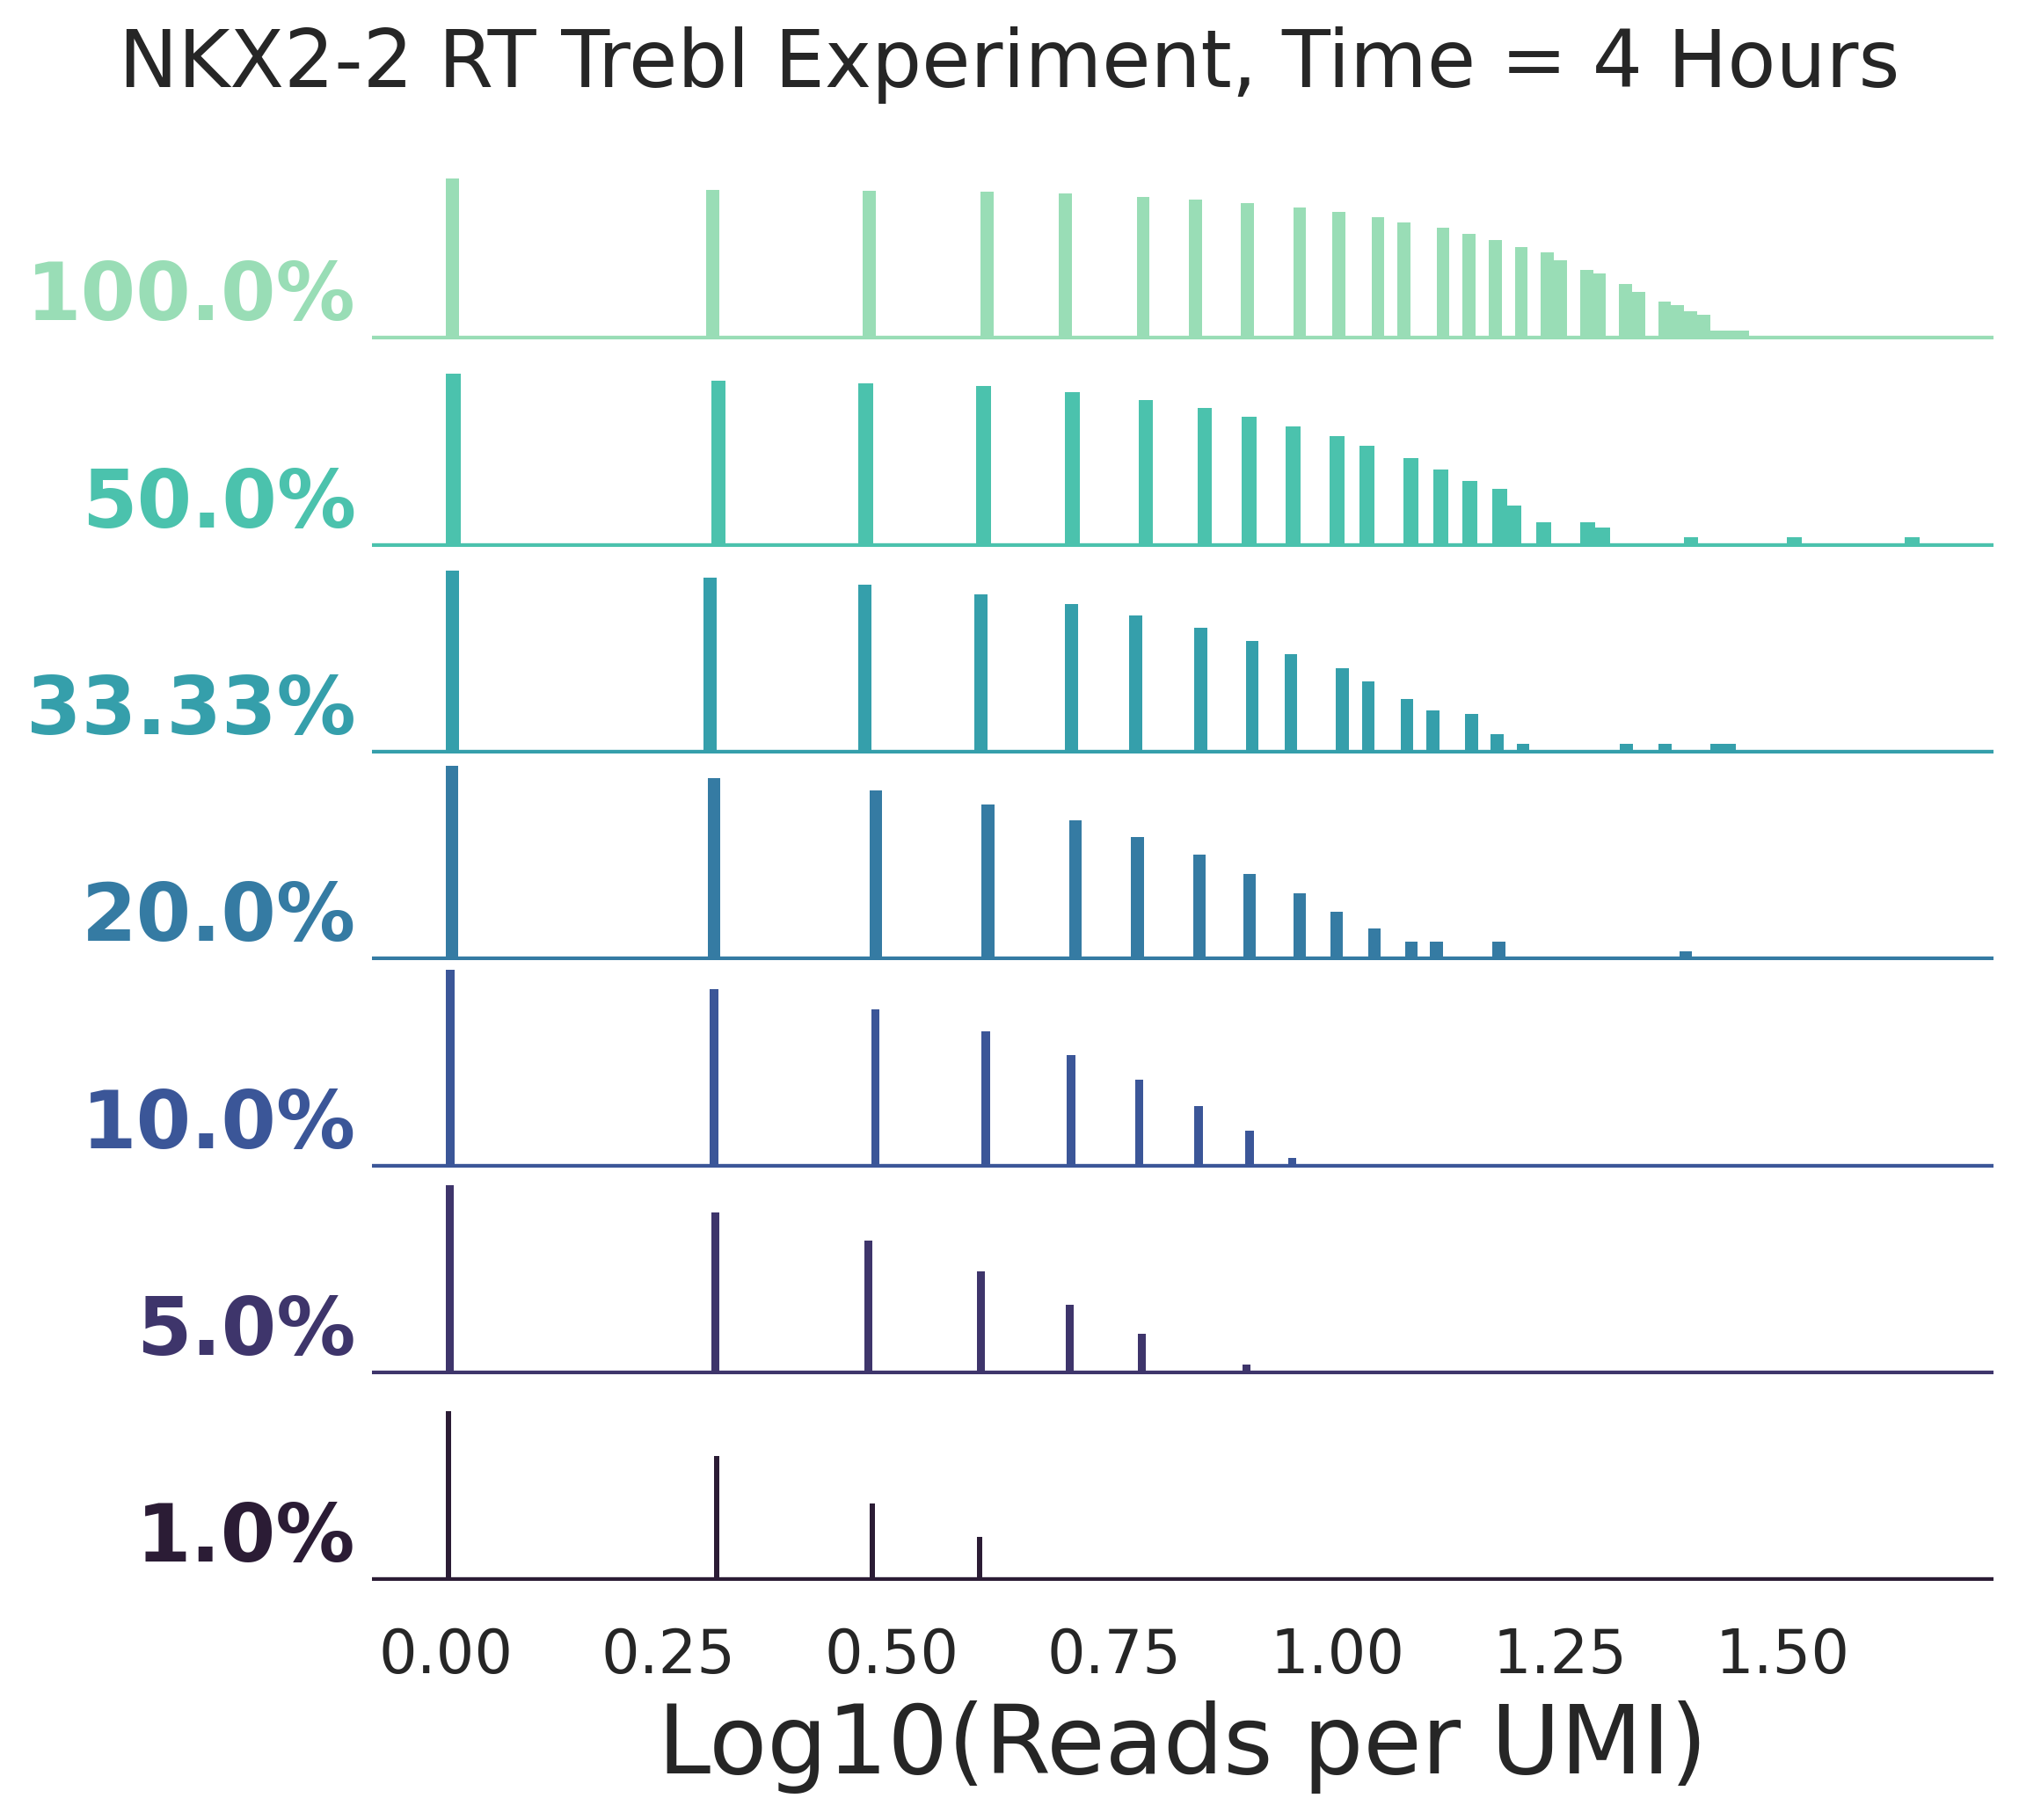

In [36]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=False)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=8,
    height=1,
    palette='mako',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='none',
        color=color,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=0)
sns.despine(bottom = True, left=True)


g.fig.suptitle("NKX2-2 RT Trebl Experiment, Time = 4 Hours")
plt.show()

#### t = 30 minutes

In [37]:
dfs = []

folder = Path("../../output/NKX2-2/downsampling/")
chunk_files_t5 = sorted(folder.glob("*RTBC_Puro_Only_R1_T24*/*_reads_per_umi.tsv"))

# Appending the last
chunk_files_t5.append("../../output/NKX2-2/TL4B2/puro_only/no_err_corr/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106/r9_RTBC_Puro_Only_R1_T24_S106_reads_per_umi.tsv")

for path in chunk_files_t5:
    print(path)
    df = pd.read_csv(path, sep="\t", nrows=200_000)

    try:
        num_chunks = int(re.search(r"(\d+)_chunks", path.name).group(1))
        downsample_pct = np.round(100 / num_chunks, 3)
    except:
        num_chunks = 1
        downsample_pct = np.round(100 / num_chunks, 3)
        
    df = df.assign(
        downsample=f"{downsample_pct}%",
        downsample_val=downsample_pct
    )

    dfs.append(df[["reads", "downsample", "downsample_val"]])

all_df = pd.concat(dfs, ignore_index=True)

# Ensure correct vertical ordering
all_df = all_df.sort_values("downsample_val", ascending=False)
all_df

../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_1.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_2_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_2.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_3_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_3.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_4_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_4.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_5_fq_gz/r9_RTBC_Puro_Only_R1_T24_S106_1000_chunks_part_5.fq_reads_per_umi.tsv
../../output/NKX2-2/downsampling/trebl_experiment_r9_RTBC_Puro_Only_R1_T24_S106_100_chunks_part_1_fq_gz/r9_RTBC_Puro_Only_R1_

,reads,downsample,downsample_val
8286478,12,100.0%,100.0
8286479,12,100.0%,100.0
8286496,12,100.0%,100.0
8286497,12,100.0%,100.0
8286498,12,100.0%,100.0
...,...,...,...
139,1,0.1%,0.1
140,1,0.1%,0.1
141,1,0.1%,0.1
142,1,0.1%,0.1


In [38]:
all_df["downsample_val"].value_counts()

downsample_val
10.000     1000000
12.500     1000000
20.000     1000000
2.000      1000000
5.000      1000000
25.000      800000
1.000       668515
33.333      600000
50.000      400000
0.500       341361
100.000     200000
0.250       138101
0.167       115631
0.125        86868
0.100        69375
Name: count, dtype: int64

In [39]:
all_df = all_df[all_df['reads'] > 0].copy()  # remove zeros
all_df['log_reads'] = np.log10(all_df['reads'])
all_df

,reads,downsample,downsample_val,log_reads
8286478,12,100.0%,100.0,1.079181
8286479,12,100.0%,100.0,1.079181
8286496,12,100.0%,100.0,1.079181
8286497,12,100.0%,100.0,1.079181
8286498,12,100.0%,100.0,1.079181
...,...,...,...,...
139,1,0.1%,0.1,0.000000
140,1,0.1%,0.1,0.000000
141,1,0.1%,0.1,0.000000
142,1,0.1%,0.1,0.000000


In [41]:
all_df_filtered = all_df[all_df["downsample_val"].isin([100, 50, 33.333, 20, 10, 5, 1])]
all_df_filtered

,reads,downsample,downsample_val,log_reads
8286478,12,100.0%,100.0,1.079181
8286479,12,100.0%,100.0,1.079181
8286496,12,100.0%,100.0,1.079181
8286497,12,100.0%,100.0,1.079181
8286498,12,100.0%,100.0,1.079181
...,...,...,...,...
737869,1,1.0%,1.0,0.000000
737870,1,1.0%,1.0,0.000000
737871,1,1.0%,1.0,0.000000
737862,1,1.0%,1.0,0.000000


In [42]:
all_df["downsample_val"].value_counts()

downsample_val
10.000     1000000
12.500     1000000
20.000     1000000
2.000      1000000
5.000      1000000
25.000      800000
1.000       668515
33.333      600000
50.000      400000
0.500       341361
100.000     200000
0.250       138101
0.167       115631
0.125        86868
0.100        69375
Name: count, dtype: int64

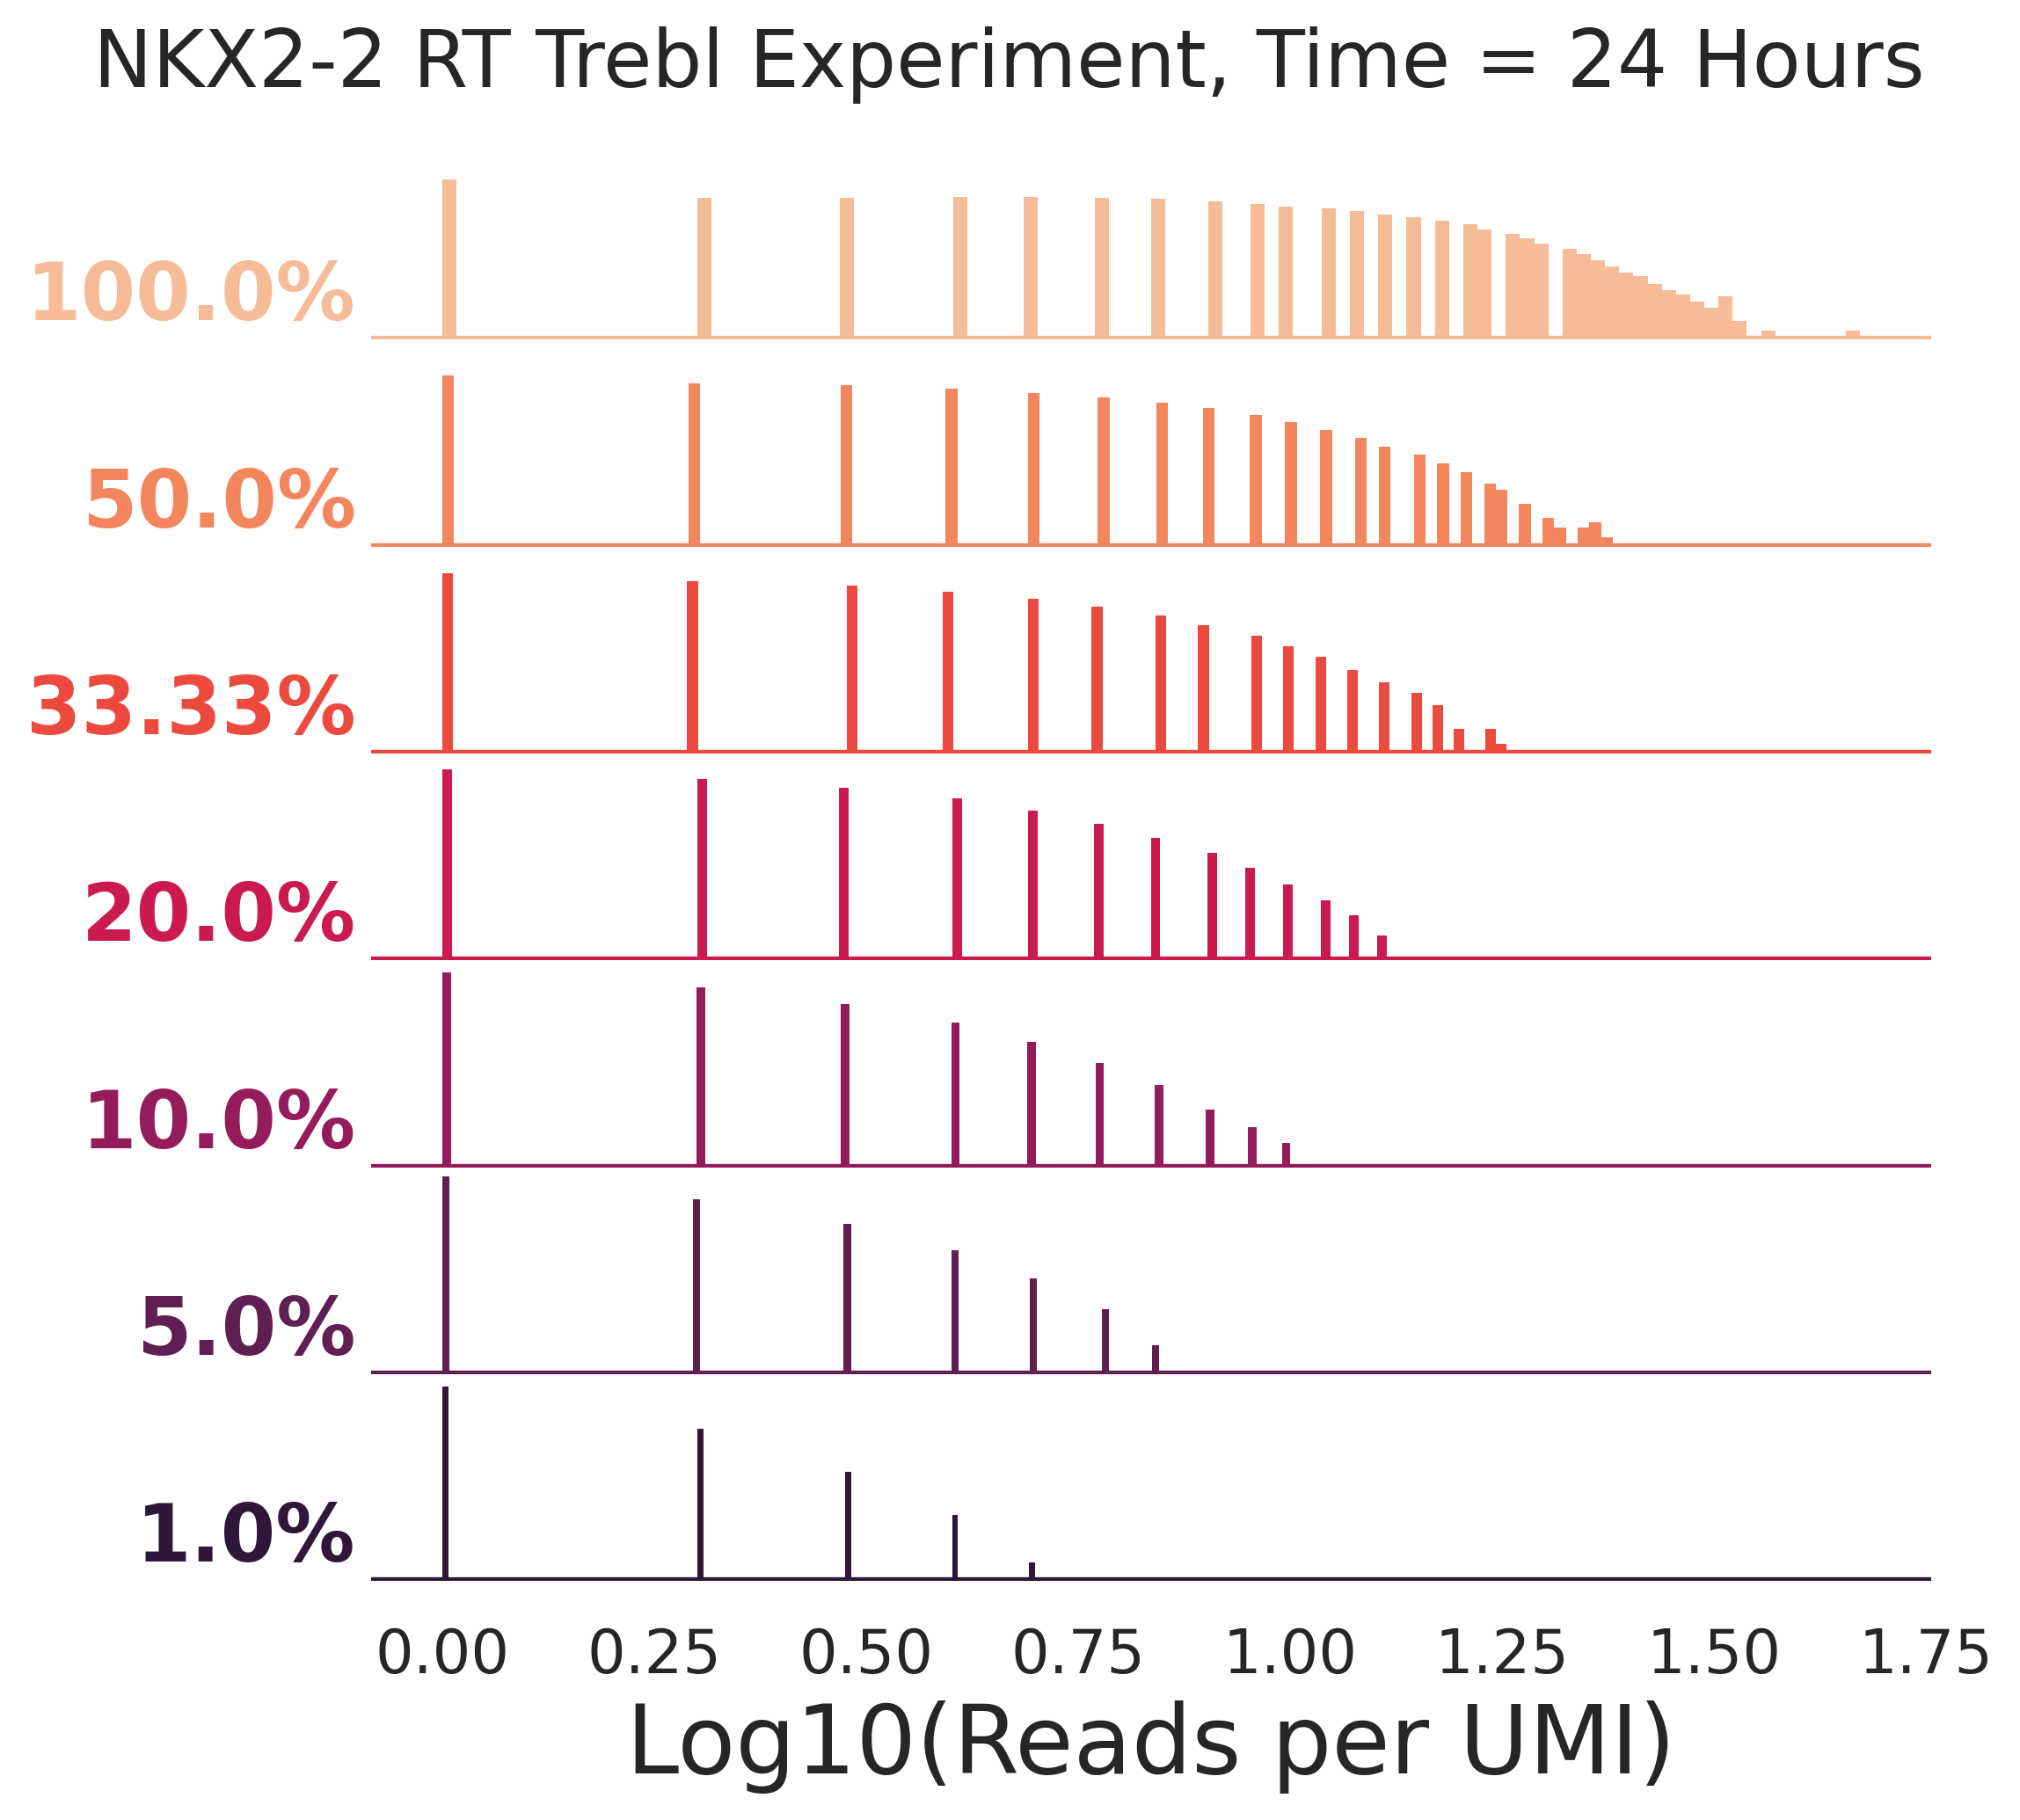

In [45]:
# --------------------------------------
# Preprocess your data
# all_df_filtered must have 'reads' and 'downsample_val'
# --------------------------------------
all_df_filtered = all_df_filtered[all_df_filtered['reads'] > 0].copy()
all_df_filtered['log_reads'] = np.log10(all_df_filtered['reads'])

# Sort by numeric downsample_val ascending (bottom-to-top)
downsample_levels = all_df_filtered[['downsample', 'downsample_val']].drop_duplicates()
sorted_levels = downsample_levels.sort_values('downsample_val', ascending=True)
all_df_filtered['downsample_val'] = pd.Categorical(
    all_df_filtered['downsample_val'],
    categories=sorted_levels['downsample_val'],
    ordered=True
)

# Seaborn styling
sns.set_context("talk")
sns.set_style("white")

# Create FacetGrid
g = sns.FacetGrid(
    all_df_filtered,
    row="downsample_val",
    hue="downsample_val",
    aspect=8,
    height=1,
    palette='rocket_r',
    row_order=sorted_levels['downsample_val']
)

g.figure.set_dpi(300)

colors = []

# Histogram with white border
def log_hist(x, color, **kwargs):
    ax = plt.gca()
    colors.append(color)

    sns.histplot(
        x,
        bins=100,
        stat="count",
        alpha=1,
        element = 'step',
        edgecolor='none',
        color=color,
        **kwargs
    )

    ax.set_yscale("log")
    ax.set_facecolor("none")

    
g.map(log_hist, "log_reads")
  
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(-0.01, .2, str(np.round(float(label), 2)) + "%", fontweight="bold", color=color,
            fontsize = 'large',
            ha="right", va="center", transform=ax.transAxes)


g.map(label, "downsample")

# Force draw so limits are finalized
g.figure.canvas.draw()

# Add colored baselines to each facet
for ax, color in zip(g.axes.flat, colors):
    ymin, ymax = ax.get_ylim()
    ax.axhline(y=ymin, color=color, linewidth=2)
    
# Clean up
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set_xlabels("Log10(Reads per UMI)", fontsize = 'x-large')
g.fig.subplots_adjust(hspace=0)
sns.despine(bottom = True, left=True)


g.fig.suptitle("NKX2-2 RT Trebl Experiment, Time = 24 Hours")
plt.show()

# Example scatters

# GCN4 AD

In [190]:
sns.set_style('ticks')

AD_1_30_20_chunks = pd.read_csv(
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_AD_1_30_20_chunks_part_1/processed_step1_map.csv"
)
AD_1_30_20_chunks

,AD,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full,AD_umi_count_downsampled,RT_umi_count_downsampled,activity_downsampled
0,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,87.0,3474.0,0.025043,642.0,87.0,0.135514
1,ATGGGTACTGTTTCTCCACAAGATTTGTTGATTCAAGAACCATTTA...,AAGATATGTCT,TGCCTATGGTACAA,1090.0,1035.0,1.053140,220.0,1090.0,4.954545
2,TCTGTTGAAGCTTCTCCAGCTACTCCATCTGAAGATTTGGAAGCTT...,TAATTCTTAAA,AAAGCAACCGAAGA,6.0,278.0,0.021583,56.0,6.0,0.107143
3,AAATTGGAAGCTCCAGCTACTACTCATTTGACTTTGGATGCTATCT...,GGGTAGAAGTA,TAGTAGATGGAATT,8.0,50.0,0.160000,8.0,8.0,1.000000
4,ATTGATATGTTCTTGGAAGATTCTGATTCTCCATCTGCTTCTTGTT...,CGATTCGAGAA,AACACAAACCATAG,8.0,280.0,0.028571,50.0,8.0,0.160000
...,...,...,...,...,...,...,...,...,...
14172,GGTTCTGAAGAATGGGGTCCATTGTTTCCAGCTCAAGATGACTTCT...,TACAATTAACT,TTCGATTAGTTTCA,1492.0,1522.0,0.980289,286.0,1492.0,5.216783
14173,ACTGCTGCTCCAAGATCTTCTGCTACTAAACATTCTACTGTTGCTG...,ACTAGTTTGCA,ACCCACGGCATTGT,25.0,914.0,0.027352,168.0,25.0,0.148810
14174,CAATCTTCTGGTTTGAGATCTTCTTTGCAGAATCAAAGAGTTGCTG...,ACCCAGGACTT,TGGCTTTATGCAAT,26.0,811.0,0.032059,145.0,26.0,0.179310
14175,GAATCTACTGTTTCTGTTGCTGCTACTGCTACTGTTACTGCTAAGA...,TAAGCCCTCGC,TACACTGATACTGA,67.0,2.0,33.500000,1.0,67.0,67.000000


In [191]:
AD_1_30_20_chunks["umi_diff"] = AD_1_30_20_chunks["AD_umi_count_full"] - AD_1_30_20_chunks["AD_umi_count_downsampled"]
AD_1_30_20_chunks["umi_diff"].value_counts()

umi_diff
1.0       2132
2.0         53
3.0         39
6.0         30
122.0       25
          ... 
1161.0       1
1617.0       1
2886.0       1
1759.0       1
1096.0       1
Name: count, Length: 2166, dtype: int64

In [193]:
AD_1_30_20_chunks["umi_diff_1"] = AD_1_30_20_chunks["umi_diff"] == 1
AD_1_30_20_chunks

,AD,AD_BC,RPTR_BC,RT_umi_count_full,AD_umi_count_full,activity_full,AD_umi_count_downsampled,RT_umi_count_downsampled,activity_downsampled,umi_diff,umi_diff_1
0,GATGATATTGTTGATGTTGTTGGTGATTCTCCATCTACTTCTCCAA...,CTCTGTTGCAG,TGGATACTAACCTG,87.0,3474.0,0.025043,642.0,87.0,0.135514,2832.0,False
1,ATGGGTACTGTTTCTCCACAAGATTTGTTGATTCAAGAACCATTTA...,AAGATATGTCT,TGCCTATGGTACAA,1090.0,1035.0,1.053140,220.0,1090.0,4.954545,815.0,False
2,TCTGTTGAAGCTTCTCCAGCTACTCCATCTGAAGATTTGGAAGCTT...,TAATTCTTAAA,AAAGCAACCGAAGA,6.0,278.0,0.021583,56.0,6.0,0.107143,222.0,False
3,AAATTGGAAGCTCCAGCTACTACTCATTTGACTTTGGATGCTATCT...,GGGTAGAAGTA,TAGTAGATGGAATT,8.0,50.0,0.160000,8.0,8.0,1.000000,42.0,False
4,ATTGATATGTTCTTGGAAGATTCTGATTCTCCATCTGCTTCTTGTT...,CGATTCGAGAA,AACACAAACCATAG,8.0,280.0,0.028571,50.0,8.0,0.160000,230.0,False
...,...,...,...,...,...,...,...,...,...,...,...
14172,GGTTCTGAAGAATGGGGTCCATTGTTTCCAGCTCAAGATGACTTCT...,TACAATTAACT,TTCGATTAGTTTCA,1492.0,1522.0,0.980289,286.0,1492.0,5.216783,1236.0,False
14173,ACTGCTGCTCCAAGATCTTCTGCTACTAAACATTCTACTGTTGCTG...,ACTAGTTTGCA,ACCCACGGCATTGT,25.0,914.0,0.027352,168.0,25.0,0.148810,746.0,False
14174,CAATCTTCTGGTTTGAGATCTTCTTTGCAGAATCAAAGAGTTGCTG...,ACCCAGGACTT,TGGCTTTATGCAAT,26.0,811.0,0.032059,145.0,26.0,0.179310,666.0,False
14175,GAATCTACTGTTTCTGTTGCTGCTACTGCTACTGTTACTGCTAAGA...,TAAGCCCTCGC,TACACTGATACTGA,67.0,2.0,33.500000,1.0,67.0,67.000000,1.0,True


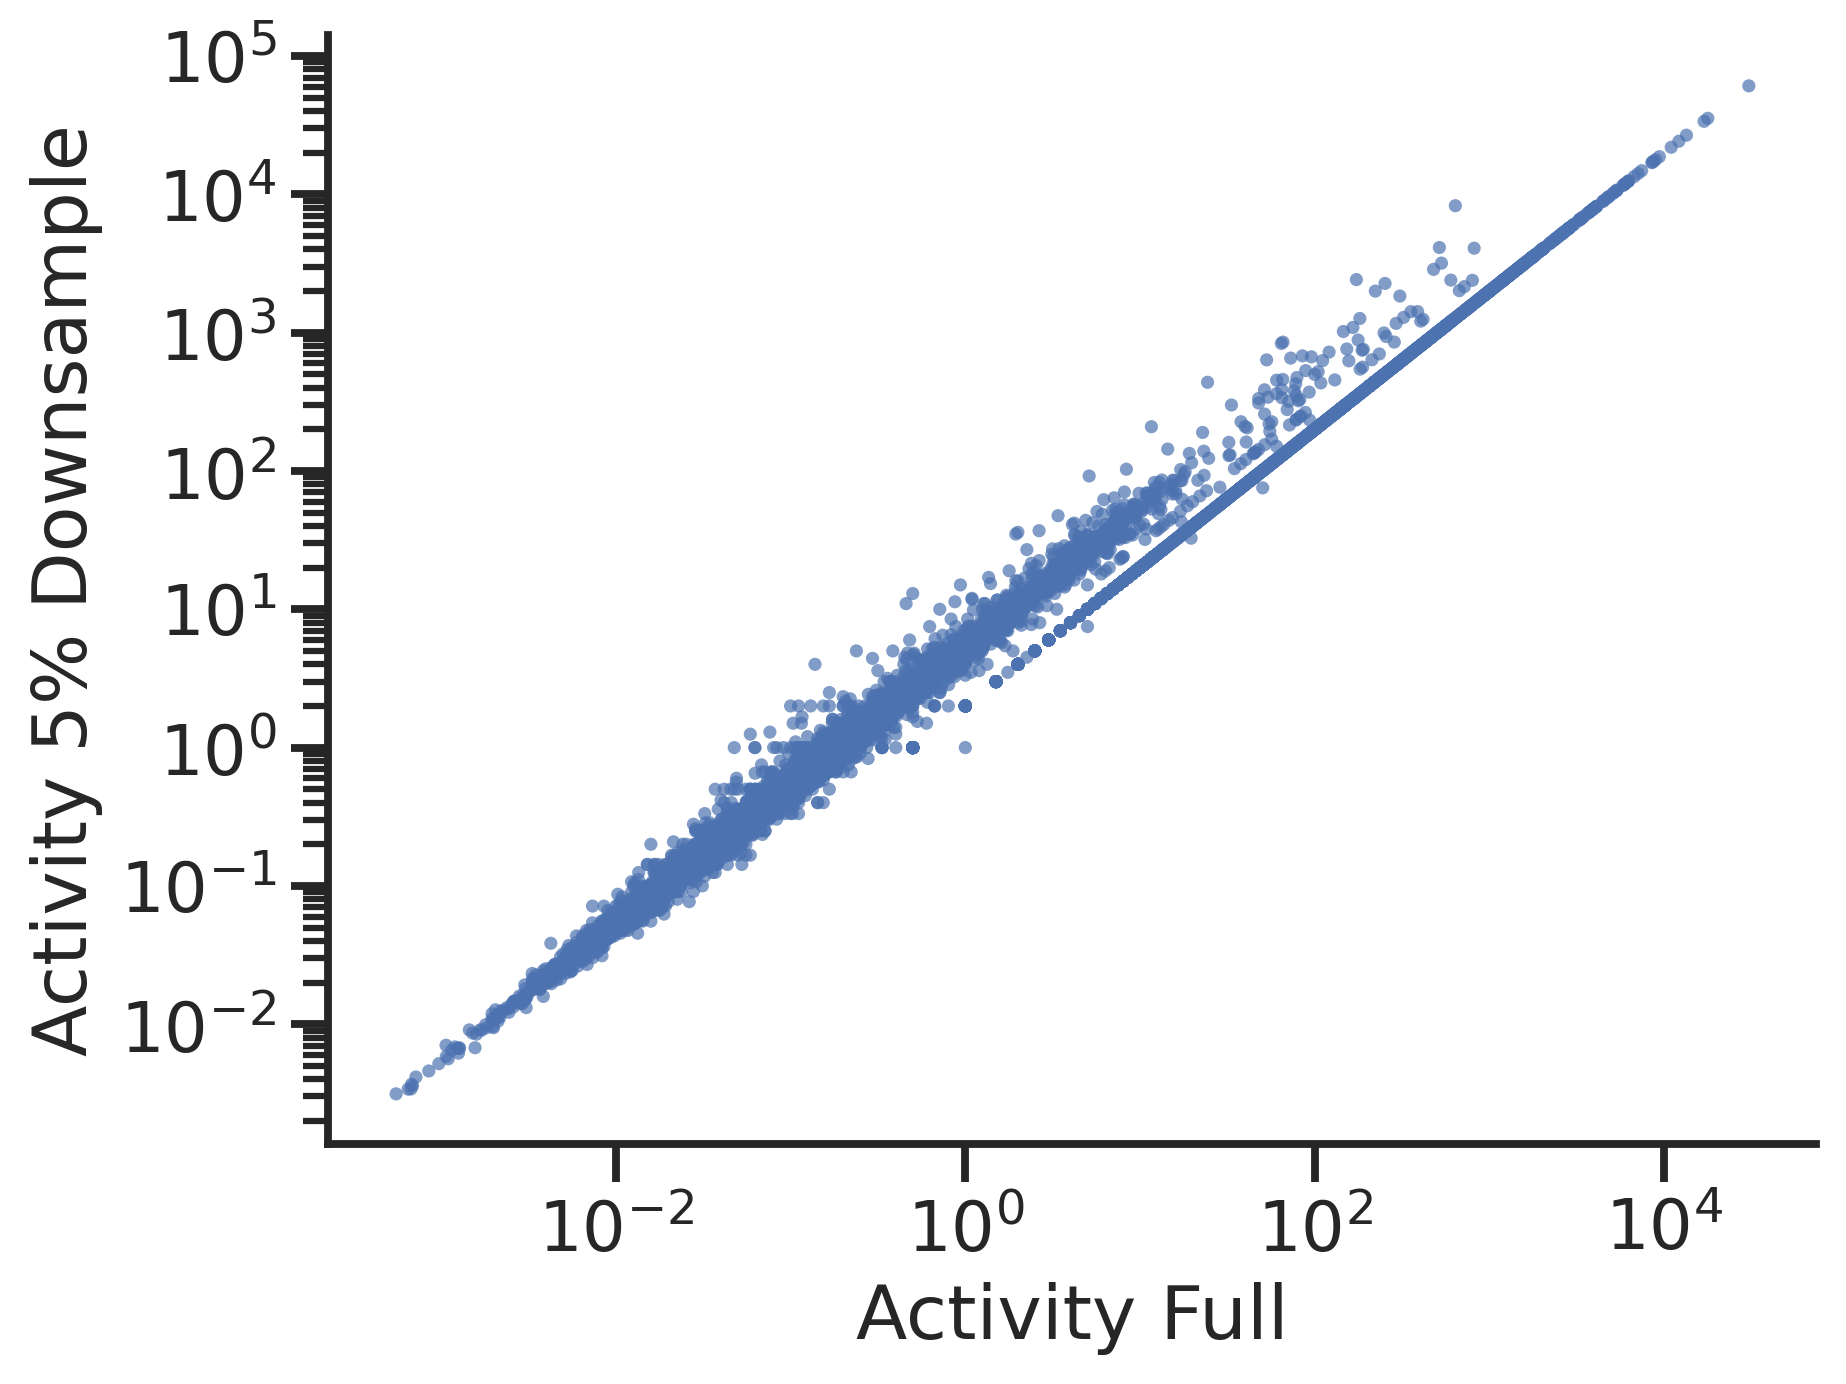

In [198]:
plt.figure(dpi = 300)


ax = sns.scatterplot(
    data=AD_1_30_20_chunks,
    x="activity_full",
    y="activity_downsampled",
    edgecolor="none",
    alpha=0.7,
    s=10
)

ax.set_xscale("log")
ax.set_yscale("log")


plt.xlabel("Activity Full")
plt.ylabel("Activity 5% Downsample")
sns.despine()

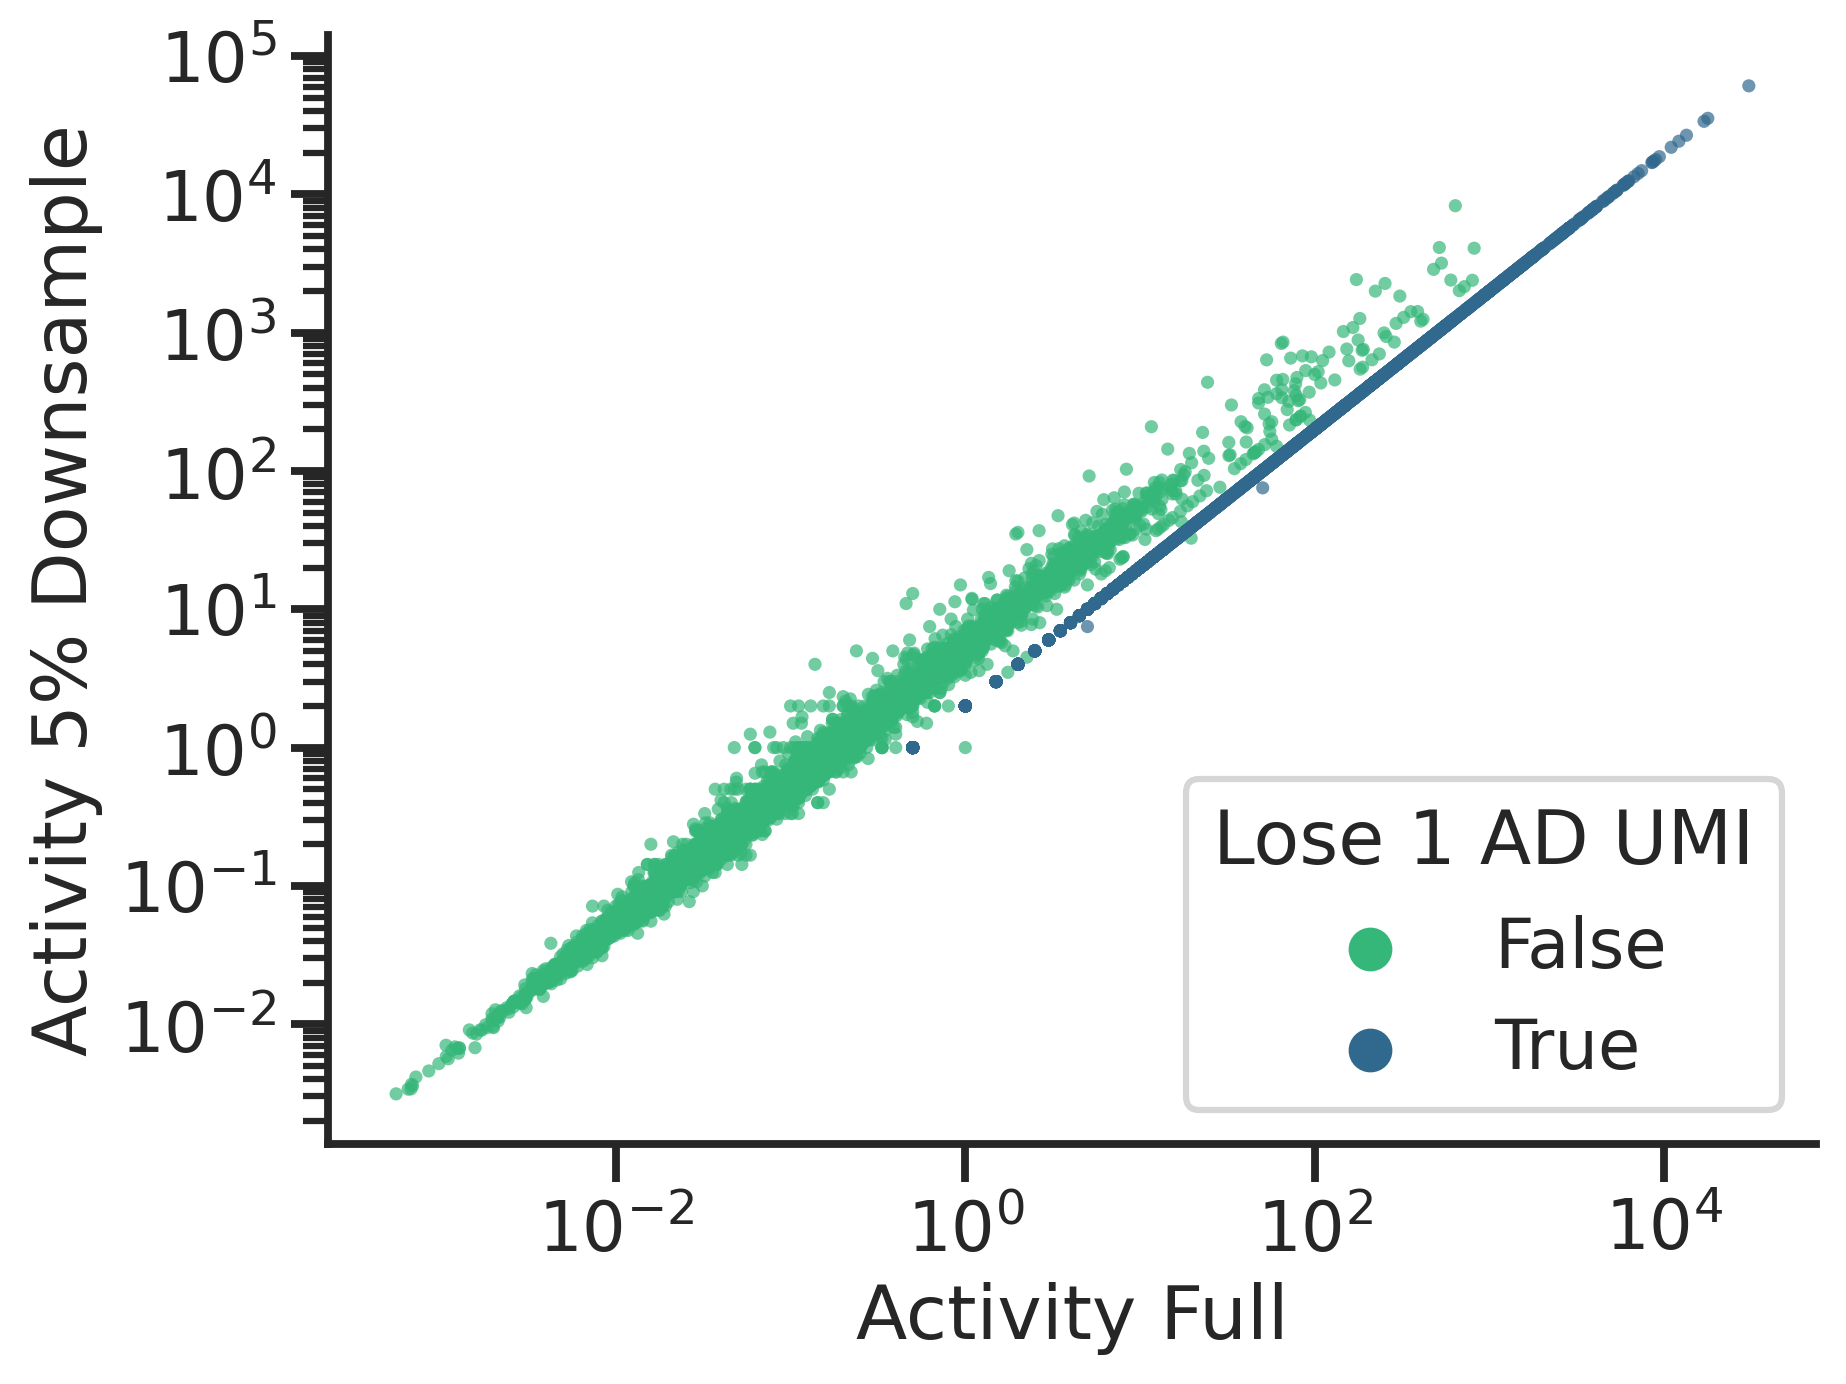

In [197]:
plt.figure(dpi = 300)

ax = sns.scatterplot(
    data=AD_1_30_20_chunks,
    x="activity_full",
    y="activity_downsampled",
    edgecolor="none",
    alpha=0.7,
    s=10,
    hue = "umi_diff_1",
    palette = 'viridis_r'
)

ax.set_xscale("log")
ax.set_yscale("log")

plt.legend(loc = 'lower right', title = "Lose 1 AD UMI")

plt.xlabel("Activity Full")
plt.ylabel("Activity 5% Downsample")
sns.despine()

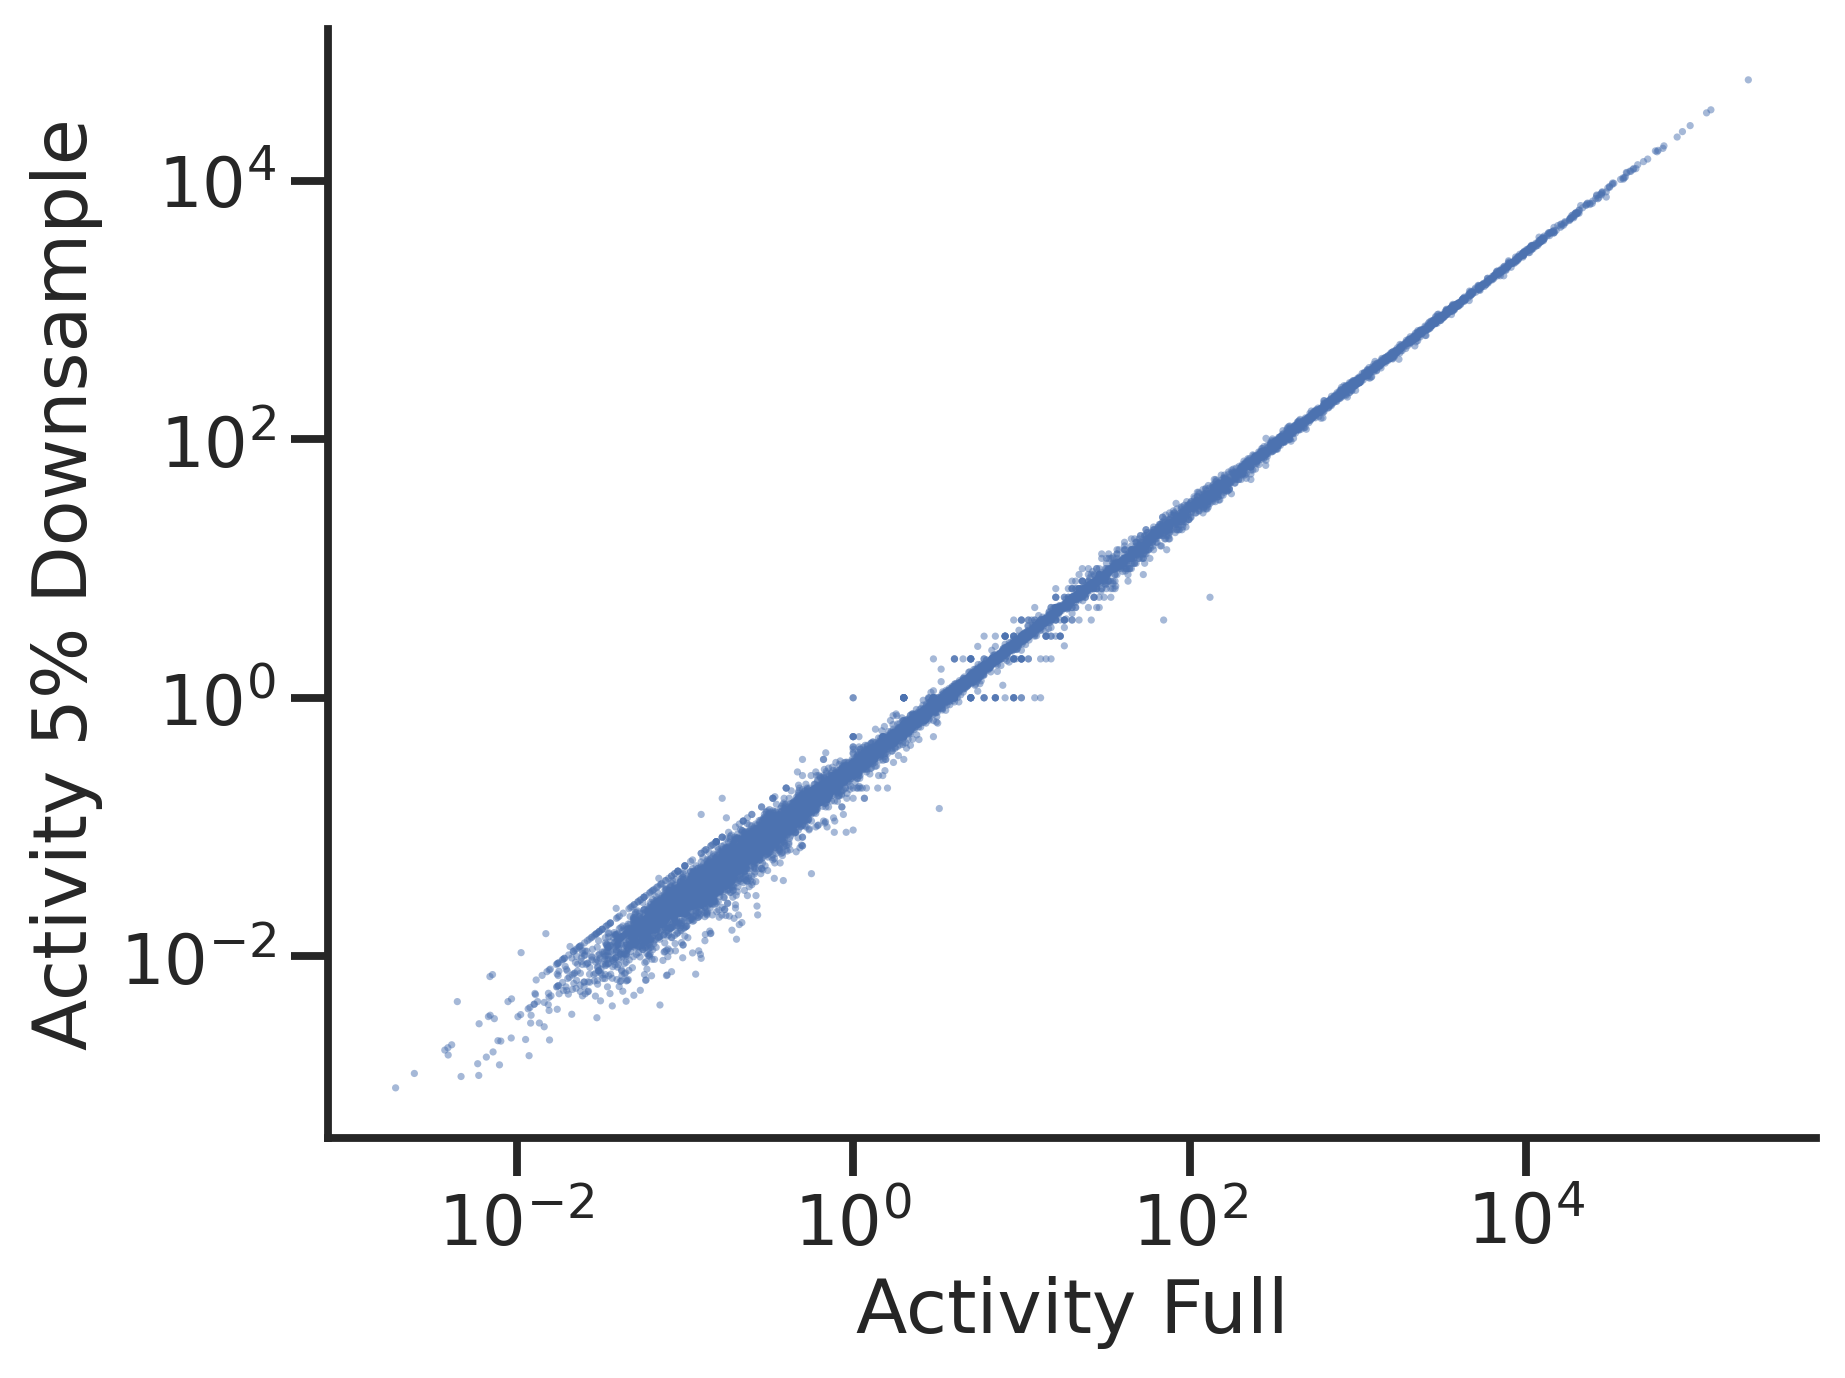

In [200]:
sns.set_style('ticks')

plt.figure(dpi = 300)

AD_1_30_20_chunks = pd.read_csv(
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/downsampling/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_20_chunks_part_1/processed_step1_map.csv"
)

ax = sns.scatterplot(
    data=AD_1_30_20_chunks,
    x="activity_full",
    y="activity_downsampled",
    edgecolor="none",
    alpha=0.5,
    s=3
)

ax.set_xscale("log")
ax.set_yscale("log")

plt.xlabel("Activity Full")
plt.ylabel("Activity 5% Downsample")

sns.despine()